In [1]:
from os import path

import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity

import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)
from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )
from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)
from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)
from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity



def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)

    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )

    # Calculate effective size
    eff_size = num_alters - avg_degree

    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0

    return eff_size, efficiency


def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego


def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego


def graph_features(gs):
    dfs = {}

    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []

        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)

            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)

            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)

            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))

            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)

            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)

        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )

    return dfs


def combine_features(market_features, graph_features):
    combined_data = {}

    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()

        combined_data[key] = combined_df

    return combined_data


def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]

        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            "in_ratio",
            "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_normalize = features_buffer[feature_columns]
        normalized_features = (
            features_to_normalize - features_to_normalize.mean()
        ) / features_to_normalize.std()

        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")

        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)

        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }

        # # Map node IDs to indices
        # id_to_index = {node_id: index for index, node_id in enumerate(features_buffer["telegram_chat_id"])}

        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []


        features_df = features_buffer.set_index("telegram_chat_id")

        # Calculate cosine similarity for each pair of rows
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)

            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity


        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)

        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)




        # Populate the lists




        num_labels = 3

        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)

        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)

        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency

            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)

        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)

        # Create a Data object
        data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)

        prepared_data.append(data)

    return prepared_data



# with open(path.join(PROJECT_ROOT, "data", "signals.pkl"), "rb") as file:
# signals = pickle.load(file)


def get_similar_graph(features_dfs):
    """
    Function to create a set of undirected graphs from a dictionary of feature dataframes.
    Each graph represents the strongest connections based on cosine similarity of features.

    Parameters:
    features_dfs (dict): A dictionary where keys are identifiers and values are Pandas DataFrames
                         with 'telegram_chat_id' as one of the columns.

    Returns:
    dict: A dictionary of networkx.Graph objects keyed by the same keys as the input dictionary.
    """
    new_gs = {}

    for key, features_df in features_dfs.items():
        # Skip processing if 'telegram_chat_id' is not present
        if "telegram_chat_id" not in features_df.columns:
            print(
                f"Skipping key {key}: Column 'telegram_chat_id' not found in DataFrame"
            )
            continue

        print("Processing key:", key)  # Debugging information

        # Set 'telegram_chat_id' as the index
        features_df = features_df.set_index("telegram_chat_id")

        # Calculate cosine similarity for each pair of rows
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)

            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity

        # Sort and keep the top half of the edges based on high weight
        sorted_edges = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
        half_edge_count = len(sorted_edges) // 2
        edges_to_keep = sorted_edges[:half_edge_count]

        # Create a new graph with filtered edges
        filtered_G = nx.Graph()
        for (node1, node2), _ in edges_to_keep:
            filtered_G.add_edge(node1, node2)

        new_gs[key] = filtered_G

    return new_gs


# Example usage
# gsn = get_similar_graph(your_features_dfs_dictionary)


def get_new_data_loader():
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_ngs, train_c, train_label_mapping)
    test_data = prepare_data(ngs, c, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

    return train_loader, test_loader


if __name__ == "__main__":
    a, b = get_new_data_loader()

/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])


Processing key: 1INCH
Processing key: AAVE
Skipping key ACA: Column 'telegram_chat_id' not found in DataFrame
Skipping key ACM: Column 'telegram_chat_id' not found in DataFrame
Processing key: ADA
Processing key: ADX
Skipping key AE: Column 'telegram_chat_id' not found in DataFrame
Processing key: AERGO
Processing key: AGI
Processing key: AGIX
Skipping key AGLD: Column 'telegram_chat_id' not found in DataFrame
Processing key: AION
Skipping key AKRO: Column 'telegram_chat_id' not found in DataFrame
Skipping key ALCX: Column 'telegram_chat_id' not found in DataFrame
Processing key: ALGO
Processing key: ALICE
Skipping key ALPACA: Column 'telegram_chat_id' not found in DataFrame
Processing key: ALPHA
Skipping key ALPINE: Column 'telegram_chat_id' not found in DataFrame
Processing key: AMB
Skipping key ANC: Column 'telegram_chat_id' not found in DataFrame
Skipping key ANKR: Column 'telegram_chat_id' not found in DataFrame
Processing key: ANT
Skipping key ANY: Column 'telegram_chat_id' not f

/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore


train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])


Skipping key 1000LUNC: Column 'telegram_chat_id' not found in DataFrame
Skipping key 1CAT: Column 'telegram_chat_id' not found in DataFrame
Skipping key 1EARTH: Column 'telegram_chat_id' not found in DataFrame
Processing key: 1INCH
Processing key: AAVE
Skipping key ABBC: Column 'telegram_chat_id' not found in DataFrame
Processing key: ACA
Processing key: ACE
Processing key: ACH
Skipping key ACM: Column 'telegram_chat_id' not found in DataFrame
Skipping key ACQ: Column 'telegram_chat_id' not found in DataFrame
Skipping key ACS: Column 'telegram_chat_id' not found in DataFrame
Skipping key ACT: Column 'telegram_chat_id' not found in DataFrame
Processing key: ADA
Skipping key ADS: Column 'telegram_chat_id' not found in DataFrame
Skipping key ADX: Column 'telegram_chat_id' not found in DataFrame
Skipping key AERGO: Column 'telegram_chat_id' not found in DataFrame
Processing key: AGIX
Processing key: AGLD
Processing key: AI
Skipping key AIPAD: Column 'telegram_chat_id' not found in DataFram

ValueError: Input contains NaN.

In [2]:
from os import path

import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity

import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)
from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )
from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)
from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)
from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity



def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)

    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )

    # Calculate effective size
    eff_size = num_alters - avg_degree

    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0

    return eff_size, efficiency


def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego


def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego


def graph_features(gs):
    dfs = {}

    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []

        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)

            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)

            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)

            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))

            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)

            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)

        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )

    return dfs


def combine_features(market_features, graph_features):
    combined_data = {}

    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()

        combined_data[key] = combined_df

    return combined_data


def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]

        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            "in_ratio",
            "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_normalize = features_buffer[feature_columns]
        normalized_features = (
            features_to_normalize - features_to_normalize.mean()
        ) / features_to_normalize.std()

        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")

        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)

        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }

        # # Map node IDs to indices
        # id_to_index = {node_id: index for index, node_id in enumerate(features_buffer["telegram_chat_id"])}

        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []


        features_df = features_buffer.set_index("telegram_chat_id")

        # Calculate cosine similarity for each pair of rows
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)

            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity


        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)

        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)




        # Populate the lists




        num_labels = 3

        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)

        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)

        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency

            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)

        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)

        # Create a Data object
        data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)

        prepared_data.append(data)

    return prepared_data



# with open(path.join(PROJECT_ROOT, "data", "signals.pkl"), "rb") as file:
# signals = pickle.load(file)


# def get_similar_graph(features_dfs):
#     """
#     Function to create a set of undirected graphs from a dictionary of feature dataframes.
#     Each graph represents the strongest connections based on cosine similarity of features.

#     Parameters:
#     features_dfs (dict): A dictionary where keys are identifiers and values are Pandas DataFrames
#                          with 'telegram_chat_id' as one of the columns.

#     Returns:
#     dict: A dictionary of networkx.Graph objects keyed by the same keys as the input dictionary.
#     """
#     new_gs = {}

#     for key, features_df in features_dfs.items():
#         # Skip processing if 'telegram_chat_id' is not present
#         if "telegram_chat_id" not in features_df.columns:
#             print(
#                 f"Skipping key {key}: Column 'telegram_chat_id' not found in DataFrame"
#             )
#             continue

#         print("Processing key:", key)  # Debugging information

#         # Set 'telegram_chat_id' as the index
#         features_df = features_df.set_index("telegram_chat_id")

#         # Calculate cosine similarity for each pair of rows
#         similarities = {}
#         for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
#             fi = features_df.loc[chat_id_1].values.reshape(1, -1)
#             fj = features_df.loc[chat_id_2].values.reshape(1, -1)

#             similarity = cosine_similarity(fi, fj)[0][0]
#             similarities[(chat_id_1, chat_id_2)] = similarity

#         # Sort and keep the top half of the edges based on high weight
#         sorted_edges = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
#         half_edge_count = len(sorted_edges) // 2
#         edges_to_keep = sorted_edges[:half_edge_count]

#         # Create a new graph with filtered edges
#         filtered_G = nx.Graph()
#         for (node1, node2), _ in edges_to_keep:
#             filtered_G.add_edge(node1, node2)

#         new_gs[key] = filtered_G

#     return new_gs


# Example usage
# gsn = get_similar_graph(your_features_dfs_dictionary)


def get_new_data_loader():
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_c, train_label_mapping)
    test_data = prepare_data(gs, c, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

    return train_loader, test_loader


if __name__ == "__main__":
    a, b = get_new_data_loader()

/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

NaN values detected in key: BURGER, Columns: ['number_of_signals']
NaN values detected in key: COS, Columns: ['average_increase_percentage']
NaN values detected in key: CVP, Columns: ['number_of_signals']
NaN values detected in key: CVX, Columns: ['number_of_signals']
NaN values detected in key: FIDA, Columns: ['number_of_signals']
NaN values detected in key: GNO, Columns: ['number_of_signals']
NaN values detected in key: JUV, Columns: ['number_of_signals']
NaN values detected in key: KP3R, Columns: ['number_of_signals']
NaN values detected in key: LAZIO, Columns: ['number_of_signals']


ValueError: Input contains NaN.

In [3]:
from os import path

import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity

import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)
from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping

# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )
from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)
from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)
from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity


def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)

    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )

    # Calculate effective size
    eff_size = num_alters - avg_degree

    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0

    return eff_size, efficiency


def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego


def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego


def graph_features(gs):
    dfs = {}

    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []

        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)

            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)

            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)

            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))

            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)

            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)

        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )

    return dfs


def combine_features(market_features, graph_features):
    combined_data = {}

    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()

        combined_data[key] = combined_df

    return combined_data

# Extract features for nodes present in the graph
features_buffer = features[key]

# Ensure only rows corresponding to nodes present in the graph are selected
features_buffer = features_buffer[
    features_buffer["telegram_chat_id"].isin(graph.nodes)
]

# Drop rows where 'average_increase_percentage' or 'number_of_signals' are NaN
features_buffer = features_buffer.dropna(subset=["average_increase_percentage", "number_of_signals"])



def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]

        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_buffer = features_buffer.dropna(subset=["average_increase_percentage", "number_of_signals"])

        features_to_normalize = features_buffer[feature_columns]
        normalized_features = (
            features_to_normalize - features_to_normalize.mean()
        ) / features_to_normalize.std()

        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")

        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)

        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }

        # # Map node IDs to indices
        # id_to_index = {node_id: index for index, node_id in enumerate(features_buffer["telegram_chat_id"])}

        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []

        features_df = features_buffer.set_index("telegram_chat_id")

        # Calculate cosine similarity for each pair of rows
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)

            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity

        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if (
                source is not None and target is not None
            ):  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)

        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)

        # Populate the lists

        num_labels = 3

        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)

        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)

        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency

            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)

        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)

        # Create a Data object
        data = Data(
            x=node_attributes,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=labels_tensor,
        )

        prepared_data.append(data)

    return prepared_data


# with open(path.join(PROJECT_ROOT, "data", "signals.pkl"), "rb") as file:
# signals = pickle.load(file)


# def get_similar_graph(features_dfs):
#     """
#     Function to create a set of undirected graphs from a dictionary of feature dataframes.
#     Each graph represents the strongest connections based on cosine similarity of features.

#     Parameters:
#     features_dfs (dict): A dictionary where keys are identifiers and values are Pandas DataFrames
#                          with 'telegram_chat_id' as one of the columns.

#     Returns:
#     dict: A dictionary of networkx.Graph objects keyed by the same keys as the input dictionary.
#     """
#     new_gs = {}

#     for key, features_df in features_dfs.items():
#         # Skip processing if 'telegram_chat_id' is not present
#         if "telegram_chat_id" not in features_df.columns:
#             print(
#                 f"Skipping key {key}: Column 'telegram_chat_id' not found in DataFrame"
#             )
#             continue

#         print("Processing key:", key)  # Debugging information

#         # Set 'telegram_chat_id' as the index
#         features_df = features_df.set_index("telegram_chat_id")

#         # Calculate cosine similarity for each pair of rows
#         similarities = {}
#         for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
#             fi = features_df.loc[chat_id_1].values.reshape(1, -1)
#             fj = features_df.loc[chat_id_2].values.reshape(1, -1)

#             similarity = cosine_similarity(fi, fj)[0][0]
#             similarities[(chat_id_1, chat_id_2)] = similarity

#         # Sort and keep the top half of the edges based on high weight
#         sorted_edges = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
#         half_edge_count = len(sorted_edges) // 2
#         edges_to_keep = sorted_edges[:half_edge_count]

#         # Create a new graph with filtered edges
#         filtered_G = nx.Graph()
#         for (node1, node2), _ in edges_to_keep:
#             filtered_G.add_edge(node1, node2)

#         new_gs[key] = filtered_G

#     return new_gs


# Example usage
# gsn = get_similar_graph(your_features_dfs_dictionary)


def get_new_data_loader():
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_c, train_label_mapping)
    test_data = prepare_data(gs, c, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

    return train_loader, test_loader


if __name__ == "__main__":
    a, b = get_new_data_loader()

NameError: name 'features' is not defined

In [4]:
from os import path

import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity

import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)
from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping

# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )
from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)
from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)
from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity


def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)

    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )

    # Calculate effective size
    eff_size = num_alters - avg_degree

    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0

    return eff_size, efficiency


def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego


def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego


def graph_features(gs):
    dfs = {}

    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []

        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)

            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)

            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)

            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))

            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)

            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)

        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )

    return dfs


def combine_features(market_features, graph_features):
    combined_data = {}

    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()

        combined_data[key] = combined_df

    return combined_data




def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]

        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_buffer = features_buffer.dropna(subset=["average_increase_percentage", "number_of_signals"])

        features_to_normalize = features_buffer[feature_columns]
        normalized_features = (
            features_to_normalize - features_to_normalize.mean()
        ) / features_to_normalize.std()

        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")

        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)

        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }

        # # Map node IDs to indices
        # id_to_index = {node_id: index for index, node_id in enumerate(features_buffer["telegram_chat_id"])}

        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []

        features_df = features_buffer.set_index("telegram_chat_id")

        # Calculate cosine similarity for each pair of rows
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)

            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity

        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if (
                source is not None and target is not None
            ):  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)

        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)

        # Populate the lists

        num_labels = 3

        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)

        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)

        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency

            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)

        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)

        # Create a Data object
        data = Data(
            x=node_attributes,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=labels_tensor,
        )

        prepared_data.append(data)

    return prepared_data


# with open(path.join(PROJECT_ROOT, "data", "signals.pkl"), "rb") as file:
# signals = pickle.load(file)


# def get_similar_graph(features_dfs):
#     """
#     Function to create a set of undirected graphs from a dictionary of feature dataframes.
#     Each graph represents the strongest connections based on cosine similarity of features.

#     Parameters:
#     features_dfs (dict): A dictionary where keys are identifiers and values are Pandas DataFrames
#                          with 'telegram_chat_id' as one of the columns.

#     Returns:
#     dict: A dictionary of networkx.Graph objects keyed by the same keys as the input dictionary.
#     """
#     new_gs = {}

#     for key, features_df in features_dfs.items():
#         # Skip processing if 'telegram_chat_id' is not present
#         if "telegram_chat_id" not in features_df.columns:
#             print(
#                 f"Skipping key {key}: Column 'telegram_chat_id' not found in DataFrame"
#             )
#             continue

#         print("Processing key:", key)  # Debugging information

#         # Set 'telegram_chat_id' as the index
#         features_df = features_df.set_index("telegram_chat_id")

#         # Calculate cosine similarity for each pair of rows
#         similarities = {}
#         for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
#             fi = features_df.loc[chat_id_1].values.reshape(1, -1)
#             fj = features_df.loc[chat_id_2].values.reshape(1, -1)

#             similarity = cosine_similarity(fi, fj)[0][0]
#             similarities[(chat_id_1, chat_id_2)] = similarity

#         # Sort and keep the top half of the edges based on high weight
#         sorted_edges = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
#         half_edge_count = len(sorted_edges) // 2
#         edges_to_keep = sorted_edges[:half_edge_count]

#         # Create a new graph with filtered edges
#         filtered_G = nx.Graph()
#         for (node1, node2), _ in edges_to_keep:
#             filtered_G.add_edge(node1, node2)

#         new_gs[key] = filtered_G

#     return new_gs


# Example usage
# gsn = get_similar_graph(your_features_dfs_dictionary)


def get_new_data_loader():
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_c, train_label_mapping)
    test_data = prepare_data(gs, c, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

    return train_loader, test_loader


if __name__ == "__main__":
    a, b = get_new_data_loader()

/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

NaN values detected in key: BURGER, Columns: ['number_of_signals']
NaN values detected in key: COS, Columns: ['average_increase_percentage']
NaN values detected in key: CVP, Columns: ['number_of_signals']
NaN values detected in key: CVX, Columns: ['number_of_signals']
NaN values detected in key: FIDA, Columns: ['number_of_signals']
NaN values detected in key: GNO, Columns: ['number_of_signals']
NaN values detected in key: JUV, Columns: ['number_of_signals']
NaN values detected in key: KP3R, Columns: ['number_of_signals']
NaN values detected in key: LAZIO, Columns: ['number_of_signals']


ValueError: Input contains NaN.

In [5]:
from os import path

import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity

import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)
from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping

# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )
from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)
from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)
from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity


def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)

    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )

    # Calculate effective size
    eff_size = num_alters - avg_degree

    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0

    return eff_size, efficiency


def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego


def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego


def graph_features(gs):
    dfs = {}

    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []

        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)

            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)

            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)

            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))

            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)

            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)

        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )

    return dfs


def combine_features(market_features, graph_features):
    combined_data = {}

    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()

        combined_data[key] = combined_df

    return combined_data


def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]

        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_buffer = features_buffer.dropna(
            subset=["average_increase_percentage", "number_of_signals"]
        )

        features_to_normalize = features_buffer[feature_columns]
        normalized_features = (
            features_to_normalize - features_to_normalize.mean()
        ) / features_to_normalize.std()

        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")

        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)

        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }

        # # Map node IDs to indices
        # id_to_index = {node_id: index for index, node_id in enumerate(features_buffer["telegram_chat_id"])}

        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []

        features_df = features_buffer.set_index("telegram_chat_id")

        # Calculate cosine similarity for each pair of rows
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)

            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity

        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if (
                source is not None and target is not None
            ):  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)

        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)

        # Populate the lists

        num_labels = 3

        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)

        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)

        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency

            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)

        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)

        # Create a Data object
        data = Data(
            x=node_attributes,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=labels_tensor,
        )

        prepared_data.append(data)

    return prepared_data


# with open(path.join(PROJECT_ROOT, "data", "signals.pkl"), "rb") as file:
# signals = pickle.load(file)


# def get_similar_graph(features_dfs):
#     """
#     Function to create a set of undirected graphs from a dictionary of feature dataframes.
#     Each graph represents the strongest connections based on cosine similarity of features.

#     Parameters:
#     features_dfs (dict): A dictionary where keys are identifiers and values are Pandas DataFrames
#                          with 'telegram_chat_id' as one of the columns.

#     Returns:
#     dict: A dictionary of networkx.Graph objects keyed by the same keys as the input dictionary.
#     """
#     new_gs = {}

#     for key, features_df in features_dfs.items():
#         # Skip processing if 'telegram_chat_id' is not present
#         if "telegram_chat_id" not in features_df.columns:
#             print(
#                 f"Skipping key {key}: Column 'telegram_chat_id' not found in DataFrame"
#             )
#             continue

#         print("Processing key:", key)  # Debugging information

#         # Set 'telegram_chat_id' as the index
#         features_df = features_df.set_index("telegram_chat_id")

#         # Calculate cosine similarity for each pair of rows
#         similarities = {}
#         for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
#             fi = features_df.loc[chat_id_1].values.reshape(1, -1)
#             fj = features_df.loc[chat_id_2].values.reshape(1, -1)

#             similarity = cosine_similarity(fi, fj)[0][0]
#             similarities[(chat_id_1, chat_id_2)] = similarity

#         # Sort and keep the top half of the edges based on high weight
#         sorted_edges = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
#         half_edge_count = len(sorted_edges) // 2
#         edges_to_keep = sorted_edges[:half_edge_count]

#         # Create a new graph with filtered edges
#         filtered_G = nx.Graph()
#         for (node1, node2), _ in edges_to_keep:
#             filtered_G.add_edge(node1, node2)

#         new_gs[key] = filtered_G

#     return new_gs


# Example usage
# gsn = get_similar_graph(your_features_dfs_dictionary)


def get_new_data_loader():
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

    return train_loader, test_loader


if __name__ == "__main__":
    a, b = get_new_data_loader()

/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

NaN values detected in key: BURGER, Columns: ['number_of_signals']
NaN values detected in key: COS, Columns: ['average_increase_percentage']
NaN values detected in key: CVP, Columns: ['number_of_signals']
NaN values detected in key: CVX, Columns: ['number_of_signals']
NaN values detected in key: FIDA, Columns: ['number_of_signals']
NaN values detected in key: GNO, Columns: ['number_of_signals']
NaN values detected in key: JUV, Columns: ['number_of_signals']
NaN values detected in key: KP3R, Columns: ['number_of_signals']
NaN values detected in key: LAZIO, Columns: ['number_of_signals']


ValueError: Input contains NaN.

In [6]:
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

NaN values detected in key: BURGER, Columns: ['number_of_signals']
NaN values detected in key: COS, Columns: ['average_increase_percentage']
NaN values detected in key: CVP, Columns: ['number_of_signals']
NaN values detected in key: CVX, Columns: ['number_of_signals']
NaN values detected in key: FIDA, Columns: ['number_of_signals']
NaN values detected in key: GNO, Columns: ['number_of_signals']
NaN values detected in key: JUV, Columns: ['number_of_signals']
NaN values detected in key: KP3R, Columns: ['number_of_signals']
NaN values detected in key: LAZIO, Columns: ['number_of_signals']


ValueError: Input contains NaN.

In [7]:
market_features

{'1000LUNC':    telegram_chat_id  average_increase_percentage  average_speed  \
 0             316.0                     0.046472       0.000012   
 1            1505.0                     0.056668       0.000014   
 
    number_of_signals  latest_chat_crowd_score  sum_targets_achieved  \
 0                  1                  0.05929                     4   
 1                  1                  0.15388                     5   
 
    sum_total_targets    rating  
 0                  6  0.666667  
 1                  6  0.833333  ,
 '1CAT':    telegram_chat_id  average_increase_percentage  average_speed  \
 2            1701.0                      0.00866       0.001259   
 
    number_of_signals  latest_chat_crowd_score  sum_targets_achieved  \
 2                  3                 0.113148                     3   
 
    sum_total_targets  rating  
 2                  3     1.0  ,
 '1EARTH':    telegram_chat_id  average_increase_percentage  average_speed  \
 3            1701.0      

In [10]:
market_features

{'1000LUNC':    telegram_chat_id  average_increase_percentage  average_speed  \
 0             316.0                     0.046472       0.000012   
 1            1505.0                     0.056668       0.000014   
 
    number_of_signals  latest_chat_crowd_score  sum_targets_achieved  \
 0                  1                  0.05929                     4   
 1                  1                  0.15388                     5   
 
    sum_total_targets    rating  
 0                  6  0.666667  
 1                  6  0.833333  ,
 '1CAT':    telegram_chat_id  average_increase_percentage  average_speed  \
 2            1701.0                      0.00866       0.001259   
 
    number_of_signals  latest_chat_crowd_score  sum_targets_achieved  \
 2                  3                 0.113148                     3   
 
    sum_total_targets  rating  
 2                  3     1.0  ,
 '1EARTH':    telegram_chat_id  average_increase_percentage  average_speed  \
 3            1701.0      

In [11]:
features_df = market_features

In [12]:
        # Calculate cosine similarity for each pair of rows
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)

            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity


AttributeError: 'dict' object has no attribute 'index'

In [13]:
from os import path

import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity

import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)
from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping

# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )
from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)
from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)
from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity


def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)

    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )

    # Calculate effective size
    eff_size = num_alters - avg_degree

    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0

    return eff_size, efficiency


def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego


def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego


def graph_features(gs):
    dfs = {}

    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []

        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)

            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)

            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)

            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))

            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)

            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)

        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )

    return dfs


def combine_features(market_features, graph_features):
    combined_data = {}

    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()

        combined_data[key] = combined_df

    return combined_data


def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        print(key)
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]

        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_buffer = features_buffer.dropna(
            subset=["average_increase_percentage", "number_of_signals"]
        )

        features_to_normalize = features_buffer[feature_columns]
        normalized_features = (
            features_to_normalize - features_to_normalize.mean()
        ) / features_to_normalize.std()

        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")

        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)

        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }

        # # Map node IDs to indices
        # id_to_index = {node_id: index for index, node_id in enumerate(features_buffer["telegram_chat_id"])}

        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []

        features_df = features_buffer.set_index("telegram_chat_id")

        # Calculate cosine similarity for each pair of rows
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)

            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity

        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if (
                source is not None and target is not None
            ):  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)

        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)

        # Populate the lists

        num_labels = 3

        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)

        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)

        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency

            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)

        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)

        # Create a Data object
        data = Data(
            x=node_attributes,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=labels_tensor,
        )

        prepared_data.append(data)

    return prepared_data


# with open(path.join(PROJECT_ROOT, "data", "signals.pkl"), "rb") as file:
# signals = pickle.load(file)


# def get_similar_graph(features_dfs):
#     """
#     Function to create a set of undirected graphs from a dictionary of feature dataframes.
#     Each graph represents the strongest connections based on cosine similarity of features.

#     Parameters:
#     features_dfs (dict): A dictionary where keys are identifiers and values are Pandas DataFrames
#                          with 'telegram_chat_id' as one of the columns.

#     Returns:
#     dict: A dictionary of networkx.Graph objects keyed by the same keys as the input dictionary.
#     """
#     new_gs = {}

#     for key, features_df in features_dfs.items():
#         # Skip processing if 'telegram_chat_id' is not present
#         if "telegram_chat_id" not in features_df.columns:
#             print(
#                 f"Skipping key {key}: Column 'telegram_chat_id' not found in DataFrame"
#             )
#             continue

#         print("Processing key:", key)  # Debugging information

#         # Set 'telegram_chat_id' as the index
#         features_df = features_df.set_index("telegram_chat_id")

#         # Calculate cosine similarity for each pair of rows
#         similarities = {}
#         for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
#             fi = features_df.loc[chat_id_1].values.reshape(1, -1)
#             fj = features_df.loc[chat_id_2].values.reshape(1, -1)

#             similarity = cosine_similarity(fi, fj)[0][0]
#             similarities[(chat_id_1, chat_id_2)] = similarity

#         # Sort and keep the top half of the edges based on high weight
#         sorted_edges = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
#         half_edge_count = len(sorted_edges) // 2
#         edges_to_keep = sorted_edges[:half_edge_count]

#         # Create a new graph with filtered edges
#         filtered_G = nx.Graph()
#         for (node1, node2), _ in edges_to_keep:
#             filtered_G.add_edge(node1, node2)

#         new_gs[key] = filtered_G

#     return new_gs


# Example usage
# gsn = get_similar_graph(your_features_dfs_dictionary)


def get_new_data_loader():
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

    return train_loader, test_loader


if __name__ == "__main__":
    a, b = get_new_data_loader()

/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

1INCH
AAVE
ADA
ADX
AERGO
AGI
AGIX
AION
ALGO
ALICE
ALPHA
AMB
ANT
APE
APPC
ARDR
ARK
ARN
ARPA
AST
ATOM
AUDIO
AVAX
AXS
BAKE
BAL
BAND
BAT
BCD
BCH
BCPT
BEL
BLZ
BNB
BQX
BRD
BTC
BZRX
CDT
CELO
CELR
CHR
CHZ
CMT
COTI
CRV
CTSI
CTXC
CVC
DASH
DATA
DIA
DLT
DNT
DOCK
DODO
DOGE
DOT
DREP
DUSK
DYDX
EGLD
ELF
ENG
ENJ
EOS
EPS
ETH
EVX
FET
FIL
FIO
FIS
FTM
GALA
GLM
GRS
GRT
GTO
GXS
HBAR
HIVE
HNT
ICP
IDEX
INJ
INS
IOST
IRIS
KAVA
KMD
KNC
LEND
LINK
LOOM
LRC
LTC
LTO
LUNA
MANA
MATIC
MDA
MDT
MITH
MKR
MTH
MTL
NAV
NEAR
NEBL
NKN
NULS
OAX
OGN
OM
OMG
ONG
OST
OXT
PERL
PHB
PIVX
PNT
POA
POLY
POND
POWR
PPT
QLC
QSP
QTUM
RCN
RDN
REN
REQ
RLC
RSR
RUNE
RVN
SAND
SKL
SKY
SNX
SOL
SRM
STEEM
STORJ
STPT
SUSHI
SXP
SYS
TCT
TFUEL
THETA
TLM
TOMO
TRB
TRU
TRX
TVK
UNI
UTK
VET
VIA
VIB
VIBE
VIDT
VITE
WABI
WAN
WAVES
WRX
WTC
XLM
XRP
XTZ
YFI
YFII
ZEC
ZEN
ZIL
1INCH
AAVE
ACA
ACE
ACH
ADA
AGIX
AGLD
AI
AKRO
ALCX
ALGO
ALICE
ALPACA
ALPHA
ALPINE
AMB
AMP
ANKR
ANT
APE
API3
APT
AR
ARB
ARK
ARPA
AST
ATOM
AUCTION
AUDIO
AVAX
AXS
BADGER
BAKE
BAL
BAND
BAR
BAT
BCH
BEL

ValueError: Input contains NaN.

In [14]:
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

In [15]:
market_features["LSK"]

,telegram_chat_id,average_increase_percentage,average_speed,number_of_signals,latest_chat_crowd_score,sum_targets_achieved,sum_total_targets,rating
2755,5.0,0.128650,0.000127,1,0.215241,2,3,0.666667
2756,19.0,0.066610,0.000206,3,0.156313,3,12,0.250000
2757,201.0,0.258656,0.000093,1,0.284722,8,8,1.000000
2758,1251.0,0.085140,0.000266,2,NaN,2,8,0.250000
2759,1475.0,0.088633,0.000277,2,NaN,2,8,0.250000
2760,1544.0,0.088199,0.000276,2,NaN,2,8,0.250000
2761,1545.0,0.091847,0.000286,2,NaN,2,8,0.250000
2762,1701.0,0.013084,0.001559,4,0.192740,4,4,1.000000
2763,1735.0,0.082510,0.000258,2,NaN,2,8,0.250000
2764,1751.0,0.087734,0.000274,2,NaN,2,8,0.250000


In [16]:
from os import path

import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity

import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)
from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping

# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )
from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)
from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)
from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity


def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)

    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )

    # Calculate effective size
    eff_size = num_alters - avg_degree

    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0

    return eff_size, efficiency


def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego


def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego


def graph_features(gs):
    dfs = {}

    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []

        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)

            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)

            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)

            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))

            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)

            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)

        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )

    return dfs


def combine_features(market_features, graph_features):
    combined_data = {}

    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()

        combined_data[key] = combined_df

    return combined_data


def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        print(key)
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]

        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_buffer=features_buffer[feature_columns]
        features_buffer = features_buffer.dropna(
            subset=["average_increase_percentage", "number_of_signals"]
        )

        features_to_normalize = features_buffer[feature_columns]
        normalized_features = (
            features_to_normalize - features_to_normalize.mean()
        ) / features_to_normalize.std()

        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")

        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)

        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }

        # # Map node IDs to indices
        # id_to_index = {node_id: index for index, node_id in enumerate(features_buffer["telegram_chat_id"])}

        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []

        features_df = features_buffer.set_index("telegram_chat_id")

        # Calculate cosine similarity for each pair of rows
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)

            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity

        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if (
                source is not None and target is not None
            ):  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)

        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)

        # Populate the lists

        num_labels = 3

        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)

        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)

        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency

            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)

        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)

        # Create a Data object
        data = Data(
            x=node_attributes,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=labels_tensor,
        )

        prepared_data.append(data)

    return prepared_data


# with open(path.join(PROJECT_ROOT, "data", "signals.pkl"), "rb") as file:
# signals = pickle.load(file)


# def get_similar_graph(features_dfs):
#     """
#     Function to create a set of undirected graphs from a dictionary of feature dataframes.
#     Each graph represents the strongest connections based on cosine similarity of features.

#     Parameters:
#     features_dfs (dict): A dictionary where keys are identifiers and values are Pandas DataFrames
#                          with 'telegram_chat_id' as one of the columns.

#     Returns:
#     dict: A dictionary of networkx.Graph objects keyed by the same keys as the input dictionary.
#     """
#     new_gs = {}

#     for key, features_df in features_dfs.items():
#         # Skip processing if 'telegram_chat_id' is not present
#         if "telegram_chat_id" not in features_df.columns:
#             print(
#                 f"Skipping key {key}: Column 'telegram_chat_id' not found in DataFrame"
#             )
#             continue

#         print("Processing key:", key)  # Debugging information

#         # Set 'telegram_chat_id' as the index
#         features_df = features_df.set_index("telegram_chat_id")

#         # Calculate cosine similarity for each pair of rows
#         similarities = {}
#         for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
#             fi = features_df.loc[chat_id_1].values.reshape(1, -1)
#             fj = features_df.loc[chat_id_2].values.reshape(1, -1)

#             similarity = cosine_similarity(fi, fj)[0][0]
#             similarities[(chat_id_1, chat_id_2)] = similarity

#         # Sort and keep the top half of the edges based on high weight
#         sorted_edges = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
#         half_edge_count = len(sorted_edges) // 2
#         edges_to_keep = sorted_edges[:half_edge_count]

#         # Create a new graph with filtered edges
#         filtered_G = nx.Graph()
#         for (node1, node2), _ in edges_to_keep:
#             filtered_G.add_edge(node1, node2)

#         new_gs[key] = filtered_G

#     return new_gs


# Example usage
# gsn = get_similar_graph(your_features_dfs_dictionary)


def get_new_data_loader():
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

    return train_loader, test_loader


if __name__ == "__main__":
    a, b = get_new_data_loader()

/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

1INCH


KeyError: 'telegram_chat_id'

In [18]:
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

1INCH


KeyError: 'telegram_chat_id'

In [19]:
    graphs = train_gs
    features = train_market_features
    label_mapping = train_label_mapping
    
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]

        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_buffer = features_buffer.dropna(
            subset=["average_increase_percentage", "number_of_signals"]
        )

        features_to_normalize = features_buffer[feature_columns]
        normalized_features = (
            features_to_normalize - features_to_normalize.mean()
        ) / features_to_normalize.std()

        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")

        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)

        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }

        # # Map node IDs to indices
        # id_to_index = {node_id: index for index, node_id in enumerate(features_buffer["telegram_chat_id"])}

        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []

        features_df = features_buffer.set_index("telegram_chat_id")

        # Calculate cosine similarity for each pair of rows
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)

            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity

        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if (
                source is not None and target is not None
            ):  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)

        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)

        # Populate the lists

        num_labels = 3

        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)

        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)

        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency

            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)

        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)

        # Create a Data object
        data = Data(
            x=node_attributes,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=labels_tensor,
        )

        prepared_data.append(data)

In [20]:
prepared_data

[Data(x=[8, 2], edge_index=[2, 28], y=[8, 3], edge_weight=[28]),
 Data(x=[10, 2], edge_index=[2, 45], y=[10, 3], edge_weight=[45]),
 Data(x=[11, 2], edge_index=[2, 55], y=[11, 3], edge_weight=[55]),
 Data(x=[10, 2], edge_index=[2, 45], y=[10, 3], edge_weight=[45]),
 Data(x=[6, 2], edge_index=[2, 15], y=[6, 3], edge_weight=[15]),
 Data(x=[7, 2], edge_index=[2, 21], y=[7, 3], edge_weight=[21]),
 Data(x=[4, 2], edge_index=[2, 6], y=[4, 3], edge_weight=[6]),
 Data(x=[10, 2], edge_index=[2, 45], y=[10, 3], edge_weight=[45]),
 Data(x=[11, 2], edge_index=[2, 55], y=[11, 3], edge_weight=[55]),
 Data(x=[7, 2], edge_index=[2, 21], y=[7, 3], edge_weight=[21]),
 Data(x=[6, 2], edge_index=[2, 15], y=[6, 3], edge_weight=[15]),
 Data(x=[9, 2], edge_index=[2, 36], y=[9, 3], edge_weight=[36]),
 Data(x=[5, 2], edge_index=[2, 10], y=[5, 3], edge_weight=[10]),
 Data(x=[6, 2], edge_index=[2, 15], y=[6, 3], edge_weight=[15]),
 Data(x=[10, 2], edge_index=[2, 45], y=[10, 3], edge_weight=[45]),
 Data(x=[7, 2],

In [21]:
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)


1INCH


KeyError: 'telegram_chat_id'

In [22]:
train_market_features

{'1INCH':     telegram_chat_id  average_increase_percentage  average_speed  \
 0                  5                     0.045409       0.001807   
 1                  8                     0.005639       0.000790   
 2                 19                     0.051776       0.000263   
 3                 49                     0.130874       0.000643   
 4                 66                     0.078484       0.000051   
 5                 71                     0.047984       0.000300   
 6                 78                     0.040172       0.000193   
 7                 79                     0.044881       0.000096   
 8                 81                     0.015562       0.000476   
 9                206                     0.022569       0.000026   
 10              1949                     0.070241       0.000209   
 11              2078                     0.101498       0.000041   
 12              2119                     0.060640       0.000183   
 13              2269    

In [23]:
processed_train_signals

,id,created_at,updated_at,pump_score,chat_crowd_score,chat_crowd_score_updated_at,chat_time_score,chat_time_score_updated_at,signal_id,duration,...,parsed_rate,targets_achieved,total_targets,parsed_duration,duration_min,start_date,end_date,speed,time_diff,event_id
11790,80212,2023-12-14 03:11:28.983390+00:00,2023-12-14 03:11:28.983390+00:00,0.638370,0.319185,2023-12-14 03:11:29.506426+00:00,None,None,439433,"{""start_date"": ""2018-04-13 08:00:16.276000"", ""...",...,"{'targets_achieved': 1, 'total_targets': 1, 'r...",1,1,"{'start_date': '2018-04-13 08:00:16.276000', '...",663.729833,2018-04-13 08:00:16.276,2018-04-13 19:04:00.066,0.000237,NaT,1375.0
11789,14019,2023-08-29 14:58:23.950023+00:00,2024-01-25 20:46:09.172983+00:00,0.539941,0.539941,2023-08-29 14:58:25.264405+00:00,None,None,155136,"{""start_date"": ""2018-05-13 06:22:47.516000"", ""...",...,"{'targets_achieved': 2, 'total_targets': 2, 'r...",2,2,"{'start_date': '2018-05-13 06:22:47.516000', '...",184.992417,2018-05-13 06:22:47.516,2018-05-13 09:27:47.061,0.000088,NaT,6082.0
11788,61231,2023-11-18 17:56:17.636044+00:00,2023-11-18 17:56:17.636044+00:00,0.589859,0.589859,2023-11-18 17:56:18.114126+00:00,None,None,104821,"{""start_date"": ""2018-07-10 09:57:53.916000"", ""...",...,"{'targets_achieved': 2, 'total_targets': 3, 'r...",2,3,"{'start_date': '2018-07-10 09:57:53.916000', '...",1534.342233,2018-07-10 09:57:53.916,2018-07-11 11:32:14.450,0.000100,NaT,3299.0
11787,14059,2023-08-29 15:03:17.924932+00:00,2024-01-25 20:46:39.824132+00:00,0.588121,0.117624,2023-08-29 15:03:19.205552+00:00,None,None,120039,"{""start_date"": ""2018-08-09 02:07:00.000000"", ""...",...,"{'targets_achieved': 1, 'total_targets': 3, 'r...",1,3,"{'start_date': '2018-08-09 02:07:00.000000', '...",685.000000,2018-08-09 02:07:00.000,2018-08-09 13:32:00.000,0.000028,NaT,2473.0
11786,14061,2023-08-29 15:03:26.494758+00:00,2024-01-25 20:46:42.517357+00:00,0.591720,0.196640,2023-08-29 15:03:27.940732+00:00,None,None,118090,"{""start_date"": ""2018-08-09 07:33:00.000000"", ""...",...,"{'targets_achieved': 3, 'total_targets': 3, 'r...",3,3,"{'start_date': '2018-08-09 07:33:00.000000', '...",359.000000,2018-08-09 07:33:00.000,2018-08-09 13:32:00.000,0.000048,0 days 05:26:00,2473.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6,18571,2023-09-01 06:14:27.364579+00:00,2023-09-01 06:14:27.364579+00:00,0.057404,0.177565,2023-09-01 06:14:27.832899+00:00,None,None,22438,"{""start_date"": ""2022-09-30 17:10:56.454000"", ""...",...,"{'targets_achieved': 3, 'total_targets': 7, 'r...",3,7,"{'start_date': '2022-09-30 17:10:56.454000', '...",4198.335717,2022-09-30 17:10:56.454,2022-10-03 15:09:16.597,0.000005,9 days 18:40:30.884000,5296.0
5,18575,2023-09-01 06:14:35.798231+00:00,2023-09-01 06:14:35.798231+00:00,0.057404,0.056359,2023-09-01 06:14:36.434329+00:00,None,None,23032,"{""start_date"": ""2022-09-30 17:10:56.454000"", ""...",...,"{'targets_achieved': 3, 'total_targets': 7, 'r...",3,7,"{'start_date': '2022-09-30 17:10:56.454000', '...",4198.335717,2022-09-30 17:10:56.454,2022-10-03 15:09:16.597,0.000005,0 days 00:00:00,5296.0
2,18584,2023-09-01 06:14:55.415948+00:00,2023-09-01 06:14:55.415948+00:00,0.092041,0.103530,2023-09-01 06:14:55.926627+00:00,None,None,22449,"{""start_date"": ""2022-09-30 19:57:15.540000"", ""...",...,"{'targets_achieved': 1, 'total_targets': 6, 'r...",1,6,"{'start_date': '2022-09-30 19:57:15.540000', '...",249.261917,2022-09-30 19:57:15.540,2022-10-01 00:06:31.255,0.000018,2 days 10:28:19.704000,1799.0
1,18587,2023-09-01 06:15:03.029199+00:00,2023-09-01 06:15:03.029199+00:00,0.148602,0.094278,2023-09-01 06:15:03.523196+00:00,None,None,22518,"{""start_date"": ""2022-09-30 20:01:31.856000"", ""...",...,"{'targets_achieved': 2, 'total_targets': 6, 'r...",2,6,"{'start_date': '2022-09-30 20:01:31.856000', '...",398.802250,2022-09-30 20:01:31.856,2022-10-01 02:40:19.991,0.000034,0 days 19:14:48.539000,53.0


In [24]:
from os import path

import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity

import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)
from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping

# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )
from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)
from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)
from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity


def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)

    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )

    # Calculate effective size
    eff_size = num_alters - avg_degree

    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0

    return eff_size, efficiency


def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego


def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego


def graph_features(gs):
    dfs = {}

    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []

        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)

            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)

            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)

            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))

            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)

            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)

        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )

    return dfs


def combine_features(market_features, graph_features):
    combined_data = {}

    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()

        combined_data[key] = combined_df

    return combined_data


def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]

        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            "in_ratio",
            "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_normalize = features_buffer[feature_columns]
        normalized_features = (
            features_to_normalize - features_to_normalize.mean()
        ) / features_to_normalize.std()

        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")

        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)

        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }

        # # Map node IDs to indices
        # id_to_index = {node_id: index for index, node_id in enumerate(features_buffer["telegram_chat_id"])}

        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []


        features_df = features_buffer.set_index("telegram_chat_id")

        # Calculate cosine similarity for each pair of rows
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)

            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity


        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)

        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)




        # Populate the lists




        num_labels = 3

        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)

        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)

        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency

            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)

        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)

        # Create a Data object
        data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)

        prepared_data.append(data)

    return prepared_data


# def prepare_data(graphs, features, label_mapping):
#     prepared_data = []
#     for key, graph in graphs.items():
#         # Extract features for nodes present in the graph
#         features_buffer = features[key]
#         features_buffer = features_buffer[
#             features_buffer["telegram_chat_id"].isin(graph.nodes)
#         ]

#         # Specify feature columns and normalize them
#         feature_columns = [
#             "average_increase_percentage",
#             "number_of_signals",
#             # "average_speed",
#             # "sum_targets_achieved",
#             # "rating",
#             # "in_ratio",
#             # "out_ratio",
#             # "eff_size",
#             # "efficiency",
#         ]
#         features_buffer = features_buffer.dropna(
#             subset=["average_increase_percentage", "number_of_signals"]
#         )

#         features_to_normalize = features_buffer[feature_columns]
#         normalized_features = (
#             features_to_normalize - features_to_normalize.mean()
#         ) / features_to_normalize.std()

#         nan_columns = normalized_features.columns[
#             normalized_features.isnull().any()
#         ].tolist()
#         if nan_columns:
#             print(f"NaN values detected in key: {key}, Columns: {nan_columns}")

#         node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)

#         # Map node IDs to indices
#         id_to_index = {
#             telegram_chat_id: index
#             for index, telegram_chat_id in enumerate(
#                 features_buffer["telegram_chat_id"]
#             )
#         }

#         # # Map node IDs to indices
#         # id_to_index = {node_id: index for index, node_id in enumerate(features_buffer["telegram_chat_id"])}

#         # Initialize lists for edge index and weights
#         edge_index_list = []
#         edge_weight_list = []

#         features_df = features_buffer.set_index("telegram_chat_id")

#         # Calculate cosine similarity for each pair of rows
#         similarities = {}
#         for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
#             fi = features_df.loc[chat_id_1].values.reshape(1, -1)
#             fj = features_df.loc[chat_id_2].values.reshape(1, -1)

#             similarity = cosine_similarity(fi, fj)[0][0]
#             similarities[(chat_id_1, chat_id_2)] = similarity

#         # Populate edge index and weights
#         for (source_node, target_node), weight in similarities.items():
#             source = id_to_index.get(source_node)
#             target = id_to_index.get(target_node)
#             if (
#                 source is not None and target is not None
#             ):  # Ensure both nodes are in the id_to_index mapping
#                 edge_index_list.append([source, target])
#                 edge_weight_list.append(weight)

#         # Convert lists to PyTorch tensors
#         edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
#         edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)

#         # Populate the lists

#         num_labels = 3

#         # # Prepare labels
#         # labels = [
#         #     label_mapping[key].get(node_id, 0)
#         #     for node_id in features_buffer["telegram_chat_id"]
#         # ]
#         # labels = torch.tensor(labels, dtype=torch.long)

#         # # Create a Data object
#         # data = Data(x=node_attributes, edge_index=edge_index, y=labels)

#         # Prepare labels
#         labels = []
#         for node_id in features_buffer["telegram_chat_id"]:
#             node_labels = label_mapping[key].get(node_id, 0)
#             if not isinstance(node_labels, list):
#                 node_labels = [node_labels]  # Convert to list for consistency

#             # Convert to one-hot encoded format
#             label_vector = [0] * num_labels
#             for label in node_labels:
#                 if label < num_labels:
#                     label_vector[label] = 1
#             labels.append(label_vector)

#         # Convert list of labels to a tensor
#         labels_tensor = torch.tensor(labels, dtype=torch.float)

#         # Create a Data object
#         data = Data(
#             x=node_attributes,
#             edge_index=edge_index,
#             edge_weight=edge_weight,
#             y=labels_tensor,
#         )

#         prepared_data.append(data)

#     return prepared_data


# with open(path.join(PROJECT_ROOT, "data", "signals.pkl"), "rb") as file:
# signals = pickle.load(file)


# def get_similar_graph(features_dfs):
#     """
#     Function to create a set of undirected graphs from a dictionary of feature dataframes.
#     Each graph represents the strongest connections based on cosine similarity of features.

#     Parameters:
#     features_dfs (dict): A dictionary where keys are identifiers and values are Pandas DataFrames
#                          with 'telegram_chat_id' as one of the columns.

#     Returns:
#     dict: A dictionary of networkx.Graph objects keyed by the same keys as the input dictionary.
#     """
#     new_gs = {}

#     for key, features_df in features_dfs.items():
#         # Skip processing if 'telegram_chat_id' is not present
#         if "telegram_chat_id" not in features_df.columns:
#             print(
#                 f"Skipping key {key}: Column 'telegram_chat_id' not found in DataFrame"
#             )
#             continue

#         print("Processing key:", key)  # Debugging information

#         # Set 'telegram_chat_id' as the index
#         features_df = features_df.set_index("telegram_chat_id")

#         # Calculate cosine similarity for each pair of rows
#         similarities = {}
#         for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
#             fi = features_df.loc[chat_id_1].values.reshape(1, -1)
#             fj = features_df.loc[chat_id_2].values.reshape(1, -1)

#             similarity = cosine_similarity(fi, fj)[0][0]
#             similarities[(chat_id_1, chat_id_2)] = similarity

#         # Sort and keep the top half of the edges based on high weight
#         sorted_edges = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
#         half_edge_count = len(sorted_edges) // 2
#         edges_to_keep = sorted_edges[:half_edge_count]

#         # Create a new graph with filtered edges
#         filtered_G = nx.Graph()
#         for (node1, node2), _ in edges_to_keep:
#             filtered_G.add_edge(node1, node2)

#         new_gs[key] = filtered_G

#     return new_gs


# Example usage
# gsn = get_similar_graph(your_features_dfs_dictionary)


def get_new_data_loader():
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

    return train_loader, test_loader


if __name__ == "__main__":
    a, b = get_new_data_loader()

/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

KeyError: "['in_ratio', 'out_ratio'] not in index"

In [25]:
from os import path

import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity

import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)
from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping

# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )
from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)
from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)
from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity


def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)

    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )

    # Calculate effective size
    eff_size = num_alters - avg_degree

    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0

    return eff_size, efficiency


def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego


def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego


def graph_features(gs):
    dfs = {}

    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []

        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)

            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)

            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)

            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))

            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)

            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)

        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )

    return dfs


def combine_features(market_features, graph_features):
    combined_data = {}

    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()

        combined_data[key] = combined_df

    return combined_data


def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]

        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_normalize = features_buffer[feature_columns]
        normalized_features = (
            features_to_normalize - features_to_normalize.mean()
        ) / features_to_normalize.std()

        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")

        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)

        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }


        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []


        features_df = features_buffer.set_index("telegram_chat_id")

        # Calculate cosine similarity for each pair of rows
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)

            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity


        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)

        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)




        # Populate the lists




        num_labels = 3

        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)

        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)

        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency

            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)

        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)

        # Create a Data object
        data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)

        prepared_data.append(data)

    return prepared_data


# def prepare_data(graphs, features, label_mapping):
#     prepared_data = []
#     for key, graph in graphs.items():
#         # Extract features for nodes present in the graph
#         features_buffer = features[key]
#         features_buffer = features_buffer[
#             features_buffer["telegram_chat_id"].isin(graph.nodes)
#         ]

#         # Specify feature columns and normalize them
#         feature_columns = [
#             "average_increase_percentage",
#             "number_of_signals",
#             # "average_speed",
#             # "sum_targets_achieved",
#             # "rating",
#             # "in_ratio",
#             # "out_ratio",
#             # "eff_size",
#             # "efficiency",
#         ]
#         features_buffer = features_buffer.dropna(
#             subset=["average_increase_percentage", "number_of_signals"]
#         )

#         features_to_normalize = features_buffer[feature_columns]
#         normalized_features = (
#             features_to_normalize - features_to_normalize.mean()
#         ) / features_to_normalize.std()

#         nan_columns = normalized_features.columns[
#             normalized_features.isnull().any()
#         ].tolist()
#         if nan_columns:
#             print(f"NaN values detected in key: {key}, Columns: {nan_columns}")

#         node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)

#         # Map node IDs to indices
#         id_to_index = {
#             telegram_chat_id: index
#             for index, telegram_chat_id in enumerate(
#                 features_buffer["telegram_chat_id"]
#             )
#         }

#         # # Map node IDs to indices
#         # id_to_index = {node_id: index for index, node_id in enumerate(features_buffer["telegram_chat_id"])}

#         # Initialize lists for edge index and weights
#         edge_index_list = []
#         edge_weight_list = []

#         features_df = features_buffer.set_index("telegram_chat_id")

#         # Calculate cosine similarity for each pair of rows
#         similarities = {}
#         for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
#             fi = features_df.loc[chat_id_1].values.reshape(1, -1)
#             fj = features_df.loc[chat_id_2].values.reshape(1, -1)

#             similarity = cosine_similarity(fi, fj)[0][0]
#             similarities[(chat_id_1, chat_id_2)] = similarity

#         # Populate edge index and weights
#         for (source_node, target_node), weight in similarities.items():
#             source = id_to_index.get(source_node)
#             target = id_to_index.get(target_node)
#             if (
#                 source is not None and target is not None
#             ):  # Ensure both nodes are in the id_to_index mapping
#                 edge_index_list.append([source, target])
#                 edge_weight_list.append(weight)

#         # Convert lists to PyTorch tensors
#         edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
#         edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)

#         # Populate the lists

#         num_labels = 3

#         # # Prepare labels
#         # labels = [
#         #     label_mapping[key].get(node_id, 0)
#         #     for node_id in features_buffer["telegram_chat_id"]
#         # ]
#         # labels = torch.tensor(labels, dtype=torch.long)

#         # # Create a Data object
#         # data = Data(x=node_attributes, edge_index=edge_index, y=labels)

#         # Prepare labels
#         labels = []
#         for node_id in features_buffer["telegram_chat_id"]:
#             node_labels = label_mapping[key].get(node_id, 0)
#             if not isinstance(node_labels, list):
#                 node_labels = [node_labels]  # Convert to list for consistency

#             # Convert to one-hot encoded format
#             label_vector = [0] * num_labels
#             for label in node_labels:
#                 if label < num_labels:
#                     label_vector[label] = 1
#             labels.append(label_vector)

#         # Convert list of labels to a tensor
#         labels_tensor = torch.tensor(labels, dtype=torch.float)

#         # Create a Data object
#         data = Data(
#             x=node_attributes,
#             edge_index=edge_index,
#             edge_weight=edge_weight,
#             y=labels_tensor,
#         )

#         prepared_data.append(data)

#     return prepared_data


# with open(path.join(PROJECT_ROOT, "data", "signals.pkl"), "rb") as file:
# signals = pickle.load(file)


# def get_similar_graph(features_dfs):
#     """
#     Function to create a set of undirected graphs from a dictionary of feature dataframes.
#     Each graph represents the strongest connections based on cosine similarity of features.

#     Parameters:
#     features_dfs (dict): A dictionary where keys are identifiers and values are Pandas DataFrames
#                          with 'telegram_chat_id' as one of the columns.

#     Returns:
#     dict: A dictionary of networkx.Graph objects keyed by the same keys as the input dictionary.
#     """
#     new_gs = {}

#     for key, features_df in features_dfs.items():
#         # Skip processing if 'telegram_chat_id' is not present
#         if "telegram_chat_id" not in features_df.columns:
#             print(
#                 f"Skipping key {key}: Column 'telegram_chat_id' not found in DataFrame"
#             )
#             continue

#         print("Processing key:", key)  # Debugging information

#         # Set 'telegram_chat_id' as the index
#         features_df = features_df.set_index("telegram_chat_id")

#         # Calculate cosine similarity for each pair of rows
#         similarities = {}
#         for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
#             fi = features_df.loc[chat_id_1].values.reshape(1, -1)
#             fj = features_df.loc[chat_id_2].values.reshape(1, -1)

#             similarity = cosine_similarity(fi, fj)[0][0]
#             similarities[(chat_id_1, chat_id_2)] = similarity

#         # Sort and keep the top half of the edges based on high weight
#         sorted_edges = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
#         half_edge_count = len(sorted_edges) // 2
#         edges_to_keep = sorted_edges[:half_edge_count]

#         # Create a new graph with filtered edges
#         filtered_G = nx.Graph()
#         for (node1, node2), _ in edges_to_keep:
#             filtered_G.add_edge(node1, node2)

#         new_gs[key] = filtered_G

#     return new_gs


# Example usage
# gsn = get_similar_graph(your_features_dfs_dictionary)


def get_new_data_loader():
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

    return train_loader, test_loader


if __name__ == "__main__":
    a, b = get_new_data_loader()

/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

NaN values detected in key: BURGER, Columns: ['number_of_signals']
NaN values detected in key: COS, Columns: ['average_increase_percentage']
NaN values detected in key: CVP, Columns: ['number_of_signals']
NaN values detected in key: CVX, Columns: ['number_of_signals']
NaN values detected in key: FIDA, Columns: ['number_of_signals']
NaN values detected in key: GNO, Columns: ['number_of_signals']
NaN values detected in key: JUV, Columns: ['number_of_signals']
NaN values detected in key: KP3R, Columns: ['number_of_signals']
NaN values detected in key: LAZIO, Columns: ['number_of_signals']


ValueError: Input contains NaN.

In [26]:
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

NaN values detected in key: BURGER, Columns: ['number_of_signals']
NaN values detected in key: COS, Columns: ['average_increase_percentage']
NaN values detected in key: CVP, Columns: ['number_of_signals']
NaN values detected in key: CVX, Columns: ['number_of_signals']
NaN values detected in key: FIDA, Columns: ['number_of_signals']
NaN values detected in key: GNO, Columns: ['number_of_signals']
NaN values detected in key: JUV, Columns: ['number_of_signals']
NaN values detected in key: KP3R, Columns: ['number_of_signals']
NaN values detected in key: LAZIO, Columns: ['number_of_signals']


ValueError: Input contains NaN.

In [27]:
market_features["LAZIO"]

,telegram_chat_id,average_increase_percentage,average_speed,number_of_signals,latest_chat_crowd_score,sum_targets_achieved,sum_total_targets,rating
2561,5.0,0.055479,0.000862,1,0.076722,1,3,0.333333
2562,19.0,0.050091,0.001168,1,0.247940,1,4,0.250000
2563,1251.0,0.053449,0.001291,1,0.355065,1,4,0.250000
2564,1475.0,0.052968,0.001272,1,0.354737,1,4,0.250000
2565,1544.0,0.052968,0.001272,1,0.354738,1,4,0.250000
2566,1545.0,0.048182,0.001125,1,0.352065,1,4,0.250000
2567,1701.0,0.009935,0.000250,1,0.205134,1,1,1.000000
2568,1735.0,0.052007,0.001265,1,0.317220,1,4,0.250000
2569,1751.0,0.053449,0.001286,1,0.319258,1,4,0.250000
2570,1825.0,0.053449,0.001286,1,0.301531,1,4,0.250000


In [30]:
similarities

{(5.0, 19.0): 0.9934970907824623,
 (5.0, 1251.0): 0.9923130369836309,
 (5.0, 1475.0): 0.9923171377261709,
 (5.0, 1544.0): 0.9923171319375601,
 (5.0, 1545.0): 0.9923487812268892,
 (5.0, 1701.0): 0.7979240401860684,
 (5.0, 1735.0): 0.9928019379132235,
 (5.0, 1751.0): 0.992778965017804,
 (5.0, 1825.0): 0.9929840659638396,
 (5.0, 1865.0): 0.9927624868696676,
 (19.0, 1251.0): 0.9996853048712062,
 (19.0, 1475.0): 0.9996873032738117,
 (19.0, 1544.0): 0.9996873008513991,
 (19.0, 1545.0): 0.9997028187872944,
 (19.0, 1701.0): 0.7361556742191917,
 (19.0, 1735.0): 0.9998682358134442,
 (19.0, 1751.0): 0.9998601795512971,
 (19.0, 1825.0): 0.9999208692475646,
 (19.0, 1865.0): 0.9998548004971145,
 (1251.0, 1475.0): 0.9999999907030471,
 (1251.0, 1544.0): 0.9999999907104582,
 (1251.0, 1545.0): 0.9999989918200556,
 (1251.0, 1701.0): 0.7374069659573383,
 (1251.0, 1735.0): 0.9999607957288366,
 (1251.0, 1751.0): 0.9999649561568595,
 (1251.0, 1825.0): 0.9999216210078915,
 (1251.0, 1865.0): 0.9999675757807565

In [31]:
from os import path
import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )

from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)
    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )
    # Calculate effective size
    eff_size = num_alters - avg_degree
    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0
    return eff_size, efficiency

def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego

def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego

def graph_features(gs):
    dfs = {}
    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []
        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)
            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)
            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)
            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))
            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)
            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)
        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )
    return dfs

def combine_features(market_features, graph_features):
    combined_data = {}
    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()
        combined_data[key] = combined_df
    return combined_data

def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]
        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_normalize = features_buffer[feature_columns]
        normalized_features = (
            features_to_normalize - features_to_normalize.mean()
        ) / features_to_normalize.std()
        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }
        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []
        features_df = features_buffer.set_index("telegram_chat_id")
        # Calculate cosine similarity for each pair of rows
        print(key)
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)
            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity
        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)
        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
        # Populate the lists
        num_labels = 3
        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)
        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency
            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)
        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)
        # Create a Data object
        data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
        prepared_data.append(data)
    return prepared_data

In [32]:
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

1INCH
AAVE
ADA
ADX
AERGO
AGI
AGIX
AION
ALGO
ALICE
ALPHA
AMB
ANT
APE
APPC
ARDR
ARK
ARN
ARPA
AST
ATOM
AUDIO
AVAX
AXS
BAKE
BAL
BAND
BAT
BCD
BCH
BCPT
BEL
BLZ
BNB
BQX
BRD
BTC
BZRX
CDT
CELO
CELR
CHR
CHZ
CMT
COTI
CRV
CTSI
CTXC
CVC
DASH
DATA
DIA
DLT
DNT
DOCK
DODO
DOGE
DOT
DREP
DUSK
DYDX
EGLD
ELF
ENG
ENJ
EOS
EPS
ETH
EVX
FET
FIL
FIO
FIS
FTM
GALA
GLM
GRS
GRT
GTO
GXS
HBAR
HIVE
HNT
ICP
IDEX
INJ
INS
IOST
IRIS
KAVA
KMD
KNC
LEND
LINK
LOOM
LRC
LTC
LTO
LUNA
MANA
MATIC
MDA
MDT
MITH
MKR
MTH
MTL
NAV
NEAR
NEBL
NKN
NULS
OAX
OGN
OM
OMG
ONG
OST
OXT
PERL
PHB
PIVX
PNT
POA
POLY
POND
POWR
PPT
QLC
QSP
QTUM
RCN
RDN
REN
REQ
RLC
RSR
RUNE
RVN
SAND
SKL
SKY
SNX
SOL
SRM
STEEM
STORJ
STPT
SUSHI
SXP
SYS
TCT
TFUEL
THETA
TLM
TOMO
TRB
TRU
TRX
TVK
UNI
UTK
VET
VIA
VIB
VIBE
VIDT
VITE
WABI
WAN
WAVES
WRX
WTC
XLM
XRP
XTZ
YFI
YFII
ZEC
ZEN
ZIL
1INCH
AAVE
ACA
ACE
ACH
ADA
AGIX
AGLD
AI
AKRO
ALCX
ALGO
ALICE
ALPACA
ALPHA
ALPINE
AMB
AMP
ANKR
ANT
APE
API3
APT
AR
ARB
ARK
ARPA
AST
ATOM
AUCTION
AUDIO
AVAX
AXS
BADGER
BAKE
BAL
BAND
BAR
BAT
BCH
BEL

ValueError: Input contains NaN.

In [33]:
        features_df = market_features["LSK"].set_index("telegram_chat_id")

        # Calculate cosine similarity for each pair of rows
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)

            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity


ValueError: Input contains NaN.

In [34]:
market_features["LSK"]

,telegram_chat_id,average_increase_percentage,average_speed,number_of_signals,latest_chat_crowd_score,sum_targets_achieved,sum_total_targets,rating
2755,5.0,0.128650,0.000127,1,0.215241,2,3,0.666667
2756,19.0,0.066610,0.000206,3,0.156313,3,12,0.250000
2757,201.0,0.258656,0.000093,1,0.284722,8,8,1.000000
2758,1251.0,0.085140,0.000266,2,NaN,2,8,0.250000
2759,1475.0,0.088633,0.000277,2,NaN,2,8,0.250000
2760,1544.0,0.088199,0.000276,2,NaN,2,8,0.250000
2761,1545.0,0.091847,0.000286,2,NaN,2,8,0.250000
2762,1701.0,0.013084,0.001559,4,0.192740,4,4,1.000000
2763,1735.0,0.082510,0.000258,2,NaN,2,8,0.250000
2764,1751.0,0.087734,0.000274,2,NaN,2,8,0.250000


In [35]:
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations
print(market_features["LSK"])
features_df = market_features["LSK"].set_index("telegram_chat_id")

# Calculate cosine similarity for each pair of rows
similarities = {}
for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
    fi = features_df.loc[chat_id_1].values.reshape(1, -1)
    fj = features_df.loc[chat_id_2].values.reshape(1, -1)

    similarity = cosine_similarity(fi, fj)[0][0]
    similarities[(chat_id_1, chat_id_2)] = similarity


      telegram_chat_id  average_increase_percentage  average_speed  \
2755               5.0                     0.128650       0.000127   
2756              19.0                     0.066610       0.000206   
2757             201.0                     0.258656       0.000093   
2758            1251.0                     0.085140       0.000266   
2759            1475.0                     0.088633       0.000277   
2760            1544.0                     0.088199       0.000276   
2761            1545.0                     0.091847       0.000286   
2762            1701.0                     0.013084       0.001559   
2763            1735.0                     0.082510       0.000258   
2764            1751.0                     0.087734       0.000274   
2765            1825.0                     0.086867       0.000272   
2766            1865.0                     0.084675       0.000265   

      number_of_signals  latest_chat_crowd_score  sum_targets_achieved  \
2755           

ValueError: Input contains NaN.

In [36]:
from os import path
import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )

from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)
    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )
    # Calculate effective size
    eff_size = num_alters - avg_degree
    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0
    return eff_size, efficiency

def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego

def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego

def graph_features(gs):
    dfs = {}
    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []
        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)
            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)
            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)
            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))
            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)
            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)
        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )
    return dfs

def combine_features(market_features, graph_features):
    combined_data = {}
    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()
        combined_data[key] = combined_df
    return combined_data

def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]
        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_process = features_buffer[feature_columns]
        normalized_features = (
            features_to_process - features_to_process.mean()
        ) / features_to_process.std()
        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }
        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []
        features_df = features_to_process.set_index("telegram_chat_id")
        # Calculate cosine similarity for each pair of rows
        print(key)
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)
            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity
        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)
        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
        # Populate the lists
        num_labels = 3
        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)
        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency
            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)
        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)
        # Create a Data object
        data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
        prepared_data.append(data)
    return prepared_data

In [37]:
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

KeyError: "None of ['telegram_chat_id'] are in the columns"

In [38]:
train_market_features

{'1INCH':     telegram_chat_id  average_increase_percentage  average_speed  \
 0                  5                     0.045409       0.001807   
 1                  8                     0.005639       0.000790   
 2                 19                     0.051776       0.000263   
 3                 49                     0.130874       0.000643   
 4                 66                     0.078484       0.000051   
 5                 71                     0.047984       0.000300   
 6                 78                     0.040172       0.000193   
 7                 79                     0.044881       0.000096   
 8                 81                     0.015562       0.000476   
 9                206                     0.022569       0.000026   
 10              1949                     0.070241       0.000209   
 11              2078                     0.101498       0.000041   
 12              2119                     0.060640       0.000183   
 13              2269    

In [39]:
from os import path
import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )

from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)
    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )
    # Calculate effective size
    eff_size = num_alters - avg_degree
    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0
    return eff_size, efficiency

def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego

def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego

def graph_features(gs):
    dfs = {}
    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []
        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)
            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)
            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)
            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))
            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)
            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)
        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )
    return dfs

def combine_features(market_features, graph_features):
    combined_data = {}
    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()
        combined_data[key] = combined_df
    return combined_data

def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]
        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_process = features_buffer[feature_columns]
        normalized_features = (
            features_to_process - features_to_process.mean()
        ) / features_to_process.std()
        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }
        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []
        features_df = features_buffer.set_index("telegram_chat_id")
        features_df = features_df[feature_columns]
        # Calculate cosine similarity for each pair of rows
        print(key)
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)
            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity
        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)
        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
        # Populate the lists
        num_labels = 3
        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)
        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency
            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)
        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)
        # Create a Data object
        data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
        prepared_data.append(data)
    return prepared_data

In [40]:
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

1INCH
AAVE
ADA
ADX
AERGO
AGI
AGIX
AION
ALGO
ALICE
ALPHA
AMB
ANT
APE
APPC
ARDR
ARK
ARN
ARPA
AST
ATOM
AUDIO
AVAX
AXS
BAKE
BAL
BAND
BAT
BCD
BCH
BCPT
BEL
BLZ
BNB
BQX
BRD
BTC
BZRX
CDT
CELO
CELR
CHR
CHZ
CMT
COTI
CRV
CTSI
CTXC
CVC
DASH
DATA
DIA
DLT
DNT
DOCK
DODO
DOGE
DOT
DREP
DUSK
DYDX
EGLD
ELF
ENG
ENJ
EOS
EPS
ETH
EVX
FET
FIL
FIO
FIS
FTM
GALA
GLM
GRS
GRT
GTO
GXS
HBAR
HIVE
HNT
ICP
IDEX
INJ
INS
IOST
IRIS
KAVA
KMD
KNC
LEND
LINK
LOOM
LRC
LTC
LTO
LUNA
MANA
MATIC
MDA
MDT
MITH
MKR
MTH
MTL
NAV
NEAR
NEBL
NKN
NULS
OAX
OGN
OM
OMG
ONG
OST
OXT
PERL
PHB
PIVX
PNT
POA
POLY
POND
POWR
PPT
QLC
QSP
QTUM
RCN
RDN
REN
REQ
RLC
RSR
RUNE
RVN
SAND
SKL
SKY
SNX
SOL
SRM
STEEM
STORJ
STPT
SUSHI
SXP
SYS
TCT
TFUEL
THETA
TLM
TOMO
TRB
TRU
TRX
TVK
UNI
UTK
VET
VIA
VIB
VIBE
VIDT
VITE
WABI
WAN
WAVES
WRX
WTC
XLM
XRP
XTZ
YFI
YFII
ZEC
ZEN
ZIL
1INCH
AAVE
ACA
ACE
ACH
ADA
AGIX
AGLD
AI
AKRO
ALCX
ALGO
ALICE
ALPACA
ALPHA
ALPINE
AMB
AMP
ANKR
ANT
APE
API3
APT
AR
ARB
ARK
ARPA
AST
ATOM
AUCTION
AUDIO
AVAX
AXS
BADGER
BAKE
BAL
BAND
BAR
BAT
BCH
BEL

In [42]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the GCN model class for multi-label classification
class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)  # Output size = num_classes

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x  # Return raw scores for BCEWithLogitsLoss

def run_experiment(model, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        model.train()
        for epoch in range(num_epochs):
            total_loss = 0
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                loss = loss_op(output, data.y.float())
                total_loss += loss.item() * data.num_graphs
                loss.backward()
                optimizer.step()
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader.dataset)}")

    @torch.no_grad()
    def test(loader):
        model.eval()
        all_probs, all_labels = [], []
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index)
            all_probs.append(out.cpu())
            all_labels.append(data.y.cpu())
        return all_probs, all_labels

    train()
    probs, labels = test(test_loader)
    probs = torch.cat(probs, dim=0).sigmoid().numpy()  # Apply sigmoid to convert logits to probabilities
    labels = torch.cat(labels, dim=0).numpy()

    # Compute ROC for each label and store
    fpr_dict, tpr_dict, thresholds_dict = {}, {}, {}
    for i in range(labels.shape[1]):  # Assuming labels is a 2D array: [samples, labels]
        fpr, tpr, thresholds = roc_curve(labels[:, i], probs[:, i])
        fpr_dict[i], tpr_dict[i], thresholds_dict[i] = fpr, tpr, thresholds

    return model, fpr_dict, tpr_dict, thresholds_dict

# Adjust num_features, num_classes based on your dataset
num_features = ...  # Feature size
num_classes = ...   # Number of classes

# Initialize and run the experiment
model = GCN(num_features, 16, num_classes)
model, fpr_dict, tpr_dict, thresholds_dict = run_experiment(model, num_epochs=100)

# Example to plot ROC for a specific class
plt.figure()
class_id = 0  # Change class_id based on the class you want to plot
plt.plot(fpr_dict[class_id], tpr_dict[class_id], label=f'ROC curve (area = {auc(fpr_dict[class_id], tpr_dict[class_id]):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver operating characteristic for Class {class_id}')
plt.legend(loc="lower right")
plt.show()


TypeError: '>' not supported between instances of 'ellipsis' and 'int'

In [43]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the GCN model class for multi-label classification
class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)  # Output size = num_classes

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x  # Return raw scores for BCEWithLogitsLoss

def run_experiment(model, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        model.train()
        for epoch in range(num_epochs):
            total_loss = 0
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                loss = loss_op(output, data.y.float())
                total_loss += loss.item() * data.num_graphs
                loss.backward()
                optimizer.step()
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader.dataset)}")

    @torch.no_grad()
    def test(loader):
        model.eval()
        all_probs, all_labels = [], []
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index)
            all_probs.append(out.cpu())
            all_labels.append(data.y.cpu())
        return all_probs, all_labels

    train()
    probs, labels = test(test_loader)
    probs = torch.cat(probs, dim=0).sigmoid().numpy()  # Apply sigmoid to convert logits to probabilities
    labels = torch.cat(labels, dim=0).numpy()

    # Compute ROC for each label and store
    fpr_dict, tpr_dict, thresholds_dict = {}, {}, {}
    for i in range(labels.shape[1]):  # Assuming labels is a 2D array: [samples, labels]
        fpr, tpr, thresholds = roc_curve(labels[:, i], probs[:, i])
        fpr_dict[i], tpr_dict[i], thresholds_dict[i] = fpr, tpr, thresholds

    return model, fpr_dict, tpr_dict, thresholds_dict

# Adjust num_features, num_classes based on your dataset
num_features = 2  # Feature size
num_classes = 3   # Number of classes

# Initialize and run the experiment
model = GCN(num_features, 16, num_classes)
model, fpr_dict, tpr_dict, thresholds_dict = run_experiment(model, num_epochs=100)

# Example to plot ROC for a specific class
plt.figure()
class_id = 0  # Change class_id based on the class you want to plot
plt.plot(fpr_dict[class_id], tpr_dict[class_id], label=f'ROC curve (area = {auc(fpr_dict[class_id], tpr_dict[class_id]):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver operating characteristic for Class {class_id}')
plt.legend(loc="lower right")
plt.show()


Epoch 1/100, Loss: 0.6580627188498144
Epoch 2/100, Loss: 0.6612220014656446
Epoch 3/100, Loss: 0.6512204130380852
Epoch 4/100, Loss: 0.6562442940901656
Epoch 5/100, Loss: 0.6479598560385941
Epoch 6/100, Loss: 0.6428102679674138
Epoch 7/100, Loss: 0.6424068475955099
Epoch 8/100, Loss: 0.6379969640331373
Epoch 9/100, Loss: 0.6367669820126908
Epoch 10/100, Loss: 0.6378723728722631
Epoch 11/100, Loss: 0.6315981166138833
Epoch 12/100, Loss: 0.6291038691997528
Epoch 13/100, Loss: 0.6269512390563501
Epoch 14/100, Loss: 0.6275161522857392
Epoch 15/100, Loss: 0.623077565793833
Epoch 16/100, Loss: 0.6184765395209275
Epoch 17/100, Loss: 0.6240072620837069
Epoch 18/100, Loss: 0.6212560649734834
Epoch 19/100, Loss: 0.6203754246234894
Epoch 20/100, Loss: 0.6180843621986347
Epoch 21/100, Loss: 0.6134984908182977
Epoch 22/100, Loss: 0.6148498819019255
Epoch 23/100, Loss: 0.6143012325078743
Epoch 24/100, Loss: 0.614275510633848
Epoch 25/100, Loss: 0.6152911001806101
Epoch 26/100, Loss: 0.61342438166312

ValueError: Input contains NaN.

In [44]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the GCN model class for multi-class classification
class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x

def run_experiment(model, train_loader, test_loader, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.CrossEntropyLoss()

    def train():
        model.train()
        for epoch in range(num_epochs):
            total_loss = 0
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                loss = loss_op(output, data.y)
                total_loss += loss.item()
                loss.backward()
                optimizer.step()
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader)}")

    @torch.no_grad()
    def test(loader):
        model.eval()
        correct = 0
        total = 0
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index)
            preds = out.argmax(dim=1)
            correct += (preds == data.y).sum().item()
            total += data.y.size(0)
        acc = correct / total
        print(f"Test Accuracy: {acc:.4f}")

    train()
    test(test_loader)

# Example usage
num_features = 2  # Adjust based on your dataset
num_classes = 3   # Adjust based on your dataset
model = GCN(num_features, 16, num_classes)
# Assuming train_loader and test_loader are defined and loaded with your dataset
run_experiment(model, train_loader, test_loader, num_epochs=100)


Epoch 1/100, Loss: 1.2227053046226501
Epoch 2/100, Loss: 1.2083341818488105
Epoch 3/100, Loss: 1.2142558486422121
Epoch 4/100, Loss: 1.204983296644622
Epoch 5/100, Loss: 1.1750219780437194
Epoch 6/100, Loss: 1.1790205862640677
Epoch 7/100, Loss: 1.1738079631526168
Epoch 8/100, Loss: 1.1699701303935182
Epoch 9/100, Loss: 1.165625360130605
Epoch 10/100, Loss: 1.1656817023266746
Epoch 11/100, Loss: 1.1544769063838938
Epoch 12/100, Loss: 1.1613567543951846
Epoch 13/100, Loss: 1.1573219964517414
Epoch 14/100, Loss: 1.1477611891472537
Epoch 15/100, Loss: 1.1490384686059056
Epoch 16/100, Loss: 1.1556334189288524
Epoch 17/100, Loss: 1.1417621393888695
Epoch 18/100, Loss: 1.1487941679374947
Epoch 19/100, Loss: 1.1446551068053061
Epoch 20/100, Loss: 1.1325466929219705
Epoch 21/100, Loss: 1.1472477306977162
Epoch 22/100, Loss: 1.1406588692691444
Epoch 23/100, Loss: 1.1324302040410963
Epoch 24/100, Loss: 1.1370258996499836
Epoch 25/100, Loss: 1.1274818824141064
Epoch 26/100, Loss: 1.13459958160779

RuntimeError: The size of tensor a (26) must match the size of tensor b (3) at non-singleton dimension 1

In [45]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the GCN model class for multi-class classification
class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x

def run_experiment(model, train_loader, test_loader, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.CrossEntropyLoss()

    def train():
        model.train()
        for epoch in range(num_epochs):
            total_loss = 0
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                loss = loss_op(output, data.y)
                total_loss += loss.item()
                loss.backward()
                optimizer.step()
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader)}")

    @torch.no_grad()
    def test(loader):
        model.eval()
        correct = 0
        total = 0
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index)  # Model output: [batch_size, num_classes]
            preds = out.argmax(dim=1)  # Predicted class indices: [batch_size]
            correct += (preds == data.y).sum().item()  # Ensure data.y is also [batch_size]
            total += data.y.size(0)
        acc = correct / total
        print(f"Test Accuracy: {acc:.4f}")

    train()
    test(test_loader)

# Example usage
num_features = 2  # Adjust based on your dataset
num_classes = 3   # Adjust based on your dataset
model = GCN(num_features, 16, num_classes)
# Assuming train_loader and test_loader are defined and loaded with your dataset
run_experiment(model, train_loader, test_loader, num_epochs=100)


Epoch 1/100, Loss: 1.5409206155255355
Epoch 2/100, Loss: 1.525041722461005
Epoch 3/100, Loss: 1.4953952823554613
Epoch 4/100, Loss: 1.4542055156349478
Epoch 5/100, Loss: 1.4341275836881353
Epoch 6/100, Loss: 1.3842990954936538
Epoch 7/100, Loss: 1.3520102905963667
Epoch 8/100, Loss: 1.3451768331106198
Epoch 9/100, Loss: 1.3277408786900136
Epoch 10/100, Loss: 1.305782225250539
Epoch 11/100, Loss: 1.2798655546831164
Epoch 12/100, Loss: 1.2600275791811022
Epoch 13/100, Loss: 1.257653099726577
Epoch 14/100, Loss: 1.2300430490167102
Epoch 15/100, Loss: 1.218036096728309
Epoch 16/100, Loss: 1.2034970416548503
Epoch 17/100, Loss: 1.199377944785587
Epoch 18/100, Loss: 1.2008344293957915
Epoch 19/100, Loss: 1.1962803829440753
Epoch 20/100, Loss: 1.1766045337223876
Epoch 21/100, Loss: 1.1718517278439433
Epoch 22/100, Loss: 1.1703210723334254
Epoch 23/100, Loss: 1.163820135659276
Epoch 24/100, Loss: 1.1547260067080924
Epoch 25/100, Loss: 1.1546482107915932
Epoch 26/100, Loss: 1.1664993921037536
E

RuntimeError: The size of tensor a (26) must match the size of tensor b (3) at non-singleton dimension 1

In [46]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        # No change in the architecture, but it's important to remember that
        # the output now represents logits for each class, suitable for BCEWithLogitsLoss
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x  # Output now interpreted as logits for each class
        
def run_experiment(model, train_loader, test_loader, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    # Use BCEWithLogitsLoss for multi-label classification
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        model.train()
        for epoch in range(num_epochs):
            total_loss = 0
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                # Ensure data.y is a binary vector of shape [batch_size, num_classes]
                loss = loss_op(output, data.y.float())
                total_loss += loss.item()
                loss.backward()
                optimizer.step()
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader)}")

    @torch.no_grad()
    def test(loader):
        model.eval()
        # For multi-label classification, consider different metrics like F1 score, precision, recall, etc.
        # Simple accuracy might not be as informative in multi-label scenarios
        # This example only provides a structure for adjustments and further evaluation methods should be considered
        correct_predictions = 0
        total_predictions = 0
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index)
            predicted = torch.sigmoid(out) > 0.5  # Apply sigmoid and threshold to get binary predictions
            correct_predictions += (predicted == data.y).sum().item()
            total_predictions += data.y.numel()
        # Calculating 'accuracy' in a broad sense, for detailed evaluation consider precision, recall, and F1 score
        accuracy = correct_predictions / total_predictions
        print(f"Test 'Accuracy': {accuracy:.4f}")

    train()
    test(test_loader)


In [47]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        # No change in the architecture, but it's important to remember that
        # the output now represents logits for each class, suitable for BCEWithLogitsLoss
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x  # Output now interpreted as logits for each class
        
def run_experiment(model, train_loader, test_loader, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    # Use BCEWithLogitsLoss for multi-label classification
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        model.train()
        for epoch in range(num_epochs):
            total_loss = 0
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                # Ensure data.y is a binary vector of shape [batch_size, num_classes]
                loss = loss_op(output, data.y.float())
                total_loss += loss.item()
                loss.backward()
                optimizer.step()
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader)}")

    @torch.no_grad()
    def test(loader):
        model.eval()
        # For multi-label classification, consider different metrics like F1 score, precision, recall, etc.
        # Simple accuracy might not be as informative in multi-label scenarios
        # This example only provides a structure for adjustments and further evaluation methods should be considered
        correct_predictions = 0
        total_predictions = 0
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index)
            predicted = torch.sigmoid(out) > 0.5  # Apply sigmoid and threshold to get binary predictions
            correct_predictions += (predicted == data.y).sum().item()
            total_predictions += data.y.numel()
        # Calculating 'accuracy' in a broad sense, for detailed evaluation consider precision, recall, and F1 score
        accuracy = correct_predictions / total_predictions
        print(f"Test 'Accuracy': {accuracy:.4f}")

    train()
    test(test_loader)


# Example usage
num_features = 2  # Adjust based on your dataset
num_classes = 3   # Adjust based on your dataset
model = GCN(num_features, 16, num_classes)
# Assuming train_loader and test_loader are defined and loaded with your dataset
run_experiment(model, train_loader, test_loader, num_epochs=100)

Epoch 1/100, Loss: 0.6997159456021219
Epoch 2/100, Loss: 0.6933336804584903
Epoch 3/100, Loss: 0.6915145460413306
Epoch 4/100, Loss: 0.6817357661974365
Epoch 5/100, Loss: 0.6781350041621298
Epoch 6/100, Loss: 0.6730471967992203
Epoch 7/100, Loss: 0.6704234009948224
Epoch 8/100, Loss: 0.6670551988301356
Epoch 9/100, Loss: 0.6633656021639787
Epoch 10/100, Loss: 0.6539465475477566
Epoch 11/100, Loss: 0.6494056901879074
Epoch 12/100, Loss: 0.6490614466904276
Epoch 13/100, Loss: 0.6413162630565917
Epoch 14/100, Loss: 0.6383324367565345
Epoch 15/100, Loss: 0.6352843228953978
Epoch 16/100, Loss: 0.6307291810025167
Epoch 17/100, Loss: 0.6315538639521731
Epoch 18/100, Loss: 0.6288462817998223
Epoch 19/100, Loss: 0.6227996762615541
Epoch 20/100, Loss: 0.6213271947196835
Epoch 21/100, Loss: 0.6211120315019597
Epoch 22/100, Loss: 0.6185796711984919
Epoch 23/100, Loss: 0.6177280704948783
Epoch 24/100, Loss: 0.61122959868684
Epoch 25/100, Loss: 0.611816750376264
Epoch 26/100, Loss: 0.617030376558145

In [48]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x

def run_experiment(model, train_loader, test_loader, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        model.train()
        for epoch in range(num_epochs):
            total_loss = 0
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                loss = loss_op(output, data.y.float())
                total_loss += loss.item()
                loss.backward()
                optimizer.step()
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader)}")

    train()
    # Test function is called within the visualization functions below

def calculate_roc(loader):
    model.eval()
    all_preds = []
    all_labels = []
    for data in loader:
        data = data.to(device)
        out = torch.sigmoid(model(data.x, data.edge_index))
        all_preds.append(out.cpu().numpy())
        all_labels.append(data.y.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(all_labels[:, i], all_preds[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve per Class')
    ax.legend(loc="lower right")
    plt.show()

def calculate_precision_recall(loader):
    model.eval()
    all_preds = []
    all_labels = []
    for data in loader:
        data = data.to(device)
        out = torch.sigmoid(model(data.x, data.edge_index))
        all_preds.append(out.cpu().numpy())
        all_labels.append(data.y.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(all_labels[:, i], all_preds[:, i])
        ap = average_precision_score(all_labels[:, i], all_preds[:, i])
        ax.plot(recall, precision, label=f'Class {i} (AP = {ap:.2f})')

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curve per Class')
    ax.legend(loc="best")
    plt.show()

# Example usage
num_features = 2  # Adjust based on your dataset
num_classes = 3   # Adjust based on your dataset
model = GCN(num_features, 16, num_classes).to(device)

# Assuming train_loader and test_loader are defined and loaded with your dataset
run_experiment(model, train_loader, test_loader, num_epochs=100)

# After training, visualize the results
calculate_roc(test_loader)
calculate_precision_recall(test_loader)


Epoch 1/100, Loss: 0.6741195449512967
Epoch 2/100, Loss: 0.6653524844685971
Epoch 3/100, Loss: 0.6623091967724963
Epoch 4/100, Loss: 0.6627809089191711
Epoch 5/100, Loss: 0.6537201045626435
Epoch 6/100, Loss: 0.646669260704715
Epoch 7/100, Loss: 0.652148467730422
Epoch 8/100, Loss: 0.6396155296438966
Epoch 9/100, Loss: 0.6424109000527398
Epoch 10/100, Loss: 0.6390309643350254
Epoch 11/100, Loss: 0.6355480046232761
Epoch 12/100, Loss: 0.6239159813572689
Epoch 13/100, Loss: 0.6252571841629829
Epoch 14/100, Loss: 0.6239648869683071
Epoch 15/100, Loss: 0.6223047914096663
Epoch 16/100, Loss: 0.61105419259045
Epoch 17/100, Loss: 0.6166144856431867
Epoch 18/100, Loss: 0.6219946420983057
Epoch 19/100, Loss: 0.6155777677317351
Epoch 20/100, Loss: 0.6233002533570179
Epoch 21/100, Loss: 0.6091917392627969
Epoch 22/100, Loss: 0.613327545191043
Epoch 23/100, Loss: 0.6086521379196841
Epoch 24/100, Loss: 0.6118966410173237
Epoch 25/100, Loss: 0.6107535181124566
Epoch 26/100, Loss: 0.613353088251135
E

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

Epoch 1/100, Loss: 0.6981142163276672
Epoch 2/100, Loss: 0.6975360588474169
Epoch 3/100, Loss: 0.6827395597874131
Epoch 4/100, Loss: 0.680971313576672
Epoch 5/100, Loss: 0.6737201737435483
Epoch 6/100, Loss: 0.6693362755011458
Epoch 7/100, Loss: 0.6613155616581111
Epoch 8/100, Loss: 0.6551574641499072
Epoch 9/100, Loss: 0.6516279069428944
Epoch 10/100, Loss: 0.6521049826843304
Epoch 11/100, Loss: 0.6531438946065323
Epoch 12/100, Loss: 0.6464634007511877
Epoch 13/100, Loss: 0.6438879861357463
Epoch 14/100, Loss: 0.6363439843140913
Epoch 15/100, Loss: 0.636367924634923
Epoch 16/100, Loss: 0.6324456704584933
Epoch 17/100, Loss: 0.6283289689714737
Epoch 18/100, Loss: 0.6283698628620548
Epoch 19/100, Loss: 0.6319524034940077
Epoch 20/100, Loss: 0.6268140813593048
Epoch 21/100, Loss: 0.6212504371095099
Epoch 22/100, Loss: 0.6177760189738721
Epoch 23/100, Loss: 0.6224222007048065
Epoch 24/100, Loss: 0.6138475451680178
Epoch 25/100, Loss: 0.6192602161215155
Epoch 26/100, Loss: 0.61162264439282

ValueError: Input contains NaN.

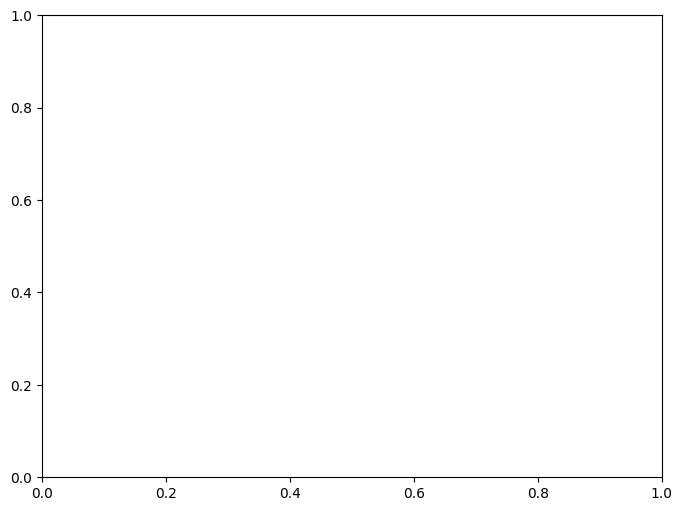

In [49]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x

def run_experiment(model, train_loader, test_loader, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        model.train()
        for epoch in range(num_epochs):
            total_loss = 0
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                loss = loss_op(output, data.y.float())
                total_loss += loss.item()
                loss.backward()
                optimizer.step()
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader)}")

    train()

def calculate_roc(loader):
    model.eval()
    all_preds = []
    all_labels = []
    for data in loader:
        data = data.to(device)
        out = torch.sigmoid(model(data.x, data.edge_index))
        all_preds.append(out.detach().cpu().numpy())
        all_labels.append(data.y.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(all_labels[:, i], all_preds[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve per Class')
    ax.legend(loc="lower right")
    plt.show()

def calculate_precision_recall(loader):
    model.eval()
    all_preds = []
    all_labels = []
    for data in loader:
        data = data.to(device)
        out = torch.sigmoid(model(data.x, data.edge_index))
        all_preds.append(out.detach().cpu().numpy())
        all_labels.append(data.y.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(all_labels[:, i], all_preds[:, i])
        ap = average_precision_score(all_labels[:, i], all_preds[:, i])
        ax.plot(recall, precision, label=f'Class {i} (AP = {ap:.2f})')

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curve per Class')
    ax.legend(loc="best")
    plt.show()

# Example usage
num_features = 2  # Adjust based on your dataset
num_classes = 3   # Adjust based on your dataset
model = GCN(num_features, 16, num_classes).to(device)

# Assuming train_loader and test_loader are defined and loaded with your dataset
run_experiment(model, train_loader, test_loader, num_epochs=100)

# After training, visualize the results
calculate_roc(test_loader)
calculate_precision_recall(test_loader)


Epoch 1/100, Loss: 0.6645253685956501
Epoch 2/100, Loss: 0.661403547663715
Epoch 3/100, Loss: 0.6607859473860724
Epoch 4/100, Loss: 0.6567703636970309
Epoch 5/100, Loss: 0.6499978906541898
Epoch 6/100, Loss: 0.6489523148668405
Epoch 7/100, Loss: 0.6460402835139912
Epoch 8/100, Loss: 0.64094329143756
Epoch 9/100, Loss: 0.6378010287469263
Epoch 10/100, Loss: 0.6391302972867344
Epoch 11/100, Loss: 0.6349931319774185
Epoch 12/100, Loss: 0.6301482132126613
Epoch 13/100, Loss: 0.6283149738996727
Epoch 14/100, Loss: 0.6271034801862516
Epoch 15/100, Loss: 0.625063157213327
Epoch 16/100, Loss: 0.620979400464843
Epoch 17/100, Loss: 0.6187952796398606
Epoch 18/100, Loss: 0.6160067978484854
Epoch 19/100, Loss: 0.6141911262636026
Epoch 20/100, Loss: 0.6158831741928396
Epoch 21/100, Loss: 0.6128269542646672
Epoch 22/100, Loss: 0.6124974996345478
Epoch 23/100, Loss: 0.6076813391229724
Epoch 24/100, Loss: 0.6075827275191882
Epoch 25/100, Loss: 0.6089121780013511
Epoch 26/100, Loss: 0.6079019727957183


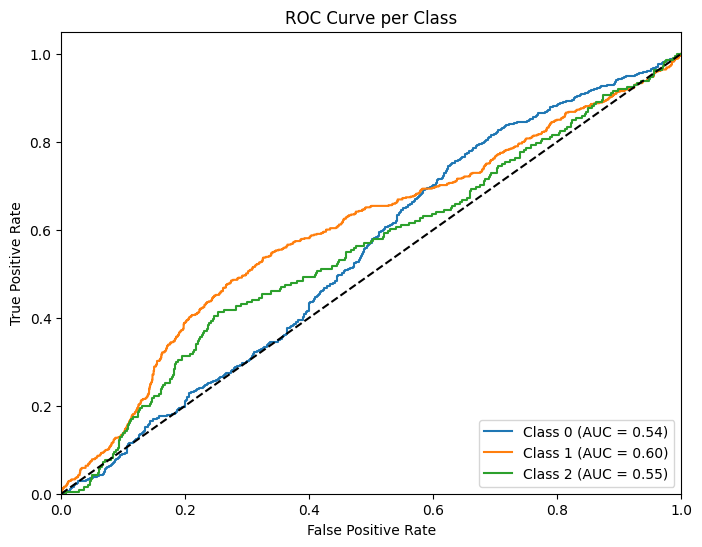

ValueError: Input contains NaN.

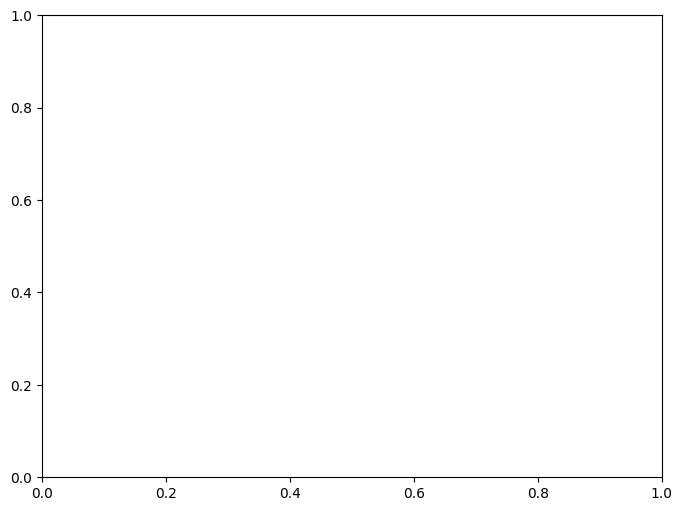

In [50]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x

def run_experiment(model, train_loader, test_loader, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        model.train()
        for epoch in range(num_epochs):
            total_loss = 0
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                loss = loss_op(output, data.y.float())
                total_loss += loss.item()
                loss.backward()
                optimizer.step()
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader)}")

    train()

def calculate_roc(loader):
    model.eval()
    all_preds = []
    all_labels = []
    for data in loader:
        data = data.to(device)
        out = torch.sigmoid(model(data.x, data.edge_index))
        all_preds.append(out.detach().cpu().numpy())
        all_labels.append(data.y.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(num_classes):
        # Handle NaN values in predictions and labels
        valid_idx = ~np.isnan(all_preds[:, i]) & ~np.isnan(all_labels[:, i])
        if np.sum(valid_idx) == 0:  # Skip this class if all are NaN
            print(f"Skipping Class {i} due to NaN values")
            continue
        fpr, tpr, _ = roc_curve(all_labels[valid_idx, i], all_preds[valid_idx, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve per Class')
    ax.legend(loc="lower right")
    plt.show()

def calculate_precision_recall(loader):
    model.eval()
    all_preds = []
    all_labels = []
    for data in loader:
        data = data.to(device)
        out = torch.sigmoid(model(data.x, data.edge_index))
        all_preds.append(out.detach().cpu().numpy())
        all_labels.append(data.y.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(all_labels[:, i], all_preds[:, i])
        ap = average_precision_score(all_labels[:, i], all_preds[:, i])
        ax.plot(recall, precision, label=f'Class {i} (AP = {ap:.2f})')

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curve per Class')
    ax.legend(loc="best")
    plt.show()

# Example usage
num_features = 2  # Adjust based on your dataset
num_classes = 3   # Adjust based on your dataset
model = GCN(num_features, 16, num_classes).to(device)

# Assuming train_loader and test_loader are defined and loaded with your dataset
run_experiment(model, train_loader, test_loader, num_epochs=100)

# After training, visualize the results
calculate_roc(test_loader)
calculate_precision_recall(test_loader)


In [51]:
from os import path
import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )

from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)
    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )
    # Calculate effective size
    eff_size = num_alters - avg_degree
    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0
    return eff_size, efficiency

def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego

def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego

def graph_features(gs):
    dfs = {}
    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []
        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)
            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)
            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)
            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))
            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)
            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)
        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )
    return dfs

def combine_features(market_features, graph_features):
    combined_data = {}
    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()
        combined_data[key] = combined_df
    return combined_data

def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]
        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_process = features_buffer[feature_columns]
        normalized_features = (
            features_to_process - features_to_process.mean()
        ) / features_to_process.std()
        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }
        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []
        features_df = features_buffer.set_index("telegram_chat_id")
        features_df = features_df[feature_columns]
        # Calculate cosine similarity for each pair of rows
        print(key)
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)
            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity
        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)
        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
        # Populate the lists
        num_labels = 3
        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)
        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency
            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)
        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)
        # Create a Data object
        data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
        prepared_data.append(data)
    return prepared_data

def get_new_data_loader():
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)


    return train_loader, test_loader


if __name__ == "__main__":
    a, b = get_new_data_loader()

/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

1INCH
AAVE
ADA
ADX
AERGO
AGI
AGIX
AION
ALGO
ALICE
ALPHA
AMB
ANT
APE
APPC
ARDR
ARK
ARN
ARPA
AST
ATOM
AUDIO
AVAX
AXS
BAKE
BAL
BAND
BAT
BCD
BCH
BCPT
BEL
BLZ
BNB
BQX
BRD
BTC
BZRX
CDT
CELO
CELR
CHR
CHZ
CMT
COTI
CRV
CTSI
CTXC
CVC
DASH
DATA
DIA
DLT
DNT
DOCK
DODO
DOGE
DOT
DREP
DUSK
DYDX
EGLD
ELF
ENG
ENJ
EOS
EPS
ETH
EVX
FET
FIL
FIO
FIS
FTM
GALA
GLM
GRS
GRT
GTO
GXS
HBAR
HIVE
HNT
ICP
IDEX
INJ
INS
IOST
IRIS
KAVA
KMD
KNC
LEND
LINK
LOOM
LRC
LTC
LTO
LUNA
MANA
MATIC
MDA
MDT
MITH
MKR
MTH
MTL
NAV
NEAR
NEBL
NKN
NULS
OAX
OGN
OM
OMG
ONG
OST
OXT
PERL
PHB
PIVX
PNT
POA
POLY
POND
POWR
PPT
QLC
QSP
QTUM
RCN
RDN
REN
REQ
RLC
RSR
RUNE
RVN
SAND
SKL
SKY
SNX
SOL
SRM
STEEM
STORJ
STPT
SUSHI
SXP
SYS
TCT
TFUEL
THETA
TLM
TOMO
TRB
TRU
TRX
TVK
UNI
UTK
VET
VIA
VIB
VIBE
VIDT
VITE
WABI
WAN
WAVES
WRX
WTC
XLM
XRP
XTZ
YFI
YFII
ZEC
ZEN
ZIL
1INCH
AAVE
ACA
ACE
ACH
ADA
AGIX
AGLD
AI
AKRO
ALCX
ALGO
ALICE
ALPACA
ALPHA
ALPINE
AMB
AMP
ANKR
ANT
APE
API3
APT
AR
ARB
ARK
ARPA
AST
ATOM
AUCTION
AUDIO
AVAX
AXS
BADGER
BAKE
BAL
BAND
BAR
BAT
BCH
BEL

In [53]:
a

In [54]:
b

In [55]:
# todo：more experiments the better, more comparison
class GCN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x


In [56]:
from os import path
import torch
import numpy as np
import torch.nn.functional as F
from torch_geometric.nn import GATConv, GCNConv, SAGEConv
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
)
import matplotlib.pyplot as plt
from clotho.model.data_loader import get_data_loader
from clotho.model.new_data_loader import get_new_data_loader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# TODO: no slicing window for average, just each epoch
# TODO: validation, test; test not in validation and training.
# TODO: Network comparison, frst three year and last years
# TODO: Three dataset test, train, validate
# TODO: write the paper by specifying how we label the data (see the review reply)

# validation needs not to show

# GAT
# 邻居点的采样方法，为什么要这样采样，如何设计采样方式
# 调参数，随机数
# random seed 44

# TODO: experiment with dani and without dani.
# todo：more experiments the better, more comparison
class GCN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x


# GCN Implementation
class GCNNet(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GCNNet, self).__init__()
        self.conv1 = GCNConv(num_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x


# GraphSAGE Implementation
class GraphSAGENet(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GraphSAGENet, self).__init__()
        self.conv1 = SAGEConv(num_features, 16)
        self.conv2 = SAGEConv(16, num_classes)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x


class Net(torch.nn.Module):
    def __init__(self):
        super().__init__()
        num_features = 4
        num_classes = 3
        self.conv1 = GATConv(num_features, 8, heads=2)
        self.lin1 = torch.nn.Linear(num_features, 2 * 8)
        self.conv2 = GATConv(2 * 8, 8, heads=2)
        self.lin2 = torch.nn.Linear(2 * 8, 2 * 8)
        self.conv3 = GATConv(2 * 8, num_classes, heads=2, concat=False)
        self.lin3 = torch.nn.Linear(2 * 8, num_classes)

    def forward(self, x, edge_index):
        if torch.isnan(x).any() or torch.isinf(x).any():
            print("NaN or Inf in input feature x")
        if torch.isnan(edge_index).any() or torch.isinf(edge_index).any():
            print("NaN or Inf in edge_index")
        x = F.elu(self.conv1(x, edge_index) + self.lin1(x))
        x = F.elu(self.conv2(x, edge_index) + self.lin2(x))
        x = self.conv3(x, edge_index) + self.lin3(x)
        return x


new_trl = a
new_tsl = b


def run_experiment(model, num_epochs=100):
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        for epoch in range(num_epochs):
            model.train()
            total_loss = 0
            for data in new_trl:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                if torch.isnan(output).any() or torch.isinf(output).any():
                    print("NaN or Inf in model output")
                    continue
                loss = loss_op(output, data.y.float())
                if torch.isnan(loss) or torch.isinf(loss):
                    print("NaN or Inf in loss")
                    continue
                total_loss += loss.item() * data.num_graphs
                loss.backward()
                optimizer.step()
            print(
                f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(new_trl.dataset)}"
            )

    @torch.no_grad()
    def test(loader):
        model.eval()
        all_probs, all_labels = [], []
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index)
            all_probs.append(out.cpu())
            all_labels.append(data.y.cpu())
        return all_probs, all_labels

    train()
    probs, labels = test(new_tsl)
    probs = torch.cat(probs, dim=0).sigmoid().numpy()
    labels = torch.cat(labels, dim=0).numpy()

    # Compute ROC for each label and store
    fpr_dict, tpr_dict, thresholds_dict = {}, {}, {}
    for i in range(labels.shape[1]):  # Assuming labels is a 2D array: [samples, labels]
        fpr, tpr, thresholds = roc_curve(labels[:, i], probs[:, i])
        fpr_dict[i], tpr_dict[i], thresholds_dict[i] = fpr, tpr, thresholds

    return model, fpr_dict, tpr_dict, thresholds_dict


# Updated Metrics Calculation Functions
def calculate_accuracy(labels, preds):
    return accuracy_score(labels, preds)


def calculate_precision(labels, preds):
    return precision_score(labels, preds, average="macro", zero_division=0)


def calculate_recall(labels, preds):
    return recall_score(labels, preds, average="macro", zero_division=0)


def calculate_f1_score(labels, preds):
    return f1_score(labels, preds, average="macro", zero_division=0)


# @torch.no_grad()
# def compute_metrics(model, loader):
#     model.eval()
#     all_probs, all_labels = [], []
#     for data in loader:
#         data = data.to(device)
#         out = model(data.x, data.edge_index)
#         all_probs.append(out.cpu())
#         all_labels.append(data.y.cpu())
#     probs = torch.cat(all_probs, dim=0).sigmoid().numpy()
#     labels = torch.cat(all_labels, dim=0).numpy()
#     preds = probs.argmax(axis=1)

#     # Converting labels for multi-class classification
#     labels = labels.argmax(axis=1)

#     # Calculating metrics
#     accuracy = calculate_accuracy(labels, preds)
#     precision = calculate_precision(labels, preds)
#     recall = calculate_recall(labels, preds)
#     f1 = calculate_f1_score(labels, preds)


# TODO: make the comparison 3 or 2
# TODO: https://pytorch-geometric.readthedocs.io/en/latest/tutorial/neighbor_loader.html?highlight=sampling
# TODO: https://neo4j.com/blog/graph-algorithms-neo4j-betweenness-centrality/?utm_source=google&utm_medium=PaidSearch&utm_campaign=GDB&utm_content=APAC-X-Awareness-GDB-Text&utm_term=&gad_source=1&gclid=CjwKCAiA7t6sBhAiEiwAsaieYoEzQ8natFE0mCoqHrA2LhWq6050KWKz4wOIzGqxJ3d7zIIrcQTmZxoCC1IQAvD_BwE
# TODO: (why we use the above sampling method, in degree and betweeness centrality)
# TODO: experiment for time evaluation and accurary


#     return accuracy, precision, recall, f1
@torch.no_grad()
def compute_metrics(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index)
        all_probs.append(out.cpu())
        all_labels.append(data.y.cpu())
    probs = torch.cat(all_probs, dim=0).sigmoid().numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    preds = probs.argmax(axis=1)
    labels = labels.argmax(axis=1)

    # Calculating metrics
    accuracy = calculate_accuracy(labels, preds)
    precision = calculate_precision(labels, preds)
    recall = calculate_recall(labels, preds)
    f1 = calculate_f1_score(labels, preds)

    # Additional Metrics
    cm = confusion_matrix(labels, preds)
    specificity = np.mean(
        [
            cm[i][i] / (cm[i][i] + np.sum(cm[:, i]) - cm[i][i])
            for i in range(cm.shape[0])
            if np.sum(cm[:, i]) - cm[i][i] != 0
        ]
    )
    prevalence = np.mean([np.sum(cm[i]) / np.sum(cm) for i in range(cm.shape[0])])
    detection_rate = np.mean(
        [cm[i][i] / np.sum(cm[i]) for i in range(cm.shape[0]) if np.sum(cm[i]) != 0]
    )
    detection_prevalence = np.mean(
        [np.sum(cm[:, i]) / np.sum(cm) for i in range(cm.shape[0])]
    )

    return (
        accuracy,
        precision,
        recall,
        f1,
        specificity,
        prevalence,
        detection_rate,
        detection_prevalence,
    )


# Run experiments for each model
num_features = 2  # Set this according to your dataset
num_classes = 3  # Set this according to your dataset

print("\nRunning GraphSAGE Experiment")
un_gcn, un_gcn_fpr, un_gcn_tpr, _ = run_experiment(
    GCN(num_features, 16, num_classes), num_epochs=100
)

gat_metrics = compute_metrics(un_gcn, test_loader)
print(
    f"GAT Model Metrics:\nAccuracy: {gat_metrics[0]}, Precision: {gat_metrics[1]}, Recall: {gat_metrics[2]}, F1 Score: {gat_metrics[3]}, Specificity: {gat_metrics[4]}, Prevalence: {gat_metrics[5]}, Detection Rate: {gat_metrics[6]}, Detection Prevalence: {gat_metrics[7]}\n"
)

# print("Running GAT Experiment")
# gat_model, gat_fpr, gat_tpr, _ = run_experiment(Net(), num_epochs=100)

# print("\nRunning GCN Experiment")
# gcn_model, gcn_fpr, gcn_tpr, _ = run_experiment(
#     GCNNet(num_features, num_classes), num_epochs=100
# )

# print("\nRunning GraphSAGE Experiment")
# graphsage_model, graphsage_fpr, graphsage_tpr, _ = run_experiment(
#     GraphSAGENet(num_features, num_classes), num_epochs=100
# )

# gat_metrics = compute_metrics(gat_model, test_loader)
# print(
#     f"GAT Model Metrics:\nAccuracy: {gat_metrics[0]}, Precision: {gat_metrics[1]}, Recall: {gat_metrics[2]}, F1 Score: {gat_metrics[3]}, Specificity: {gat_metrics[4]}, Prevalence: {gat_metrics[5]}, Detection Rate: {gat_metrics[6]}, Detection Prevalence: {gat_metrics[7]}\n"
# )

# gcn_metrics = compute_metrics(gcn_model, test_loader)
# print(
#     f"GAT Model Metrics:\nAccuracy: {gcn_metrics[0]}, Precision: {gcn_metrics[1]}, Recall: {gcn_metrics[2]}, F1 Score: {gcn_metrics[3]}, Specificity: {gcn_metrics[4]}, Prevalence: {gcn_metrics[5]}, Detection Rate: {gcn_metrics[6]}, Detection Prevalence: {gcn_metrics[7]}\n"
# )

# graphsage_metrics = compute_metrics(graphsage_model, test_loader)
# print(
#     f"GAT Model Metrics:\nAccuracy: {graphsage_metrics[0]}, Precision: {graphsage_metrics[1]}, Recall: {graphsage_metrics[2]}, F1 Score: {graphsage_metrics[3]}, Specificity: {graphsage_metrics[4]}, Prevalence: {graphsage_metrics[5]}, Detection Rate: {graphsage_metrics[6]}, Detection Prevalence: {graphsage_metrics[7]}\n"
# )


# Plotting ROC Curves
plt.figure(figsize=(10, 6))
label = 0  # Assuming we are plotting for the first label
# plt.plot(gat_fpr[label], gat_tpr[label], label="GAT")
# plt.plot(gcn_fpr[label], gcn_tpr[label], label="GCN")
# plt.plot(graphsage_fpr[label], graphsage_tpr[label], label="GraphSAGE")


plt.plot(un_gcn_fpr[label], un_gcn_tpr[label], label="GAT")
# plt.plot(gcn_fpr[label], gcn_tpr[label], label="GCN")
# plt.plot(graphsage_fpr[label], graphsage_tpr[label], label="GraphSAGE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()


Running GraphSAGE Experiment
Epoch 1/100, Loss: 0.7297667095345028
Epoch 2/100, Loss: 0.7131238895885194
Epoch 3/100, Loss: 0.6983042586574238
Epoch 4/100, Loss: 0.695006242114536
Epoch 5/100, Loss: 0.6849863357965459
Epoch 6/100, Loss: 0.6857282081361633
Epoch 7/100, Loss: 0.6757207218125381
Epoch 8/100, Loss: 0.6681245578586726
Epoch 9/100, Loss: 0.6609773181420004
Epoch 10/100, Loss: 0.657654412543576
Epoch 11/100, Loss: 0.6534439656286608
Epoch 12/100, Loss: 0.6486508819938365
Epoch 13/100, Loss: 0.6421269698696241
Epoch 14/100, Loss: 0.6386968164154179
Epoch 15/100, Loss: 0.6376829865229064
Epoch 16/100, Loss: 0.6339021674177264
Epoch 17/100, Loss: 0.6294960015715815
Epoch 18/100, Loss: 0.6304973969802014
Epoch 19/100, Loss: 0.6222536759811211
Epoch 20/100, Loss: 0.6256112861369855
Epoch 21/100, Loss: 0.621258868038325
Epoch 22/100, Loss: 0.616440573779259
Epoch 23/100, Loss: 0.6167695821978111
Epoch 24/100, Loss: 0.6131680568278823
Epoch 25/100, Loss: 0.6148866923803783
Epoch 26

ValueError: Input contains NaN.

In [58]:
from os import path
import torch
import numpy as np
import torch.nn.functional as F
from torch_geometric.nn import GATConv, GCNConv, SAGEConv
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
)
import matplotlib.pyplot as plt
from clotho.model.data_loader import get_data_loader
from clotho.model.new_data_loader import get_new_data_loader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# TODO: no slicing window for average, just each epoch
# TODO: validation, test; test not in validation and training.
# TODO: Network comparison, frst three year and last years
# TODO: Three dataset test, train, validate
# TODO: write the paper by specifying how we label the data (see the review reply)

# validation needs not to show

# GAT
# 邻居点的采样方法，为什么要这样采样，如何设计采样方式
# 调参数，随机数
# random seed 44

# TODO: experiment with dani and without dani.
# todo：more experiments the better, more comparison
class GCN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x


# GCN Implementation
class GCNNet(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GCNNet, self).__init__()
        self.conv1 = GCNConv(num_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x


# GraphSAGE Implementation
class GraphSAGENet(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GraphSAGENet, self).__init__()
        self.conv1 = SAGEConv(num_features, 16)
        self.conv2 = SAGEConv(16, num_classes)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x


class Net(torch.nn.Module):
    def __init__(self):
        super().__init__()
        num_features = 4
        num_classes = 3
        self.conv1 = GATConv(num_features, 8, heads=2)
        self.lin1 = torch.nn.Linear(num_features, 2 * 8)
        self.conv2 = GATConv(2 * 8, 8, heads=2)
        self.lin2 = torch.nn.Linear(2 * 8, 2 * 8)
        self.conv3 = GATConv(2 * 8, num_classes, heads=2, concat=False)
        self.lin3 = torch.nn.Linear(2 * 8, num_classes)

    def forward(self, x, edge_index):
        if torch.isnan(x).any() or torch.isinf(x).any():
            print("NaN or Inf in input feature x")
        if torch.isnan(edge_index).any() or torch.isinf(edge_index).any():
            print("NaN or Inf in edge_index")
        x = F.elu(self.conv1(x, edge_index) + self.lin1(x))
        x = F.elu(self.conv2(x, edge_index) + self.lin2(x))
        x = self.conv3(x, edge_index) + self.lin3(x)
        return x


new_trl = a
new_tsl = b










def run_experiment(model, num_epochs=100):
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        for epoch in range(num_epochs):
            model.train()
            total_loss = 0
            for data in new_trl:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                if torch.isnan(output).any() or torch.isinf(output).any():
                    print("NaN or Inf in model output")
                    continue
                loss = loss_op(output, data.y.float())
                if torch.isnan(loss) or torch.isinf(loss):
                    print("NaN or Inf in loss")
                    continue
                total_loss += loss.item() * data.num_graphs
                loss.backward()
                optimizer.step()
            print(
                f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(new_trl.dataset)}"
            )

    @torch.no_grad()
    def test(loader):
        model.eval()
        all_probs, all_labels = [], []
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index)
            all_probs.append(out.cpu())
            all_labels.append(data.y.cpu())
        return all_probs, all_labels

    train()
    probs, labels = test(new_tsl)

    # Check for NaN values
    if np.isnan(probs).any() or np.isnan(labels).any():
        print("NaN values encountered. Skipping ROC curve and graph plotting.")
        return model, None, None, None

    # Compute ROC for each label and store
    fpr_dict, tpr_dict, thresholds_dict = {}, {}, {}
    for i in range(labels.shape[1]):
        fpr, tpr, thresholds = roc_curve(labels[:, i], probs[:, i])
        fpr_dict[i], tpr_dict[i], thresholds_dict[i] = fpr, tpr, thresholds

    return model, fpr_dict, tpr_dict, thresholds_dict

    # def train():
    #     for epoch in range(num_epochs):
    #         model.train()
    #         total_loss = 0
    #         for data in new_trl:
    #             data = data.to(device)
    #             optimizer.zero_grad()
    #             output = model(data.x, data.edge_index)
    #             if torch.isnan(output).any() or torch.isinf(output).any():
    #                 print("NaN or Inf in model output")
    #                 continue
    #             loss = loss_op(output, data.y.float())
    #             if torch.isnan(loss) or torch.isinf(loss):
    #                 print("NaN or Inf in loss")
    #                 continue
    #             total_loss += loss.item() * data.num_graphs
    #             loss.backward()
    #             optimizer.step()
    #         print(
    #             f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(new_trl.dataset)}"
    #         )

    # @torch.no_grad()
    # def test(loader):
    #     model.eval()
    #     all_probs, all_labels = [], []
    #     for data in loader:
    #         data = data.to(device)
    #         out = model(data.x, data.edge_index)
    #         all_probs.append(out.cpu())
    #         all_labels.append(data.y.cpu())
    #     return all_probs, all_labels

    # train()
    # probs, labels = test(new_tsl)
    # probs = torch.cat(probs, dim=0).sigmoid().numpy()
    # labels = torch.cat(labels, dim=0).numpy()

    # # Compute ROC for each label and store
    # fpr_dict, tpr_dict, thresholds_dict = {}, {}, {}
    # for i in range(labels.shape[1]):  # Assuming labels is a 2D array: [samples, labels]
    #     fpr, tpr, thresholds = roc_curve(labels[:, i], probs[:, i])
    #     fpr_dict[i], tpr_dict[i], thresholds_dict[i] = fpr, tpr, thresholds

    # return model, fpr_dict, tpr_dict, thresholds_dict


# Updated Metrics Calculation Functions
def calculate_accuracy(labels, preds):
    return accuracy_score(labels, preds)


def calculate_precision(labels, preds):
    return precision_score(labels, preds, average="macro", zero_division=0)


def calculate_recall(labels, preds):
    return recall_score(labels, preds, average="macro", zero_division=0)


def calculate_f1_score(labels, preds):
    return f1_score(labels, preds, average="macro", zero_division=0)


# @torch.no_grad()
# def compute_metrics(model, loader):
#     model.eval()
#     all_probs, all_labels = [], []
#     for data in loader:
#         data = data.to(device)
#         out = model(data.x, data.edge_index)
#         all_probs.append(out.cpu())
#         all_labels.append(data.y.cpu())
#     probs = torch.cat(all_probs, dim=0).sigmoid().numpy()
#     labels = torch.cat(all_labels, dim=0).numpy()
#     preds = probs.argmax(axis=1)

#     # Converting labels for multi-class classification
#     labels = labels.argmax(axis=1)

#     # Calculating metrics
#     accuracy = calculate_accuracy(labels, preds)
#     precision = calculate_precision(labels, preds)
#     recall = calculate_recall(labels, preds)
#     f1 = calculate_f1_score(labels, preds)


# TODO: make the comparison 3 or 2
# TODO: https://pytorch-geometric.readthedocs.io/en/latest/tutorial/neighbor_loader.html?highlight=sampling
# TODO: https://neo4j.com/blog/graph-algorithms-neo4j-betweenness-centrality/?utm_source=google&utm_medium=PaidSearch&utm_campaign=GDB&utm_content=APAC-X-Awareness-GDB-Text&utm_term=&gad_source=1&gclid=CjwKCAiA7t6sBhAiEiwAsaieYoEzQ8natFE0mCoqHrA2LhWq6050KWKz4wOIzGqxJ3d7zIIrcQTmZxoCC1IQAvD_BwE
# TODO: (why we use the above sampling method, in degree and betweeness centrality)
# TODO: experiment for time evaluation and accurary


#     return accuracy, precision, recall, f1
@torch.no_grad()
def compute_metrics(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index)
        all_probs.append(out.cpu())
        all_labels.append(data.y.cpu())
    probs = torch.cat(all_probs, dim=0).sigmoid().numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    preds = probs.argmax(axis=1)
    labels = labels.argmax(axis=1)

    # Calculating metrics
    accuracy = calculate_accuracy(labels, preds)
    precision = calculate_precision(labels, preds)
    recall = calculate_recall(labels, preds)
    f1 = calculate_f1_score(labels, preds)

    # Additional Metrics
    cm = confusion_matrix(labels, preds)
    specificity = np.mean(
        [
            cm[i][i] / (cm[i][i] + np.sum(cm[:, i]) - cm[i][i])
            for i in range(cm.shape[0])
            if np.sum(cm[:, i]) - cm[i][i] != 0
        ]
    )
    prevalence = np.mean([np.sum(cm[i]) / np.sum(cm) for i in range(cm.shape[0])])
    detection_rate = np.mean(
        [cm[i][i] / np.sum(cm[i]) for i in range(cm.shape[0]) if np.sum(cm[i]) != 0]
    )
    detection_prevalence = np.mean(
        [np.sum(cm[:, i]) / np.sum(cm) for i in range(cm.shape[0])]
    )

    return (
        accuracy,
        precision,
        recall,
        f1,
        specificity,
        prevalence,
        detection_rate,
        detection_prevalence,
    )


# Run experiments for each model
num_features = 2  # Set this according to your dataset
num_classes = 3  # Set this according to your dataset

print("\nRunning GraphSAGE Experiment")
un_gcn, un_gcn_fpr, un_gcn_tpr, _ = run_experiment(
    GCN(num_features, 16, num_classes), num_epochs=100
)

gat_metrics = compute_metrics(un_gcn, test_loader)
print(
    f"GAT Model Metrics:\nAccuracy: {gat_metrics[0]}, Precision: {gat_metrics[1]}, Recall: {gat_metrics[2]}, F1 Score: {gat_metrics[3]}, Specificity: {gat_metrics[4]}, Prevalence: {gat_metrics[5]}, Detection Rate: {gat_metrics[6]}, Detection Prevalence: {gat_metrics[7]}\n"
)

# print("Running GAT Experiment")
# gat_model, gat_fpr, gat_tpr, _ = run_experiment(Net(), num_epochs=100)

# print("\nRunning GCN Experiment")
# gcn_model, gcn_fpr, gcn_tpr, _ = run_experiment(
#     GCNNet(num_features, num_classes), num_epochs=100
# )

# print("\nRunning GraphSAGE Experiment")
# graphsage_model, graphsage_fpr, graphsage_tpr, _ = run_experiment(
#     GraphSAGENet(num_features, num_classes), num_epochs=100
# )

# gat_metrics = compute_metrics(gat_model, test_loader)
# print(
#     f"GAT Model Metrics:\nAccuracy: {gat_metrics[0]}, Precision: {gat_metrics[1]}, Recall: {gat_metrics[2]}, F1 Score: {gat_metrics[3]}, Specificity: {gat_metrics[4]}, Prevalence: {gat_metrics[5]}, Detection Rate: {gat_metrics[6]}, Detection Prevalence: {gat_metrics[7]}\n"
# )

# gcn_metrics = compute_metrics(gcn_model, test_loader)
# print(
#     f"GAT Model Metrics:\nAccuracy: {gcn_metrics[0]}, Precision: {gcn_metrics[1]}, Recall: {gcn_metrics[2]}, F1 Score: {gcn_metrics[3]}, Specificity: {gcn_metrics[4]}, Prevalence: {gcn_metrics[5]}, Detection Rate: {gcn_metrics[6]}, Detection Prevalence: {gcn_metrics[7]}\n"
# )

# graphsage_metrics = compute_metrics(graphsage_model, test_loader)
# print(
#     f"GAT Model Metrics:\nAccuracy: {graphsage_metrics[0]}, Precision: {graphsage_metrics[1]}, Recall: {graphsage_metrics[2]}, F1 Score: {graphsage_metrics[3]}, Specificity: {graphsage_metrics[4]}, Prevalence: {graphsage_metrics[5]}, Detection Rate: {graphsage_metrics[6]}, Detection Prevalence: {graphsage_metrics[7]}\n"
# )


# Plotting ROC Curves
plt.figure(figsize=(10, 6))
label = 0  # Assuming we are plotting for the first label
# plt.plot(gat_fpr[label], gat_tpr[label], label="GAT")
# plt.plot(gcn_fpr[label], gcn_tpr[label], label="GCN")
# plt.plot(graphsage_fpr[label], graphsage_tpr[label], label="GraphSAGE")


plt.plot(un_gcn_fpr[label], un_gcn_tpr[label], label="GAT")
# plt.plot(gcn_fpr[label], gcn_tpr[label], label="GCN")
# plt.plot(graphsage_fpr[label], graphsage_tpr[label], label="GraphSAGE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()


Running GraphSAGE Experiment
Epoch 1/100, Loss: 0.7120273337179784
Epoch 2/100, Loss: 0.7060323094136148
Epoch 3/100, Loss: 0.6988186500349097
Epoch 4/100, Loss: 0.6923486060200476
Epoch 5/100, Loss: 0.6852515293748339
Epoch 6/100, Loss: 0.6801381361418666
Epoch 7/100, Loss: 0.6821403263023545
Epoch 8/100, Loss: 0.6732546255733427
Epoch 9/100, Loss: 0.6622130880698315
Epoch 10/100, Loss: 0.6605009923982357
Epoch 11/100, Loss: 0.6603116396382369
Epoch 12/100, Loss: 0.6584359028721383
Epoch 13/100, Loss: 0.6530026665050022
Epoch 14/100, Loss: 0.6482106990577108
Epoch 15/100, Loss: 0.6458199873813608
Epoch 16/100, Loss: 0.6414966471287427
Epoch 17/100, Loss: 0.6381001447775088
Epoch 18/100, Loss: 0.6330655763821048
Epoch 19/100, Loss: 0.629829751029199
Epoch 20/100, Loss: 0.6302053790066123
Epoch 21/100, Loss: 0.627877308518847
Epoch 22/100, Loss: 0.6247105208220403
Epoch 23/100, Loss: 0.6261765245574614
Epoch 24/100, Loss: 0.6204743093877866
Epoch 25/100, Loss: 0.6169662839470648
Epoch 

<ipython-input-58-f70c6775362f>:156: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  if np.isnan(probs).any() or np.isnan(labels).any():


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (261,) + inhomogeneous part.

In [59]:
from os import path
import torch
import numpy as np
import torch.nn.functional as F
from torch_geometric.nn import GATConv, GCNConv, SAGEConv
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
)
import matplotlib.pyplot as plt
from clotho.model.data_loader import get_data_loader
from clotho.model.new_data_loader import get_new_data_loader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# TODO: no slicing window for average, just each epoch
# TODO: validation, test; test not in validation and training.
# TODO: Network comparison, frst three year and last years
# TODO: Three dataset test, train, validate
# TODO: write the paper by specifying how we label the data (see the review reply)

# validation needs not to show

# GAT
# 邻居点的采样方法，为什么要这样采样，如何设计采样方式
# 调参数，随机数
# random seed 44

# TODO: experiment with dani and without dani.
# todo：more experiments the better, more comparison
class GCN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        if torch.isnan(x).any() or torch.isinf(x).any():
            print("NaN or Inf in input feature x")
        if torch.isnan(edge_index).any() or torch.isinf(edge_index).any():
            print("NaN or Inf in edge_index")
        if torch.isnan(edge_weight).any() or torch.isinf(edge_weight).any():
            print("NaN or Inf in edge_weight")
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x


# GCN Implementation
class GCNNet(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GCNNet, self).__init__()
        self.conv1 = GCNConv(num_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x


# GraphSAGE Implementation
class GraphSAGENet(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GraphSAGENet, self).__init__()
        self.conv1 = SAGEConv(num_features, 16)
        self.conv2 = SAGEConv(16, num_classes)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x


class Net(torch.nn.Module):
    def __init__(self):
        super().__init__()
        num_features = 4
        num_classes = 3
        self.conv1 = GATConv(num_features, 8, heads=2)
        self.lin1 = torch.nn.Linear(num_features, 2 * 8)
        self.conv2 = GATConv(2 * 8, 8, heads=2)
        self.lin2 = torch.nn.Linear(2 * 8, 2 * 8)
        self.conv3 = GATConv(2 * 8, num_classes, heads=2, concat=False)
        self.lin3 = torch.nn.Linear(2 * 8, num_classes)

    def forward(self, x, edge_index):
        if torch.isnan(x).any() or torch.isinf(x).any():
            print("NaN or Inf in input feature x")
        if torch.isnan(edge_index).any() or torch.isinf(edge_index).any():
            print("NaN or Inf in edge_index")
        x = F.elu(self.conv1(x, edge_index) + self.lin1(x))
        x = F.elu(self.conv2(x, edge_index) + self.lin2(x))
        x = self.conv3(x, edge_index) + self.lin3(x)
        return x


new_trl = a
new_tsl = b










def run_experiment(model, num_epochs=100):
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        for epoch in range(num_epochs):
            model.train()
            total_loss = 0
            for data in new_trl:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                if torch.isnan(output).any() or torch.isinf(output).any():
                    print("NaN or Inf in model output")
                    continue
                loss = loss_op(output, data.y.float())
                if torch.isnan(loss) or torch.isinf(loss):
                    print("NaN or Inf in loss")
                    continue
                total_loss += loss.item() * data.num_graphs
                loss.backward()
                optimizer.step()
            print(
                f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(new_trl.dataset)}"
            )

    @torch.no_grad()
    def test(loader):
        model.eval()
        all_probs, all_labels = [], []
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index)
            all_probs.append(out.cpu())
            all_labels.append(data.y.cpu())
        return all_probs, all_labels

    train()
    probs, labels = test(new_tsl)

    # Check for NaN values
    if np.isnan(probs).any() or np.isnan(labels).any():
        print("NaN values encountered. Skipping ROC curve and graph plotting.")
        return model, None, None, None

    # Compute ROC for each label and store
    fpr_dict, tpr_dict, thresholds_dict = {}, {}, {}
    for i in range(labels.shape[1]):
        fpr, tpr, thresholds = roc_curve(labels[:, i], probs[:, i])
        fpr_dict[i], tpr_dict[i], thresholds_dict[i] = fpr, tpr, thresholds

    return model, fpr_dict, tpr_dict, thresholds_dict

    # def train():
    #     for epoch in range(num_epochs):
    #         model.train()
    #         total_loss = 0
    #         for data in new_trl:
    #             data = data.to(device)
    #             optimizer.zero_grad()
    #             output = model(data.x, data.edge_index)
    #             if torch.isnan(output).any() or torch.isinf(output).any():
    #                 print("NaN or Inf in model output")
    #                 continue
    #             loss = loss_op(output, data.y.float())
    #             if torch.isnan(loss) or torch.isinf(loss):
    #                 print("NaN or Inf in loss")
    #                 continue
    #             total_loss += loss.item() * data.num_graphs
    #             loss.backward()
    #             optimizer.step()
    #         print(
    #             f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(new_trl.dataset)}"
    #         )

    # @torch.no_grad()
    # def test(loader):
    #     model.eval()
    #     all_probs, all_labels = [], []
    #     for data in loader:
    #         data = data.to(device)
    #         out = model(data.x, data.edge_index)
    #         all_probs.append(out.cpu())
    #         all_labels.append(data.y.cpu())
    #     return all_probs, all_labels

    # train()
    # probs, labels = test(new_tsl)
    # probs = torch.cat(probs, dim=0).sigmoid().numpy()
    # labels = torch.cat(labels, dim=0).numpy()

    # # Compute ROC for each label and store
    # fpr_dict, tpr_dict, thresholds_dict = {}, {}, {}
    # for i in range(labels.shape[1]):  # Assuming labels is a 2D array: [samples, labels]
    #     fpr, tpr, thresholds = roc_curve(labels[:, i], probs[:, i])
    #     fpr_dict[i], tpr_dict[i], thresholds_dict[i] = fpr, tpr, thresholds

    # return model, fpr_dict, tpr_dict, thresholds_dict


# Updated Metrics Calculation Functions
def calculate_accuracy(labels, preds):
    return accuracy_score(labels, preds)


def calculate_precision(labels, preds):
    return precision_score(labels, preds, average="macro", zero_division=0)


def calculate_recall(labels, preds):
    return recall_score(labels, preds, average="macro", zero_division=0)


def calculate_f1_score(labels, preds):
    return f1_score(labels, preds, average="macro", zero_division=0)


# @torch.no_grad()
# def compute_metrics(model, loader):
#     model.eval()
#     all_probs, all_labels = [], []
#     for data in loader:
#         data = data.to(device)
#         out = model(data.x, data.edge_index)
#         all_probs.append(out.cpu())
#         all_labels.append(data.y.cpu())
#     probs = torch.cat(all_probs, dim=0).sigmoid().numpy()
#     labels = torch.cat(all_labels, dim=0).numpy()
#     preds = probs.argmax(axis=1)

#     # Converting labels for multi-class classification
#     labels = labels.argmax(axis=1)

#     # Calculating metrics
#     accuracy = calculate_accuracy(labels, preds)
#     precision = calculate_precision(labels, preds)
#     recall = calculate_recall(labels, preds)
#     f1 = calculate_f1_score(labels, preds)


# TODO: make the comparison 3 or 2
# TODO: https://pytorch-geometric.readthedocs.io/en/latest/tutorial/neighbor_loader.html?highlight=sampling
# TODO: https://neo4j.com/blog/graph-algorithms-neo4j-betweenness-centrality/?utm_source=google&utm_medium=PaidSearch&utm_campaign=GDB&utm_content=APAC-X-Awareness-GDB-Text&utm_term=&gad_source=1&gclid=CjwKCAiA7t6sBhAiEiwAsaieYoEzQ8natFE0mCoqHrA2LhWq6050KWKz4wOIzGqxJ3d7zIIrcQTmZxoCC1IQAvD_BwE
# TODO: (why we use the above sampling method, in degree and betweeness centrality)
# TODO: experiment for time evaluation and accurary


#     return accuracy, precision, recall, f1
@torch.no_grad()
def compute_metrics(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index)
        all_probs.append(out.cpu())
        all_labels.append(data.y.cpu())
    probs = torch.cat(all_probs, dim=0).sigmoid().numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    preds = probs.argmax(axis=1)
    labels = labels.argmax(axis=1)

    # Calculating metrics
    accuracy = calculate_accuracy(labels, preds)
    precision = calculate_precision(labels, preds)
    recall = calculate_recall(labels, preds)
    f1 = calculate_f1_score(labels, preds)

    # Additional Metrics
    cm = confusion_matrix(labels, preds)
    specificity = np.mean(
        [
            cm[i][i] / (cm[i][i] + np.sum(cm[:, i]) - cm[i][i])
            for i in range(cm.shape[0])
            if np.sum(cm[:, i]) - cm[i][i] != 0
        ]
    )
    prevalence = np.mean([np.sum(cm[i]) / np.sum(cm) for i in range(cm.shape[0])])
    detection_rate = np.mean(
        [cm[i][i] / np.sum(cm[i]) for i in range(cm.shape[0]) if np.sum(cm[i]) != 0]
    )
    detection_prevalence = np.mean(
        [np.sum(cm[:, i]) / np.sum(cm) for i in range(cm.shape[0])]
    )

    return (
        accuracy,
        precision,
        recall,
        f1,
        specificity,
        prevalence,
        detection_rate,
        detection_prevalence,
    )


# Run experiments for each model
num_features = 2  # Set this according to your dataset
num_classes = 3  # Set this according to your dataset

print("\nRunning GraphSAGE Experiment")
un_gcn, un_gcn_fpr, un_gcn_tpr, _ = run_experiment(
    GCN(num_features, 16, num_classes), num_epochs=100
)

gat_metrics = compute_metrics(un_gcn, test_loader)
print(
    f"GAT Model Metrics:\nAccuracy: {gat_metrics[0]}, Precision: {gat_metrics[1]}, Recall: {gat_metrics[2]}, F1 Score: {gat_metrics[3]}, Specificity: {gat_metrics[4]}, Prevalence: {gat_metrics[5]}, Detection Rate: {gat_metrics[6]}, Detection Prevalence: {gat_metrics[7]}\n"
)

# print("Running GAT Experiment")
# gat_model, gat_fpr, gat_tpr, _ = run_experiment(Net(), num_epochs=100)

# print("\nRunning GCN Experiment")
# gcn_model, gcn_fpr, gcn_tpr, _ = run_experiment(
#     GCNNet(num_features, num_classes), num_epochs=100
# )

# print("\nRunning GraphSAGE Experiment")
# graphsage_model, graphsage_fpr, graphsage_tpr, _ = run_experiment(
#     GraphSAGENet(num_features, num_classes), num_epochs=100
# )

# gat_metrics = compute_metrics(gat_model, test_loader)
# print(
#     f"GAT Model Metrics:\nAccuracy: {gat_metrics[0]}, Precision: {gat_metrics[1]}, Recall: {gat_metrics[2]}, F1 Score: {gat_metrics[3]}, Specificity: {gat_metrics[4]}, Prevalence: {gat_metrics[5]}, Detection Rate: {gat_metrics[6]}, Detection Prevalence: {gat_metrics[7]}\n"
# )

# gcn_metrics = compute_metrics(gcn_model, test_loader)
# print(
#     f"GAT Model Metrics:\nAccuracy: {gcn_metrics[0]}, Precision: {gcn_metrics[1]}, Recall: {gcn_metrics[2]}, F1 Score: {gcn_metrics[3]}, Specificity: {gcn_metrics[4]}, Prevalence: {gcn_metrics[5]}, Detection Rate: {gcn_metrics[6]}, Detection Prevalence: {gcn_metrics[7]}\n"
# )

# graphsage_metrics = compute_metrics(graphsage_model, test_loader)
# print(
#     f"GAT Model Metrics:\nAccuracy: {graphsage_metrics[0]}, Precision: {graphsage_metrics[1]}, Recall: {graphsage_metrics[2]}, F1 Score: {graphsage_metrics[3]}, Specificity: {graphsage_metrics[4]}, Prevalence: {graphsage_metrics[5]}, Detection Rate: {graphsage_metrics[6]}, Detection Prevalence: {graphsage_metrics[7]}\n"
# )


# Plotting ROC Curves
plt.figure(figsize=(10, 6))
label = 0  # Assuming we are plotting for the first label
# plt.plot(gat_fpr[label], gat_tpr[label], label="GAT")
# plt.plot(gcn_fpr[label], gcn_tpr[label], label="GCN")
# plt.plot(graphsage_fpr[label], graphsage_tpr[label], label="GraphSAGE")


plt.plot(un_gcn_fpr[label], un_gcn_tpr[label], label="GAT")
# plt.plot(gcn_fpr[label], gcn_tpr[label], label="GCN")
# plt.plot(graphsage_fpr[label], graphsage_tpr[label], label="GraphSAGE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()


Running GraphSAGE Experiment


TypeError: isnan(): argument 'input' (position 1) must be Tensor, not NoneType

In [60]:
from os import path
import torch
import numpy as np
import torch.nn.functional as F
from torch_geometric.nn import GATConv, GCNConv, SAGEConv
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
)
import matplotlib.pyplot as plt
from clotho.model.data_loader import get_data_loader
from clotho.model.new_data_loader import get_new_data_loader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# TODO: no slicing window for average, just each epoch
# TODO: validation, test; test not in validation and training.
# TODO: Network comparison, frst three year and last years
# TODO: Three dataset test, train, validate
# TODO: write the paper by specifying how we label the data (see the review reply)

# validation needs not to show

# GAT
# 邻居点的采样方法，为什么要这样采样，如何设计采样方式
# 调参数，随机数
# random seed 44

# TODO: experiment with dani and without dani.
# todo：more experiments the better, more comparison
class GCN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        if torch.isnan(x).any() or torch.isinf(x).any():
            print("NaN or Inf in input feature x")
        if torch.isnan(edge_index).any() or torch.isinf(edge_index).any():
            print("NaN or Inf in edge_index")
        # if torch.isnan(edge_weight).any() or torch.isinf(edge_weight).any():
        #     print("NaN or Inf in edge_weight")
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x


# GCN Implementation
class GCNNet(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GCNNet, self).__init__()
        self.conv1 = GCNConv(num_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x


# GraphSAGE Implementation
class GraphSAGENet(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GraphSAGENet, self).__init__()
        self.conv1 = SAGEConv(num_features, 16)
        self.conv2 = SAGEConv(16, num_classes)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x


class Net(torch.nn.Module):
    def __init__(self):
        super().__init__()
        num_features = 4
        num_classes = 3
        self.conv1 = GATConv(num_features, 8, heads=2)
        self.lin1 = torch.nn.Linear(num_features, 2 * 8)
        self.conv2 = GATConv(2 * 8, 8, heads=2)
        self.lin2 = torch.nn.Linear(2 * 8, 2 * 8)
        self.conv3 = GATConv(2 * 8, num_classes, heads=2, concat=False)
        self.lin3 = torch.nn.Linear(2 * 8, num_classes)

    def forward(self, x, edge_index):
        if torch.isnan(x).any() or torch.isinf(x).any():
            print("NaN or Inf in input feature x")
        if torch.isnan(edge_index).any() or torch.isinf(edge_index).any():
            print("NaN or Inf in edge_index")
        x = F.elu(self.conv1(x, edge_index) + self.lin1(x))
        x = F.elu(self.conv2(x, edge_index) + self.lin2(x))
        x = self.conv3(x, edge_index) + self.lin3(x)
        return x


new_trl = a
new_tsl = b










def run_experiment(model, num_epochs=100):
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        for epoch in range(num_epochs):
            model.train()
            total_loss = 0
            for data in new_trl:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                if torch.isnan(output).any() or torch.isinf(output).any():
                    print("NaN or Inf in model output")
                    continue
                loss = loss_op(output, data.y.float())
                if torch.isnan(loss) or torch.isinf(loss):
                    print("NaN or Inf in loss")
                    continue
                total_loss += loss.item() * data.num_graphs
                loss.backward()
                optimizer.step()
            print(
                f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(new_trl.dataset)}"
            )

    @torch.no_grad()
    def test(loader):
        model.eval()
        all_probs, all_labels = [], []
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index)
            all_probs.append(out.cpu())
            all_labels.append(data.y.cpu())
        return all_probs, all_labels

    train()
    probs, labels = test(new_tsl)

    # Check for NaN values
    if np.isnan(probs).any() or np.isnan(labels).any():
        print("NaN values encountered. Skipping ROC curve and graph plotting.")
        return model, None, None, None

    # Compute ROC for each label and store
    fpr_dict, tpr_dict, thresholds_dict = {}, {}, {}
    for i in range(labels.shape[1]):
        fpr, tpr, thresholds = roc_curve(labels[:, i], probs[:, i])
        fpr_dict[i], tpr_dict[i], thresholds_dict[i] = fpr, tpr, thresholds

    return model, fpr_dict, tpr_dict, thresholds_dict

    # def train():
    #     for epoch in range(num_epochs):
    #         model.train()
    #         total_loss = 0
    #         for data in new_trl:
    #             data = data.to(device)
    #             optimizer.zero_grad()
    #             output = model(data.x, data.edge_index)
    #             if torch.isnan(output).any() or torch.isinf(output).any():
    #                 print("NaN or Inf in model output")
    #                 continue
    #             loss = loss_op(output, data.y.float())
    #             if torch.isnan(loss) or torch.isinf(loss):
    #                 print("NaN or Inf in loss")
    #                 continue
    #             total_loss += loss.item() * data.num_graphs
    #             loss.backward()
    #             optimizer.step()
    #         print(
    #             f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(new_trl.dataset)}"
    #         )

    # @torch.no_grad()
    # def test(loader):
    #     model.eval()
    #     all_probs, all_labels = [], []
    #     for data in loader:
    #         data = data.to(device)
    #         out = model(data.x, data.edge_index)
    #         all_probs.append(out.cpu())
    #         all_labels.append(data.y.cpu())
    #     return all_probs, all_labels

    # train()
    # probs, labels = test(new_tsl)
    # probs = torch.cat(probs, dim=0).sigmoid().numpy()
    # labels = torch.cat(labels, dim=0).numpy()

    # # Compute ROC for each label and store
    # fpr_dict, tpr_dict, thresholds_dict = {}, {}, {}
    # for i in range(labels.shape[1]):  # Assuming labels is a 2D array: [samples, labels]
    #     fpr, tpr, thresholds = roc_curve(labels[:, i], probs[:, i])
    #     fpr_dict[i], tpr_dict[i], thresholds_dict[i] = fpr, tpr, thresholds

    # return model, fpr_dict, tpr_dict, thresholds_dict


# Updated Metrics Calculation Functions
def calculate_accuracy(labels, preds):
    return accuracy_score(labels, preds)


def calculate_precision(labels, preds):
    return precision_score(labels, preds, average="macro", zero_division=0)


def calculate_recall(labels, preds):
    return recall_score(labels, preds, average="macro", zero_division=0)


def calculate_f1_score(labels, preds):
    return f1_score(labels, preds, average="macro", zero_division=0)


# @torch.no_grad()
# def compute_metrics(model, loader):
#     model.eval()
#     all_probs, all_labels = [], []
#     for data in loader:
#         data = data.to(device)
#         out = model(data.x, data.edge_index)
#         all_probs.append(out.cpu())
#         all_labels.append(data.y.cpu())
#     probs = torch.cat(all_probs, dim=0).sigmoid().numpy()
#     labels = torch.cat(all_labels, dim=0).numpy()
#     preds = probs.argmax(axis=1)

#     # Converting labels for multi-class classification
#     labels = labels.argmax(axis=1)

#     # Calculating metrics
#     accuracy = calculate_accuracy(labels, preds)
#     precision = calculate_precision(labels, preds)
#     recall = calculate_recall(labels, preds)
#     f1 = calculate_f1_score(labels, preds)


# TODO: make the comparison 3 or 2
# TODO: https://pytorch-geometric.readthedocs.io/en/latest/tutorial/neighbor_loader.html?highlight=sampling
# TODO: https://neo4j.com/blog/graph-algorithms-neo4j-betweenness-centrality/?utm_source=google&utm_medium=PaidSearch&utm_campaign=GDB&utm_content=APAC-X-Awareness-GDB-Text&utm_term=&gad_source=1&gclid=CjwKCAiA7t6sBhAiEiwAsaieYoEzQ8natFE0mCoqHrA2LhWq6050KWKz4wOIzGqxJ3d7zIIrcQTmZxoCC1IQAvD_BwE
# TODO: (why we use the above sampling method, in degree and betweeness centrality)
# TODO: experiment for time evaluation and accurary


#     return accuracy, precision, recall, f1
@torch.no_grad()
def compute_metrics(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index)
        all_probs.append(out.cpu())
        all_labels.append(data.y.cpu())
    probs = torch.cat(all_probs, dim=0).sigmoid().numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    preds = probs.argmax(axis=1)
    labels = labels.argmax(axis=1)

    # Calculating metrics
    accuracy = calculate_accuracy(labels, preds)
    precision = calculate_precision(labels, preds)
    recall = calculate_recall(labels, preds)
    f1 = calculate_f1_score(labels, preds)

    # Additional Metrics
    cm = confusion_matrix(labels, preds)
    specificity = np.mean(
        [
            cm[i][i] / (cm[i][i] + np.sum(cm[:, i]) - cm[i][i])
            for i in range(cm.shape[0])
            if np.sum(cm[:, i]) - cm[i][i] != 0
        ]
    )
    prevalence = np.mean([np.sum(cm[i]) / np.sum(cm) for i in range(cm.shape[0])])
    detection_rate = np.mean(
        [cm[i][i] / np.sum(cm[i]) for i in range(cm.shape[0]) if np.sum(cm[i]) != 0]
    )
    detection_prevalence = np.mean(
        [np.sum(cm[:, i]) / np.sum(cm) for i in range(cm.shape[0])]
    )

    return (
        accuracy,
        precision,
        recall,
        f1,
        specificity,
        prevalence,
        detection_rate,
        detection_prevalence,
    )


# Run experiments for each model
num_features = 2  # Set this according to your dataset
num_classes = 3  # Set this according to your dataset

print("\nRunning GraphSAGE Experiment")
un_gcn, un_gcn_fpr, un_gcn_tpr, _ = run_experiment(
    GCN(num_features, 16, num_classes), num_epochs=100
)

gat_metrics = compute_metrics(un_gcn, test_loader)
print(
    f"GAT Model Metrics:\nAccuracy: {gat_metrics[0]}, Precision: {gat_metrics[1]}, Recall: {gat_metrics[2]}, F1 Score: {gat_metrics[3]}, Specificity: {gat_metrics[4]}, Prevalence: {gat_metrics[5]}, Detection Rate: {gat_metrics[6]}, Detection Prevalence: {gat_metrics[7]}\n"
)

# print("Running GAT Experiment")
# gat_model, gat_fpr, gat_tpr, _ = run_experiment(Net(), num_epochs=100)

# print("\nRunning GCN Experiment")
# gcn_model, gcn_fpr, gcn_tpr, _ = run_experiment(
#     GCNNet(num_features, num_classes), num_epochs=100
# )

# print("\nRunning GraphSAGE Experiment")
# graphsage_model, graphsage_fpr, graphsage_tpr, _ = run_experiment(
#     GraphSAGENet(num_features, num_classes), num_epochs=100
# )

# gat_metrics = compute_metrics(gat_model, test_loader)
# print(
#     f"GAT Model Metrics:\nAccuracy: {gat_metrics[0]}, Precision: {gat_metrics[1]}, Recall: {gat_metrics[2]}, F1 Score: {gat_metrics[3]}, Specificity: {gat_metrics[4]}, Prevalence: {gat_metrics[5]}, Detection Rate: {gat_metrics[6]}, Detection Prevalence: {gat_metrics[7]}\n"
# )

# gcn_metrics = compute_metrics(gcn_model, test_loader)
# print(
#     f"GAT Model Metrics:\nAccuracy: {gcn_metrics[0]}, Precision: {gcn_metrics[1]}, Recall: {gcn_metrics[2]}, F1 Score: {gcn_metrics[3]}, Specificity: {gcn_metrics[4]}, Prevalence: {gcn_metrics[5]}, Detection Rate: {gcn_metrics[6]}, Detection Prevalence: {gcn_metrics[7]}\n"
# )

# graphsage_metrics = compute_metrics(graphsage_model, test_loader)
# print(
#     f"GAT Model Metrics:\nAccuracy: {graphsage_metrics[0]}, Precision: {graphsage_metrics[1]}, Recall: {graphsage_metrics[2]}, F1 Score: {graphsage_metrics[3]}, Specificity: {graphsage_metrics[4]}, Prevalence: {graphsage_metrics[5]}, Detection Rate: {graphsage_metrics[6]}, Detection Prevalence: {graphsage_metrics[7]}\n"
# )


# Plotting ROC Curves
plt.figure(figsize=(10, 6))
label = 0  # Assuming we are plotting for the first label
# plt.plot(gat_fpr[label], gat_tpr[label], label="GAT")
# plt.plot(gcn_fpr[label], gcn_tpr[label], label="GCN")
# plt.plot(graphsage_fpr[label], graphsage_tpr[label], label="GraphSAGE")


plt.plot(un_gcn_fpr[label], un_gcn_tpr[label], label="GAT")
# plt.plot(gcn_fpr[label], gcn_tpr[label], label="GCN")
# plt.plot(graphsage_fpr[label], graphsage_tpr[label], label="GraphSAGE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()


Running GraphSAGE Experiment
Epoch 1/100, Loss: 0.673164947586165
Epoch 2/100, Loss: 0.6678243328853207
Epoch 3/100, Loss: 0.6628863116654243
Epoch 4/100, Loss: 0.6547280767345955
Epoch 5/100, Loss: 0.6497408823413744
Epoch 6/100, Loss: 0.6492218236896873
Epoch 7/100, Loss: 0.6427039421724351
Epoch 8/100, Loss: 0.6364455853707224
Epoch 9/100, Loss: 0.6353816032738976
Epoch 10/100, Loss: 0.6280497337243833
Epoch 11/100, Loss: 0.6264295680088233
Epoch 12/100, Loss: 0.6282238900990776
Epoch 13/100, Loss: 0.6250884353455918
Epoch 14/100, Loss: 0.6186763869794034
Epoch 15/100, Loss: 0.6192682232316686
Epoch 16/100, Loss: 0.618472012860999
Epoch 17/100, Loss: 0.6169291476189103
Epoch 18/100, Loss: 0.613171994521473
Epoch 19/100, Loss: 0.6148464826259824
Epoch 20/100, Loss: 0.6142571118984433
Epoch 21/100, Loss: 0.6131398094951778
Epoch 22/100, Loss: 0.6049450606272365
Epoch 23/100, Loss: 0.6099760985176866
Epoch 24/100, Loss: 0.6085350902041019
Epoch 25/100, Loss: 0.6085385988101116
Epoch 2

<ipython-input-60-bb197958281e>:162: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  if np.isnan(probs).any() or np.isnan(labels).any():


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (261,) + inhomogeneous part.

In [61]:
from os import path
import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )

from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)
    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )
    # Calculate effective size
    eff_size = num_alters - avg_degree
    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0
    return eff_size, efficiency

def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego

def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego

def graph_features(gs):
    dfs = {}
    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []
        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)
            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)
            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)
            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))
            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)
            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)
        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )
    return dfs

def combine_features(market_features, graph_features):
    combined_data = {}
    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()
        combined_data[key] = combined_df
    return combined_data

def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]
        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_process = features_buffer[feature_columns]
        normalized_features = (
            features_to_process - features_to_process.mean()
        ) / features_to_process.std()
        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }
        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []
        features_df = features_buffer.set_index("telegram_chat_id")
        features_df = features_df[feature_columns]

        features_df = features_df.dropna(subset=feature_columns)

        # Calculate cosine similarity for each pair of rows
        print(key)
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)
            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity
        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)
        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
        # Populate the lists
        num_labels = 3
        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)
        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency
            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)
        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)
        # Create a Data object
        data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
        prepared_data.append(data)
    return prepared_data

def get_new_data_loader():
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)


    return train_loader, test_loader


if __name__ == "__main__":
    a, b = get_new_data_loader()

/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

1INCH
AAVE
ADA
ADX
AERGO
AGI
AGIX
AION
ALGO
ALICE
ALPHA
AMB
ANT
APE
APPC
ARDR
ARK
ARN
ARPA
AST
ATOM
AUDIO
AVAX
AXS
BAKE
BAL
BAND
BAT
BCD
BCH
BCPT
BEL
BLZ
BNB
BQX
BRD
BTC
BZRX
CDT
CELO
CELR
CHR
CHZ
CMT
COTI
CRV
CTSI
CTXC
CVC
DASH
DATA
DIA
DLT
DNT
DOCK
DODO
DOGE
DOT
DREP
DUSK
DYDX
EGLD
ELF
ENG
ENJ
EOS
EPS
ETH
EVX
FET
FIL
FIO
FIS
FTM
GALA
GLM
GRS
GRT
GTO
GXS
HBAR
HIVE
HNT
ICP
IDEX
INJ
INS
IOST
IRIS
KAVA
KMD
KNC
LEND
LINK
LOOM
LRC
LTC
LTO
LUNA
MANA
MATIC
MDA
MDT
MITH
MKR
MTH
MTL
NAV
NEAR
NEBL
NKN
NULS
OAX
OGN
OM
OMG
ONG
OST
OXT
PERL
PHB
PIVX
PNT
POA
POLY
POND
POWR
PPT
QLC
QSP
QTUM
RCN
RDN
REN
REQ
RLC
RSR
RUNE
RVN
SAND
SKL
SKY
SNX
SOL
SRM
STEEM
STORJ
STPT
SUSHI
SXP
SYS
TCT
TFUEL
THETA
TLM
TOMO
TRB
TRU
TRX
TVK
UNI
UTK
VET
VIA
VIB
VIBE
VIDT
VITE
WABI
WAN
WAVES
WRX
WTC
XLM
XRP
XTZ
YFI
YFII
ZEC
ZEN
ZIL
1INCH
AAVE
ACA
ACE
ACH
ADA
AGIX
AGLD
AI
AKRO
ALCX
ALGO
ALICE
ALPACA
ALPHA
ALPINE
AMB
AMP
ANKR
ANT
APE
API3
APT
AR
ARB
ARK
ARPA
AST
ATOM
AUCTION
AUDIO
AVAX
AXS
BADGER
BAKE
BAL
BAND
BAR
BAT
BCH
BEL

In [62]:
from os import path
import torch
import numpy as np
import torch.nn.functional as F
from torch_geometric.nn import GATConv, GCNConv, SAGEConv
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
)
import matplotlib.pyplot as plt
from clotho.model.data_loader import get_data_loader
from clotho.model.new_data_loader import get_new_data_loader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# TODO: no slicing window for average, just each epoch
# TODO: validation, test; test not in validation and training.
# TODO: Network comparison, frst three year and last years
# TODO: Three dataset test, train, validate
# TODO: write the paper by specifying how we label the data (see the review reply)

# validation needs not to show

# GAT
# 邻居点的采样方法，为什么要这样采样，如何设计采样方式
# 调参数，随机数
# random seed 44

# TODO: experiment with dani and without dani.
# todo：more experiments the better, more comparison
class GCN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        if torch.isnan(x).any() or torch.isinf(x).any():
            print("NaN or Inf in input feature x")
        if torch.isnan(edge_index).any() or torch.isinf(edge_index).any():
            print("NaN or Inf in edge_index")
        # if torch.isnan(edge_weight).any() or torch.isinf(edge_weight).any():
        #     print("NaN or Inf in edge_weight")
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x


# GCN Implementation
class GCNNet(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GCNNet, self).__init__()
        self.conv1 = GCNConv(num_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x


# GraphSAGE Implementation
class GraphSAGENet(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GraphSAGENet, self).__init__()
        self.conv1 = SAGEConv(num_features, 16)
        self.conv2 = SAGEConv(16, num_classes)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x


class Net(torch.nn.Module):
    def __init__(self):
        super().__init__()
        num_features = 4
        num_classes = 3
        self.conv1 = GATConv(num_features, 8, heads=2)
        self.lin1 = torch.nn.Linear(num_features, 2 * 8)
        self.conv2 = GATConv(2 * 8, 8, heads=2)
        self.lin2 = torch.nn.Linear(2 * 8, 2 * 8)
        self.conv3 = GATConv(2 * 8, num_classes, heads=2, concat=False)
        self.lin3 = torch.nn.Linear(2 * 8, num_classes)

    def forward(self, x, edge_index):
        if torch.isnan(x).any() or torch.isinf(x).any():
            print("NaN or Inf in input feature x")
        if torch.isnan(edge_index).any() or torch.isinf(edge_index).any():
            print("NaN or Inf in edge_index")
        x = F.elu(self.conv1(x, edge_index) + self.lin1(x))
        x = F.elu(self.conv2(x, edge_index) + self.lin2(x))
        x = self.conv3(x, edge_index) + self.lin3(x)
        return x


new_trl = a
new_tsl = b










def run_experiment(model, num_epochs=100):
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        for epoch in range(num_epochs):
            model.train()
            total_loss = 0
            for data in new_trl:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                if torch.isnan(output).any() or torch.isinf(output).any():
                    print("NaN or Inf in model output")
                    continue
                loss = loss_op(output, data.y.float())
                if torch.isnan(loss) or torch.isinf(loss):
                    print("NaN or Inf in loss")
                    continue
                total_loss += loss.item() * data.num_graphs
                loss.backward()
                optimizer.step()
            print(
                f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(new_trl.dataset)}"
            )

    @torch.no_grad()
    def test(loader):
        model.eval()
        all_probs, all_labels = [], []
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index)
            all_probs.append(out.cpu())
            all_labels.append(data.y.cpu())
        return all_probs, all_labels

    train()
    probs, labels = test(new_tsl)

    # Check for NaN values
    if np.isnan(probs).any() or np.isnan(labels).any():
        print("NaN values encountered. Skipping ROC curve and graph plotting.")
        return model, None, None, None

    # Compute ROC for each label and store
    fpr_dict, tpr_dict, thresholds_dict = {}, {}, {}
    for i in range(labels.shape[1]):
        fpr, tpr, thresholds = roc_curve(labels[:, i], probs[:, i])
        fpr_dict[i], tpr_dict[i], thresholds_dict[i] = fpr, tpr, thresholds

    return model, fpr_dict, tpr_dict, thresholds_dict

    # def train():
    #     for epoch in range(num_epochs):
    #         model.train()
    #         total_loss = 0
    #         for data in new_trl:
    #             data = data.to(device)
    #             optimizer.zero_grad()
    #             output = model(data.x, data.edge_index)
    #             if torch.isnan(output).any() or torch.isinf(output).any():
    #                 print("NaN or Inf in model output")
    #                 continue
    #             loss = loss_op(output, data.y.float())
    #             if torch.isnan(loss) or torch.isinf(loss):
    #                 print("NaN or Inf in loss")
    #                 continue
    #             total_loss += loss.item() * data.num_graphs
    #             loss.backward()
    #             optimizer.step()
    #         print(
    #             f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(new_trl.dataset)}"
    #         )

    # @torch.no_grad()
    # def test(loader):
    #     model.eval()
    #     all_probs, all_labels = [], []
    #     for data in loader:
    #         data = data.to(device)
    #         out = model(data.x, data.edge_index)
    #         all_probs.append(out.cpu())
    #         all_labels.append(data.y.cpu())
    #     return all_probs, all_labels

    # train()
    # probs, labels = test(new_tsl)
    # probs = torch.cat(probs, dim=0).sigmoid().numpy()
    # labels = torch.cat(labels, dim=0).numpy()

    # # Compute ROC for each label and store
    # fpr_dict, tpr_dict, thresholds_dict = {}, {}, {}
    # for i in range(labels.shape[1]):  # Assuming labels is a 2D array: [samples, labels]
    #     fpr, tpr, thresholds = roc_curve(labels[:, i], probs[:, i])
    #     fpr_dict[i], tpr_dict[i], thresholds_dict[i] = fpr, tpr, thresholds

    # return model, fpr_dict, tpr_dict, thresholds_dict


# Updated Metrics Calculation Functions
def calculate_accuracy(labels, preds):
    return accuracy_score(labels, preds)


def calculate_precision(labels, preds):
    return precision_score(labels, preds, average="macro", zero_division=0)


def calculate_recall(labels, preds):
    return recall_score(labels, preds, average="macro", zero_division=0)


def calculate_f1_score(labels, preds):
    return f1_score(labels, preds, average="macro", zero_division=0)


# @torch.no_grad()
# def compute_metrics(model, loader):
#     model.eval()
#     all_probs, all_labels = [], []
#     for data in loader:
#         data = data.to(device)
#         out = model(data.x, data.edge_index)
#         all_probs.append(out.cpu())
#         all_labels.append(data.y.cpu())
#     probs = torch.cat(all_probs, dim=0).sigmoid().numpy()
#     labels = torch.cat(all_labels, dim=0).numpy()
#     preds = probs.argmax(axis=1)

#     # Converting labels for multi-class classification
#     labels = labels.argmax(axis=1)

#     # Calculating metrics
#     accuracy = calculate_accuracy(labels, preds)
#     precision = calculate_precision(labels, preds)
#     recall = calculate_recall(labels, preds)
#     f1 = calculate_f1_score(labels, preds)


# TODO: make the comparison 3 or 2
# TODO: https://pytorch-geometric.readthedocs.io/en/latest/tutorial/neighbor_loader.html?highlight=sampling
# TODO: https://neo4j.com/blog/graph-algorithms-neo4j-betweenness-centrality/?utm_source=google&utm_medium=PaidSearch&utm_campaign=GDB&utm_content=APAC-X-Awareness-GDB-Text&utm_term=&gad_source=1&gclid=CjwKCAiA7t6sBhAiEiwAsaieYoEzQ8natFE0mCoqHrA2LhWq6050KWKz4wOIzGqxJ3d7zIIrcQTmZxoCC1IQAvD_BwE
# TODO: (why we use the above sampling method, in degree and betweeness centrality)
# TODO: experiment for time evaluation and accurary


#     return accuracy, precision, recall, f1
@torch.no_grad()
def compute_metrics(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index)
        all_probs.append(out.cpu())
        all_labels.append(data.y.cpu())
    probs = torch.cat(all_probs, dim=0).sigmoid().numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    preds = probs.argmax(axis=1)
    labels = labels.argmax(axis=1)

    # Calculating metrics
    accuracy = calculate_accuracy(labels, preds)
    precision = calculate_precision(labels, preds)
    recall = calculate_recall(labels, preds)
    f1 = calculate_f1_score(labels, preds)

    # Additional Metrics
    cm = confusion_matrix(labels, preds)
    specificity = np.mean(
        [
            cm[i][i] / (cm[i][i] + np.sum(cm[:, i]) - cm[i][i])
            for i in range(cm.shape[0])
            if np.sum(cm[:, i]) - cm[i][i] != 0
        ]
    )
    prevalence = np.mean([np.sum(cm[i]) / np.sum(cm) for i in range(cm.shape[0])])
    detection_rate = np.mean(
        [cm[i][i] / np.sum(cm[i]) for i in range(cm.shape[0]) if np.sum(cm[i]) != 0]
    )
    detection_prevalence = np.mean(
        [np.sum(cm[:, i]) / np.sum(cm) for i in range(cm.shape[0])]
    )

    return (
        accuracy,
        precision,
        recall,
        f1,
        specificity,
        prevalence,
        detection_rate,
        detection_prevalence,
    )


# Run experiments for each model
num_features = 2  # Set this according to your dataset
num_classes = 3  # Set this according to your dataset

print("\nRunning GCN Experiment")
un_gcn, un_gcn_fpr, un_gcn_tpr, _ = run_experiment(
    GCN(num_features, 16, num_classes), num_epochs=100
)

gat_metrics = compute_metrics(un_gcn, test_loader)
print(
    f"GCN Model Metrics:\nAccuracy: {gat_metrics[0]}, Precision: {gat_metrics[1]}, Recall: {gat_metrics[2]}, F1 Score: {gat_metrics[3]}, Specificity: {gat_metrics[4]}, Prevalence: {gat_metrics[5]}, Detection Rate: {gat_metrics[6]}, Detection Prevalence: {gat_metrics[7]}\n"
)

# print("Running GAT Experiment")
# gat_model, gat_fpr, gat_tpr, _ = run_experiment(Net(), num_epochs=100)

# print("\nRunning GCN Experiment")
# gcn_model, gcn_fpr, gcn_tpr, _ = run_experiment(
#     GCNNet(num_features, num_classes), num_epochs=100
# )

# print("\nRunning GraphSAGE Experiment")
# graphsage_model, graphsage_fpr, graphsage_tpr, _ = run_experiment(
#     GraphSAGENet(num_features, num_classes), num_epochs=100
# )

# gat_metrics = compute_metrics(gat_model, test_loader)
# print(
#     f"GAT Model Metrics:\nAccuracy: {gat_metrics[0]}, Precision: {gat_metrics[1]}, Recall: {gat_metrics[2]}, F1 Score: {gat_metrics[3]}, Specificity: {gat_metrics[4]}, Prevalence: {gat_metrics[5]}, Detection Rate: {gat_metrics[6]}, Detection Prevalence: {gat_metrics[7]}\n"
# )

# gcn_metrics = compute_metrics(gcn_model, test_loader)
# print(
#     f"GAT Model Metrics:\nAccuracy: {gcn_metrics[0]}, Precision: {gcn_metrics[1]}, Recall: {gcn_metrics[2]}, F1 Score: {gcn_metrics[3]}, Specificity: {gcn_metrics[4]}, Prevalence: {gcn_metrics[5]}, Detection Rate: {gcn_metrics[6]}, Detection Prevalence: {gcn_metrics[7]}\n"
# )

# graphsage_metrics = compute_metrics(graphsage_model, test_loader)
# print(
#     f"GAT Model Metrics:\nAccuracy: {graphsage_metrics[0]}, Precision: {graphsage_metrics[1]}, Recall: {graphsage_metrics[2]}, F1 Score: {graphsage_metrics[3]}, Specificity: {graphsage_metrics[4]}, Prevalence: {graphsage_metrics[5]}, Detection Rate: {graphsage_metrics[6]}, Detection Prevalence: {graphsage_metrics[7]}\n"
# )


# Plotting ROC Curves
plt.figure(figsize=(10, 6))
label = 0  # Assuming we are plotting for the first label
# plt.plot(gat_fpr[label], gat_tpr[label], label="GAT")
# plt.plot(gcn_fpr[label], gcn_tpr[label], label="GCN")
# plt.plot(graphsage_fpr[label], graphsage_tpr[label], label="GraphSAGE")


plt.plot(un_gcn_fpr[label], un_gcn_tpr[label], label="GAT")
# plt.plot(gcn_fpr[label], gcn_tpr[label], label="GCN")
# plt.plot(graphsage_fpr[label], graphsage_tpr[label], label="GraphSAGE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()


Running GCN Experiment
Epoch 1/100, Loss: 0.7139215495704946
Epoch 2/100, Loss: 0.7054963829767639
Epoch 3/100, Loss: 0.7007160743297134
Epoch 4/100, Loss: 0.7001133212068463
Epoch 5/100, Loss: 0.6895793702720937
Epoch 6/100, Loss: 0.681840231570091
Epoch 7/100, Loss: 0.6792265871611748
Epoch 8/100, Loss: 0.6726245748403982
Epoch 9/100, Loss: 0.6695678705009966
Epoch 10/100, Loss: 0.6632835888072272
Epoch 11/100, Loss: 0.66008692996278
Epoch 12/100, Loss: 0.6552502815894659
Epoch 13/100, Loss: 0.6565806216956502
Epoch 14/100, Loss: 0.6509442732808339
Epoch 15/100, Loss: 0.6461115130403424
Epoch 16/100, Loss: 0.644595383609856
Epoch 17/100, Loss: 0.6381171920352219
Epoch 18/100, Loss: 0.634030569488831
Epoch 19/100, Loss: 0.6388605597598777
Epoch 20/100, Loss: 0.630936848359872
Epoch 21/100, Loss: 0.6271313292216201
Epoch 22/100, Loss: 0.6201456605729477
Epoch 23/100, Loss: 0.623134619623258
Epoch 24/100, Loss: 0.6202331056910984
Epoch 25/100, Loss: 0.6193665842324989
Epoch 26/100, Los

<ipython-input-62-9975778c5c5b>:162: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  if np.isnan(probs).any() or np.isnan(labels).any():


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (261,) + inhomogeneous part.

In [63]:
import pandas as pd
import numpy as np

# Assuming features_df is your DataFrame
# Check for NaN values
nan_exists = features_df.isnull().any().any()

# Check for Inf values
inf_exists = np.isinf(features_df.values).any()

print(f"NaN exists: {nan_exists}, Inf exists: {inf_exists}")


NaN exists: True, Inf exists: False


In [64]:
from os import path
import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )

from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)
    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )
    # Calculate effective size
    eff_size = num_alters - avg_degree
    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0
    return eff_size, efficiency

def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego

def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego

def graph_features(gs):
    dfs = {}
    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []
        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)
            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)
            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)
            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))
            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)
            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)
        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )
    return dfs

def combine_features(market_features, graph_features):
    combined_data = {}
    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()
        combined_data[key] = combined_df
    return combined_data

def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]
        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_process = features_buffer[feature_columns]
        normalized_features = (
            features_to_process - features_to_process.mean()
        ) / features_to_process.std()
        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }
        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []
        features_df = features_buffer.set_index("telegram_chat_id")
        features_df = features_df[feature_columns]

        features_df = features_df.dropna(inplace=True)

        # Calculate cosine similarity for each pair of rows
        print(key)
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)
            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity
        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)
        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
        # Populate the lists
        num_labels = 3
        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)
        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency
            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)
        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)
        # Create a Data object
        data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
        prepared_data.append(data)
    return prepared_data

def get_new_data_loader():
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)


    return train_loader, test_loader


if __name__ == "__main__":
    a, b = get_new_data_loader()

/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

1INCH


AttributeError: 'NoneType' object has no attribute 'index'

In [65]:
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

1INCH


AttributeError: 'NoneType' object has no attribute 'index'

In [66]:
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]
        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_process = features_buffer[feature_columns]
        normalized_features = (
            features_to_process - features_to_process.mean()
        ) / features_to_process.std()
        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }
        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []
        features_df = features_buffer.set_index("telegram_chat_id")
        features_df = features_df[feature_columns]

        features_df = features_df.dropna(inplace=True)

        # Calculate cosine similarity for each pair of rows
        print(key)
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)
            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity
        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)
        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
        # Populate the lists
        num_labels = 3
        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)
        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency
            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)
        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)
        # Create a Data object
        data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
        prepared_data.append(data)

1INCH


AttributeError: 'NoneType' object has no attribute 'index'

In [70]:
    # train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    # test_data = prepare_data(gs, market_features, label_mapping)
    graphs = train_gs
    features = train_market_features
    label_mapping = train_label_mapping
    
    
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]
        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_process = features_buffer[feature_columns]
        normalized_features = (
            features_to_process - features_to_process.mean()
        ) / features_to_process.std()
        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }
        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []
        features_df = features_buffer.set_index("telegram_chat_id")
        c = features_df
        features_df = features_df[feature_columns]
        cc = features_df
        features_df = features_df.dropna(inplace=True)
        ccc = features_df
        # Calculate cosine similarity for each pair of rows
        print(key)
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)
            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity
        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)
        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
        # Populate the lists
        num_labels = 3
        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)
        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency
            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)
        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)
        # Create a Data object
        data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
        prepared_data.append(data)

1INCH


<ipython-input-70-72d2b68aca0c>:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features_df = features_df.dropna(inplace=True)


AttributeError: 'NoneType' object has no attribute 'index'

In [71]:
c

,average_increase_percentage,average_speed,number_of_signals,latest_chat_crowd_score,sum_targets_achieved,sum_total_targets,rating
telegram_chat_id,,,,,,,
5,0.045409,0.001807,5,0.067106,7,15,0.466667
8,0.005639,0.000790,1,0.282177,1,4,0.250000
19,0.051776,0.000263,3,0.190187,5,12,0.416667
49,0.130874,0.000643,2,0.260491,3,9,0.333333
66,0.078484,0.000051,2,0.442840,8,10,0.800000
71,0.047984,0.000300,6,0.178678,17,24,0.708333
78,0.040172,0.000193,3,0.164360,11,18,0.611111
2078,0.101498,0.000041,1,0.186259,3,10,0.300000


In [72]:
cc

,average_increase_percentage,number_of_signals
telegram_chat_id,,
5,0.045409,5
8,0.005639,1
19,0.051776,3
49,0.130874,2
66,0.078484,2
71,0.047984,6
78,0.040172,3
2078,0.101498,1


In [73]:
ccc

In [74]:
    # train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    # test_data = prepare_data(gs, market_features, label_mapping)
    graphs = train_gs
    features = train_market_features
    label_mapping = train_label_mapping
    
    
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]
        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_process = features_buffer[feature_columns]
        normalized_features = (
            features_to_process - features_to_process.mean()
        ) / features_to_process.std()
        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }
        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []
        features_df = features_buffer.set_index("telegram_chat_id")
        c = features_df
        features_df = features_df[feature_columns].dropna()
        cc = features_df
        features_df = features_df.dropna(inplace=True)
        ccc = features_df
        # Calculate cosine similarity for each pair of rows
        print(key)
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)
            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity
        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)
        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
        # Populate the lists
        num_labels = 3
        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)
        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency
            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)
        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)
        # Create a Data object
        data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
        prepared_data.append(data)

1INCH


AttributeError: 'NoneType' object has no attribute 'index'

In [75]:
c

,average_increase_percentage,average_speed,number_of_signals,latest_chat_crowd_score,sum_targets_achieved,sum_total_targets,rating
telegram_chat_id,,,,,,,
5,0.045409,0.001807,5,0.067106,7,15,0.466667
8,0.005639,0.000790,1,0.282177,1,4,0.250000
19,0.051776,0.000263,3,0.190187,5,12,0.416667
49,0.130874,0.000643,2,0.260491,3,9,0.333333
66,0.078484,0.000051,2,0.442840,8,10,0.800000
71,0.047984,0.000300,6,0.178678,17,24,0.708333
78,0.040172,0.000193,3,0.164360,11,18,0.611111
2078,0.101498,0.000041,1,0.186259,3,10,0.300000


In [76]:
cc

,average_increase_percentage,number_of_signals
telegram_chat_id,,
5,0.045409,5
8,0.005639,1
19,0.051776,3
49,0.130874,2
66,0.078484,2
71,0.047984,6
78,0.040172,3
2078,0.101498,1


In [77]:
ccc

In [78]:
    # train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    # test_data = prepare_data(gs, market_features, label_mapping)
    graphs = train_gs
    features = train_market_features
    label_mapping = train_label_mapping
    
    
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]
        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_process = features_buffer[feature_columns]
        normalized_features = (
            features_to_process - features_to_process.mean()
        ) / features_to_process.std()
        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }
        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []
        features_df = features_buffer.set_index("telegram_chat_id")
        # c = features_df
        features_df = features_df[feature_columns].dropna()
        # cc = features_df
        # features_df = features_df.dropna(inplace=True)
        # ccc = features_df
        # Calculate cosine similarity for each pair of rows
        print(key)
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)
            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity
        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)
        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
        # Populate the lists
        num_labels = 3
        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)
        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency
            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)
        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)
        # Create a Data object
        data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
        prepared_data.append(data)

1INCH
AAVE
ADA
ADX
AERGO
AGI
AGIX
AION
ALGO
ALICE
ALPHA
AMB
ANT
APE
APPC
ARDR
ARK
ARN
ARPA
AST
ATOM
AUDIO
AVAX
AXS
BAKE
BAL
BAND
BAT
BCD
BCH
BCPT
BEL
BLZ
BNB
BQX
BRD
BTC
BZRX
CDT
CELO
CELR
CHR
CHZ
CMT
COTI
CRV
CTSI
CTXC
CVC
DASH
DATA
DIA
DLT
DNT
DOCK
DODO
DOGE
DOT
DREP
DUSK
DYDX
EGLD
ELF
ENG
ENJ
EOS
EPS
ETH
EVX
FET
FIL
FIO
FIS
FTM
GALA
GLM
GRS
GRT
GTO
GXS
HBAR
HIVE
HNT
ICP
IDEX
INJ
INS
IOST
IRIS
KAVA
KMD
KNC
LEND
LINK
LOOM
LRC
LTC
LTO
LUNA
MANA
MATIC
MDA
MDT
MITH
MKR
MTH
MTL
NAV
NEAR
NEBL
NKN
NULS
OAX
OGN
OM
OMG
ONG
OST
OXT
PERL
PHB
PIVX
PNT
POA
POLY
POND
POWR
PPT
QLC
QSP
QTUM
RCN
RDN
REN
REQ
RLC
RSR
RUNE
RVN
SAND
SKL
SKY
SNX
SOL
SRM
STEEM
STORJ
STPT
SUSHI
SXP
SYS
TCT
TFUEL
THETA
TLM
TOMO
TRB
TRU
TRX
TVK
UNI
UTK
VET
VIA
VIB
VIBE
VIDT
VITE
WABI
WAN
WAVES
WRX
WTC
XLM
XRP
XTZ
YFI
YFII
ZEC
ZEN
ZIL


In [79]:
from os import path
import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )

from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)
    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )
    # Calculate effective size
    eff_size = num_alters - avg_degree
    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0
    return eff_size, efficiency

def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego

def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego

def graph_features(gs):
    dfs = {}
    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []
        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)
            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)
            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)
            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))
            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)
            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)
        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )
    return dfs

def combine_features(market_features, graph_features):
    combined_data = {}
    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()
        combined_data[key] = combined_df
    return combined_data

def prepare_data(graphs, features, label_mapping):

    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]
        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_process = features_buffer[feature_columns]
        normalized_features = (
            features_to_process - features_to_process.mean()
        ) / features_to_process.std()
        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }
        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []
        features_df = features_buffer.set_index("telegram_chat_id")
        # c = features_df
        features_df = features_df[feature_columns].dropna()
        # cc = features_df
        # features_df = features_df.dropna(inplace=True)
        # ccc = features_df
        # Calculate cosine similarity for each pair of rows
        print(key)
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)
            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity
        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)
        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
        # Populate the lists
        num_labels = 3
        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)
        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency
            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)
        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)
        # Create a Data object
        data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
        prepared_data.append(data)
    # prepared_data = []
    # for key, graph in graphs.items():
    #     # Extract features for nodes present in the graph
    #     features_buffer = features[key]
    #     features_buffer = features_buffer[
    #         features_buffer["telegram_chat_id"].isin(graph.nodes)
    #     ]
    #     # Specify feature columns and normalize them
    #     feature_columns = [
    #         "average_increase_percentage",
    #         "number_of_signals",
    #         # "average_speed",
    #         # "sum_targets_achieved",
    #         # "rating",
    #         # "in_ratio",
    #         # "out_ratio",
    #         # "eff_size",
    #         # "efficiency",
    #     ]
    #     features_to_process = features_buffer[feature_columns]
    #     normalized_features = (
    #         features_to_process - features_to_process.mean()
    #     ) / features_to_process.std()
    #     nan_columns = normalized_features.columns[
    #         normalized_features.isnull().any()
    #     ].tolist()
    #     if nan_columns:
    #         print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
    #     node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
    #     # Map node IDs to indices
    #     id_to_index = {
    #         telegram_chat_id: index
    #         for index, telegram_chat_id in enumerate(
    #             features_buffer["telegram_chat_id"]
    #         )
    #     }
    #     # Initialize lists for edge index and weights
    #     edge_index_list = []
    #     edge_weight_list = []
    #     features_df = features_buffer.set_index("telegram_chat_id")
    #     features_df = features_df[feature_columns]
    #     # Calculate cosine similarity for each pair of rows
    #     print(key)
    #     similarities = {}
    #     for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
    #         fi = features_df.loc[chat_id_1].values.reshape(1, -1)
    #         fj = features_df.loc[chat_id_2].values.reshape(1, -1)
    #         similarity = cosine_similarity(fi, fj)[0][0]
    #         similarities[(chat_id_1, chat_id_2)] = similarity
    #     # Populate edge index and weights
    #     for (source_node, target_node), weight in similarities.items():
    #         source = id_to_index.get(source_node)
    #         target = id_to_index.get(target_node)
    #         if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
    #             edge_index_list.append([source, target])
    #             edge_weight_list.append(weight)
    #     # Convert lists to PyTorch tensors
    #     edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
    #     edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
    #     # Populate the lists
    #     num_labels = 3
    #     # # Prepare labels
    #     # labels = [
    #     #     label_mapping[key].get(node_id, 0)
    #     #     for node_id in features_buffer["telegram_chat_id"]
    #     # ]
    #     # labels = torch.tensor(labels, dtype=torch.long)
    #     # # Create a Data object
    #     # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
    #     # Prepare labels
    #     labels = []
    #     for node_id in features_buffer["telegram_chat_id"]:
    #         node_labels = label_mapping[key].get(node_id, 0)
    #         if not isinstance(node_labels, list):
    #             node_labels = [node_labels]  # Convert to list for consistency
    #         # Convert to one-hot encoded format
    #         label_vector = [0] * num_labels
    #         for label in node_labels:
    #             if label < num_labels:
    #                 label_vector[label] = 1
    #         labels.append(label_vector)
    #     # Convert list of labels to a tensor
    #     labels_tensor = torch.tensor(labels, dtype=torch.float)
    #     # Create a Data object
    #     data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
    #     prepared_data.append(data)
    return prepared_data

def get_new_data_loader():
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)


    return train_loader, test_loader


if __name__ == "__main__":
    a, b = get_new_data_loader()

/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

1INCH
AAVE
ADA
ADX
AERGO
AGI
AGIX
AION
ALGO
ALICE
ALPHA
AMB
ANT
APE
APPC
ARDR
ARK
ARN
ARPA
AST
ATOM
AUDIO
AVAX
AXS
BAKE
BAL
BAND
BAT
BCD
BCH
BCPT
BEL
BLZ
BNB
BQX
BRD
BTC
BZRX
CDT
CELO
CELR
CHR
CHZ
CMT
COTI
CRV
CTSI
CTXC
CVC
DASH
DATA
DIA
DLT
DNT
DOCK
DODO
DOGE
DOT
DREP
DUSK
DYDX
EGLD
ELF
ENG
ENJ
EOS
EPS
ETH
EVX
FET
FIL
FIO
FIS
FTM
GALA
GLM
GRS
GRT
GTO
GXS
HBAR
HIVE
HNT
ICP
IDEX
INJ
INS
IOST
IRIS
KAVA
KMD
KNC
LEND
LINK
LOOM
LRC
LTC
LTO
LUNA
MANA
MATIC
MDA
MDT
MITH
MKR
MTH
MTL
NAV
NEAR
NEBL
NKN
NULS
OAX
OGN
OM
OMG
ONG
OST
OXT
PERL
PHB
PIVX
PNT
POA
POLY
POND
POWR
PPT
QLC
QSP
QTUM
RCN
RDN
REN
REQ
RLC
RSR
RUNE
RVN
SAND
SKL
SKY
SNX
SOL
SRM
STEEM
STORJ
STPT
SUSHI
SXP
SYS
TCT
TFUEL
THETA
TLM
TOMO
TRB
TRU
TRX
TVK
UNI
UTK
VET
VIA
VIB
VIBE
VIDT
VITE
WABI
WAN
WAVES
WRX
WTC
XLM
XRP
XTZ
YFI
YFII
ZEC
ZEN
ZIL
1INCH
AAVE
ACA
ACE
ACH
ADA
AGIX
AGLD
AI
AKRO
ALCX
ALGO
ALICE
ALPACA
ALPHA
ALPINE
AMB
AMP
ANKR
ANT
APE
API3
APT
AR
ARB
ARK
ARPA
AST
ATOM
AUCTION
AUDIO
AVAX
AXS
BADGER
BAKE
BAL
BAND
BAR
BAT
BCH
BEL

In [80]:
from os import path
import torch
import numpy as np
import torch.nn.functional as F
from torch_geometric.nn import GATConv, GCNConv, SAGEConv
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
)
import matplotlib.pyplot as plt
from clotho.model.data_loader import get_data_loader
from clotho.model.new_data_loader import get_new_data_loader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# TODO: no slicing window for average, just each epoch
# TODO: validation, test; test not in validation and training.
# TODO: Network comparison, frst three year and last years
# TODO: Three dataset test, train, validate
# TODO: write the paper by specifying how we label the data (see the review reply)

# validation needs not to show

# GAT
# 邻居点的采样方法，为什么要这样采样，如何设计采样方式
# 调参数，随机数
# random seed 44

# TODO: experiment with dani and without dani.
# todo：more experiments the better, more comparison
class GCN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        if torch.isnan(x).any() or torch.isinf(x).any():
            print("NaN or Inf in input feature x")
        if torch.isnan(edge_index).any() or torch.isinf(edge_index).any():
            print("NaN or Inf in edge_index")
        # if torch.isnan(edge_weight).any() or torch.isinf(edge_weight).any():
        #     print("NaN or Inf in edge_weight")
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x


# GCN Implementation
class GCNNet(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GCNNet, self).__init__()
        self.conv1 = GCNConv(num_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x


# GraphSAGE Implementation
class GraphSAGENet(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GraphSAGENet, self).__init__()
        self.conv1 = SAGEConv(num_features, 16)
        self.conv2 = SAGEConv(16, num_classes)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x


class Net(torch.nn.Module):
    def __init__(self):
        super().__init__()
        num_features = 4
        num_classes = 3
        self.conv1 = GATConv(num_features, 8, heads=2)
        self.lin1 = torch.nn.Linear(num_features, 2 * 8)
        self.conv2 = GATConv(2 * 8, 8, heads=2)
        self.lin2 = torch.nn.Linear(2 * 8, 2 * 8)
        self.conv3 = GATConv(2 * 8, num_classes, heads=2, concat=False)
        self.lin3 = torch.nn.Linear(2 * 8, num_classes)

    def forward(self, x, edge_index):
        if torch.isnan(x).any() or torch.isinf(x).any():
            print("NaN or Inf in input feature x")
        if torch.isnan(edge_index).any() or torch.isinf(edge_index).any():
            print("NaN or Inf in edge_index")
        x = F.elu(self.conv1(x, edge_index) + self.lin1(x))
        x = F.elu(self.conv2(x, edge_index) + self.lin2(x))
        x = self.conv3(x, edge_index) + self.lin3(x)
        return x


new_trl = a
new_tsl = b










def run_experiment(model, num_epochs=100):
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        for epoch in range(num_epochs):
            model.train()
            total_loss = 0
            for data in new_trl:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                if torch.isnan(output).any() or torch.isinf(output).any():
                    print("NaN or Inf in model output")
                    continue
                loss = loss_op(output, data.y.float())
                if torch.isnan(loss) or torch.isinf(loss):
                    print("NaN or Inf in loss")
                    continue
                total_loss += loss.item() * data.num_graphs
                loss.backward()
                optimizer.step()
            print(
                f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(new_trl.dataset)}"
            )

    @torch.no_grad()
    def test(loader):
        model.eval()
        all_probs, all_labels = [], []
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index)
            all_probs.append(out.cpu())
            all_labels.append(data.y.cpu())
        return all_probs, all_labels

    train()
    probs, labels = test(new_tsl)

    # Check for NaN values
    if np.isnan(probs).any() or np.isnan(labels).any():
        print("NaN values encountered. Skipping ROC curve and graph plotting.")
        return model, None, None, None

    # Compute ROC for each label and store
    fpr_dict, tpr_dict, thresholds_dict = {}, {}, {}
    for i in range(labels.shape[1]):
        fpr, tpr, thresholds = roc_curve(labels[:, i], probs[:, i])
        fpr_dict[i], tpr_dict[i], thresholds_dict[i] = fpr, tpr, thresholds

    return model, fpr_dict, tpr_dict, thresholds_dict

    # def train():
    #     for epoch in range(num_epochs):
    #         model.train()
    #         total_loss = 0
    #         for data in new_trl:
    #             data = data.to(device)
    #             optimizer.zero_grad()
    #             output = model(data.x, data.edge_index)
    #             if torch.isnan(output).any() or torch.isinf(output).any():
    #                 print("NaN or Inf in model output")
    #                 continue
    #             loss = loss_op(output, data.y.float())
    #             if torch.isnan(loss) or torch.isinf(loss):
    #                 print("NaN or Inf in loss")
    #                 continue
    #             total_loss += loss.item() * data.num_graphs
    #             loss.backward()
    #             optimizer.step()
    #         print(
    #             f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(new_trl.dataset)}"
    #         )

    # @torch.no_grad()
    # def test(loader):
    #     model.eval()
    #     all_probs, all_labels = [], []
    #     for data in loader:
    #         data = data.to(device)
    #         out = model(data.x, data.edge_index)
    #         all_probs.append(out.cpu())
    #         all_labels.append(data.y.cpu())
    #     return all_probs, all_labels

    # train()
    # probs, labels = test(new_tsl)
    # probs = torch.cat(probs, dim=0).sigmoid().numpy()
    # labels = torch.cat(labels, dim=0).numpy()

    # # Compute ROC for each label and store
    # fpr_dict, tpr_dict, thresholds_dict = {}, {}, {}
    # for i in range(labels.shape[1]):  # Assuming labels is a 2D array: [samples, labels]
    #     fpr, tpr, thresholds = roc_curve(labels[:, i], probs[:, i])
    #     fpr_dict[i], tpr_dict[i], thresholds_dict[i] = fpr, tpr, thresholds

    # return model, fpr_dict, tpr_dict, thresholds_dict


# Updated Metrics Calculation Functions
def calculate_accuracy(labels, preds):
    return accuracy_score(labels, preds)


def calculate_precision(labels, preds):
    return precision_score(labels, preds, average="macro", zero_division=0)


def calculate_recall(labels, preds):
    return recall_score(labels, preds, average="macro", zero_division=0)


def calculate_f1_score(labels, preds):
    return f1_score(labels, preds, average="macro", zero_division=0)


# @torch.no_grad()
# def compute_metrics(model, loader):
#     model.eval()
#     all_probs, all_labels = [], []
#     for data in loader:
#         data = data.to(device)
#         out = model(data.x, data.edge_index)
#         all_probs.append(out.cpu())
#         all_labels.append(data.y.cpu())
#     probs = torch.cat(all_probs, dim=0).sigmoid().numpy()
#     labels = torch.cat(all_labels, dim=0).numpy()
#     preds = probs.argmax(axis=1)

#     # Converting labels for multi-class classification
#     labels = labels.argmax(axis=1)

#     # Calculating metrics
#     accuracy = calculate_accuracy(labels, preds)
#     precision = calculate_precision(labels, preds)
#     recall = calculate_recall(labels, preds)
#     f1 = calculate_f1_score(labels, preds)


# TODO: make the comparison 3 or 2
# TODO: https://pytorch-geometric.readthedocs.io/en/latest/tutorial/neighbor_loader.html?highlight=sampling
# TODO: https://neo4j.com/blog/graph-algorithms-neo4j-betweenness-centrality/?utm_source=google&utm_medium=PaidSearch&utm_campaign=GDB&utm_content=APAC-X-Awareness-GDB-Text&utm_term=&gad_source=1&gclid=CjwKCAiA7t6sBhAiEiwAsaieYoEzQ8natFE0mCoqHrA2LhWq6050KWKz4wOIzGqxJ3d7zIIrcQTmZxoCC1IQAvD_BwE
# TODO: (why we use the above sampling method, in degree and betweeness centrality)
# TODO: experiment for time evaluation and accurary


#     return accuracy, precision, recall, f1
@torch.no_grad()
def compute_metrics(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index)
        all_probs.append(out.cpu())
        all_labels.append(data.y.cpu())
    probs = torch.cat(all_probs, dim=0).sigmoid().numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    preds = probs.argmax(axis=1)
    labels = labels.argmax(axis=1)

    # Calculating metrics
    accuracy = calculate_accuracy(labels, preds)
    precision = calculate_precision(labels, preds)
    recall = calculate_recall(labels, preds)
    f1 = calculate_f1_score(labels, preds)

    # Additional Metrics
    cm = confusion_matrix(labels, preds)
    specificity = np.mean(
        [
            cm[i][i] / (cm[i][i] + np.sum(cm[:, i]) - cm[i][i])
            for i in range(cm.shape[0])
            if np.sum(cm[:, i]) - cm[i][i] != 0
        ]
    )
    prevalence = np.mean([np.sum(cm[i]) / np.sum(cm) for i in range(cm.shape[0])])
    detection_rate = np.mean(
        [cm[i][i] / np.sum(cm[i]) for i in range(cm.shape[0]) if np.sum(cm[i]) != 0]
    )
    detection_prevalence = np.mean(
        [np.sum(cm[:, i]) / np.sum(cm) for i in range(cm.shape[0])]
    )

    return (
        accuracy,
        precision,
        recall,
        f1,
        specificity,
        prevalence,
        detection_rate,
        detection_prevalence,
    )


# Run experiments for each model
num_features = 2  # Set this according to your dataset
num_classes = 3  # Set this according to your dataset

print("\nRunning GCN Experiment")
un_gcn, un_gcn_fpr, un_gcn_tpr, _ = run_experiment(
    GCN(num_features, 16, num_classes), num_epochs=100
)

gat_metrics = compute_metrics(un_gcn, test_loader)
print(
    f"GCN Model Metrics:\nAccuracy: {gat_metrics[0]}, Precision: {gat_metrics[1]}, Recall: {gat_metrics[2]}, F1 Score: {gat_metrics[3]}, Specificity: {gat_metrics[4]}, Prevalence: {gat_metrics[5]}, Detection Rate: {gat_metrics[6]}, Detection Prevalence: {gat_metrics[7]}\n"
)

# print("Running GAT Experiment")
# gat_model, gat_fpr, gat_tpr, _ = run_experiment(Net(), num_epochs=100)

# print("\nRunning GCN Experiment")
# gcn_model, gcn_fpr, gcn_tpr, _ = run_experiment(
#     GCNNet(num_features, num_classes), num_epochs=100
# )

# print("\nRunning GraphSAGE Experiment")
# graphsage_model, graphsage_fpr, graphsage_tpr, _ = run_experiment(
#     GraphSAGENet(num_features, num_classes), num_epochs=100
# )

# gat_metrics = compute_metrics(gat_model, test_loader)
# print(
#     f"GAT Model Metrics:\nAccuracy: {gat_metrics[0]}, Precision: {gat_metrics[1]}, Recall: {gat_metrics[2]}, F1 Score: {gat_metrics[3]}, Specificity: {gat_metrics[4]}, Prevalence: {gat_metrics[5]}, Detection Rate: {gat_metrics[6]}, Detection Prevalence: {gat_metrics[7]}\n"
# )

# gcn_metrics = compute_metrics(gcn_model, test_loader)
# print(
#     f"GAT Model Metrics:\nAccuracy: {gcn_metrics[0]}, Precision: {gcn_metrics[1]}, Recall: {gcn_metrics[2]}, F1 Score: {gcn_metrics[3]}, Specificity: {gcn_metrics[4]}, Prevalence: {gcn_metrics[5]}, Detection Rate: {gcn_metrics[6]}, Detection Prevalence: {gcn_metrics[7]}\n"
# )

# graphsage_metrics = compute_metrics(graphsage_model, test_loader)
# print(
#     f"GAT Model Metrics:\nAccuracy: {graphsage_metrics[0]}, Precision: {graphsage_metrics[1]}, Recall: {graphsage_metrics[2]}, F1 Score: {graphsage_metrics[3]}, Specificity: {graphsage_metrics[4]}, Prevalence: {graphsage_metrics[5]}, Detection Rate: {graphsage_metrics[6]}, Detection Prevalence: {graphsage_metrics[7]}\n"
# )


# Plotting ROC Curves
plt.figure(figsize=(10, 6))
label = 0  # Assuming we are plotting for the first label
# plt.plot(gat_fpr[label], gat_tpr[label], label="GAT")
# plt.plot(gcn_fpr[label], gcn_tpr[label], label="GCN")
# plt.plot(graphsage_fpr[label], graphsage_tpr[label], label="GraphSAGE")


plt.plot(un_gcn_fpr[label], un_gcn_tpr[label], label="GAT")
# plt.plot(gcn_fpr[label], gcn_tpr[label], label="GCN")
# plt.plot(graphsage_fpr[label], graphsage_tpr[label], label="GraphSAGE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()


Running GCN Experiment
Epoch 1/100, Loss: 0.7063380305279684
Epoch 2/100, Loss: 0.702254356600303
Epoch 3/100, Loss: 0.6915456290403124
Epoch 4/100, Loss: 0.6816815691099641
Epoch 5/100, Loss: 0.6753259067377333
Epoch 6/100, Loss: 0.6735562537256525
Epoch 7/100, Loss: 0.6628202558881011
Epoch 8/100, Loss: 0.6594930673172461
Epoch 9/100, Loss: 0.6535870371931825
Epoch 10/100, Loss: 0.6479829618943989
Epoch 11/100, Loss: 0.6424730583119788
Epoch 12/100, Loss: 0.6415156866964056
Epoch 13/100, Loss: 0.6347233024091352
Epoch 14/100, Loss: 0.633689080483347
Epoch 15/100, Loss: 0.6280016217442507
Epoch 16/100, Loss: 0.6274003351920218
Epoch 17/100, Loss: 0.6241891680501442
Epoch 18/100, Loss: 0.6235042197928244
Epoch 19/100, Loss: 0.6138973996784147
Epoch 20/100, Loss: 0.6213999056355071
Epoch 21/100, Loss: 0.6160673418427041
Epoch 22/100, Loss: 0.6131463525044983
Epoch 23/100, Loss: 0.6154952031143462
Epoch 24/100, Loss: 0.6113438059611874
Epoch 25/100, Loss: 0.609895646572113
Epoch 26/100,

<ipython-input-80-9975778c5c5b>:162: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  if np.isnan(probs).any() or np.isnan(labels).any():


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (261,) + inhomogeneous part.

Epoch 1/100, Loss: 0.7855313393951121
Epoch 2/100, Loss: 0.7681431971202239
Epoch 3/100, Loss: 0.7586654783612456
Epoch 4/100, Loss: 0.7478101108614252
Epoch 5/100, Loss: 0.7298015329719248
Epoch 6/100, Loss: 0.7295347165666233
Epoch 7/100, Loss: 0.7226288838939772
Epoch 8/100, Loss: 0.705355031714255
Epoch 9/100, Loss: 0.6991526978450585
Epoch 10/100, Loss: 0.6932051517686791
Epoch 11/100, Loss: 0.6849015671245301
Epoch 12/100, Loss: 0.6880194706152816
Epoch 13/100, Loss: 0.6776792900996972
Epoch 14/100, Loss: 0.6733825206756592
Epoch 15/100, Loss: 0.6623681385214157
Epoch 16/100, Loss: 0.6616389985242601
Epoch 17/100, Loss: 0.6548802276342613
Epoch 18/100, Loss: 0.6546904734485057
Epoch 19/100, Loss: 0.6508866676968106
Epoch 20/100, Loss: 0.6456785118052972
Epoch 21/100, Loss: 0.6413082081968613
Epoch 22/100, Loss: 0.6430491521872209
Epoch 23/100, Loss: 0.6400217595021369
Epoch 24/100, Loss: 0.6333360681876293
Epoch 25/100, Loss: 0.6277484432768426
Epoch 26/100, Loss: 0.6289591222836

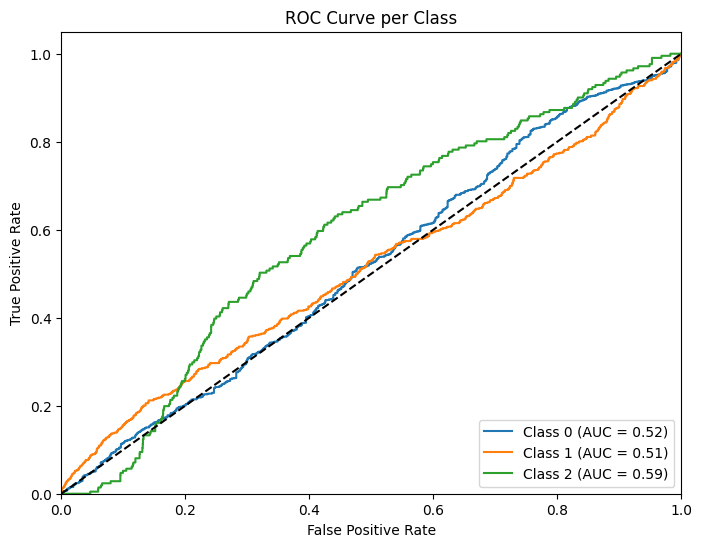

ValueError: Input contains NaN.

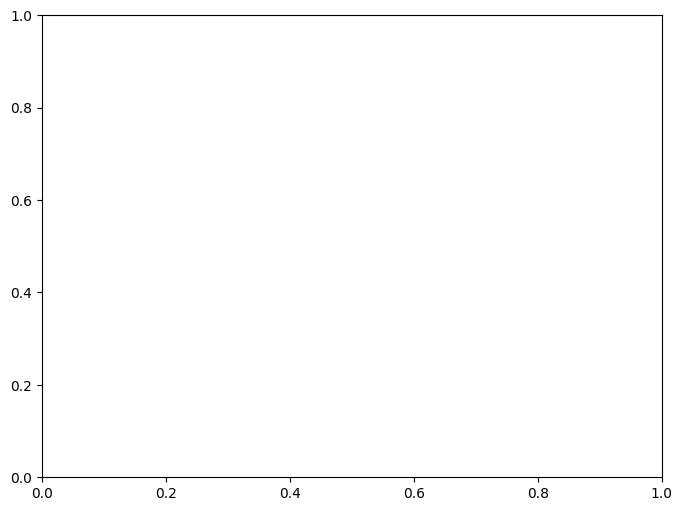

In [81]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x

def run_experiment(model, train_loader, test_loader, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        model.train()
        for epoch in range(num_epochs):
            total_loss = 0
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                loss = loss_op(output, data.y.float())
                total_loss += loss.item()
                loss.backward()
                optimizer.step()
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader)}")

    train()

def calculate_roc(loader):
    model.eval()
    all_preds = []
    all_labels = []
    for data in loader:
        data = data.to(device)
        out = torch.sigmoid(model(data.x, data.edge_index))
        all_preds.append(out.detach().cpu().numpy())
        all_labels.append(data.y.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(num_classes):
        # Handle NaN values in predictions and labels
        valid_idx = ~np.isnan(all_preds[:, i]) & ~np.isnan(all_labels[:, i])
        if np.sum(valid_idx) == 0:  # Skip this class if all are NaN
            print(f"Skipping Class {i} due to NaN values")
            continue
        fpr, tpr, _ = roc_curve(all_labels[valid_idx, i], all_preds[valid_idx, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve per Class')
    ax.legend(loc="lower right")
    plt.show()

def calculate_precision_recall(loader):
    model.eval()
    all_preds = []
    all_labels = []
    for data in loader:
        data = data.to(device)
        out = torch.sigmoid(model(data.x, data.edge_index))
        all_preds.append(out.detach().cpu().numpy())
        all_labels.append(data.y.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(all_labels[:, i], all_preds[:, i])
        ap = average_precision_score(all_labels[:, i], all_preds[:, i])
        ax.plot(recall, precision, label=f'Class {i} (AP = {ap:.2f})')

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curve per Class')
    ax.legend(loc="best")
    plt.show()

# Example usage
num_features = 2  # Adjust based on your dataset
num_classes = 3   # Adjust based on your dataset
model = GCN(num_features, 16, num_classes).to(device)

# Assuming train_loader and test_loader are defined and loaded with your dataset
run_experiment(model, a, b, num_epochs=100)

# After training, visualize the results
calculate_roc(b)
calculate_precision_recall(b)
